<h1 style="color: White; font-weight: 800;">Capstone 1</h1>

<h2 style="color: blue; font-weight: 800;">
  Index : 
</h2>

<div class="nb-index">
  <ol>
    <li>
      <a href="#data-cleaning">Data Cleaning and Data Pre-processing</a>
      <ol>
        <li><a href="#importing-modules">Importing Modules</a></li>
        <li><a href="#data-ingestion">Data Ingestion</a></li>
        <li><a href="#column-name-meaning">Column Name Meaning</a></li>
        <li><a href="#column-name-changing">Column Name Changing</a></li>
        <li><a href="#category-columns">Category Columns</a></li>
        <li><a href="#binary-values-columns">Binary Values Columns</a></li>
        <li><a href="#numerical-columns">Numerical Columns</a></li>
        <li><a href="#duplicate-treatment">Treatment of Duplicate Values</a></li>
        <li><a href="#null-value-treatment">NULL Values Treatment</a></li>
      </ol>
    </li>
      <li>
          <a href="#eda-eda">EDA (Exploratory Data Analysis)</a>
          <ol>
              <li><a href="#moving-status-to-end">Moving Status column to end of DataFrame</a></li>
              <li><a href="#outlier-treatment">Outlier Treatment</a></li>
              <li><a href="#date-time">Treatment of Date_of_Interview Column</a></li>
              <li><a href="#postal-code-treatment">Treatment of Postal_Code Column</a></li>
              <li><a href="#numerical-plots">Distribution Plots of Numerical Columns</a></li>
              <li><a href="#categorical-plots">Plots of Categorical Columns</a></li>
              <li><a href="#all-vs-status-statistical">All Columns vs Status(Target Feature) Statistical Analysis</a></li>
              <li><a href="#correlation-heatmap">Numerical Columns Importance : Correlation Heatmap</a></li>
          </ol>
      </li>
    <li>
      <a href="#feature-engineering">Feature Engineering</a>
      <ol>
        <li><a href="#drop-columns">Drop Unnecessary Columns</a></li>
        <li><a href="#encoding">Encoding of Categorical Columns</a></li>
        <li><a href="#scaling">Scaling of Numerical Columns</a></li>
        <li><a href="#encoding-target">Encoding Target Feature (Status)</a></li>
        <li><a href="#x-y-split">X & y Split</a></li>
        <li><a href="#train-test-split">Train Test Split</a></li>
        <li><a href="#smote-train">SMOTE on Train Dataset</a></li>
        <li><a href="#model-training">Machine Learning Model Training</a></li>
        <li><a href="#models-plots">Machine Learning Models Plots</a></li>
      </ol>
    </li>
  </ol>
</div>

 <a id="data-cleaning"></a>

<h1 style="color: red; font-weight: 800;">Data Cleaning and Data Pre-processing</h1>

 <a id="importing-modules"></a>

<h2 style="color: green; font-weight: 800;">Importing Modules</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("All modules imported!")

All modules imported!


<a id="data-ingestion"></a>

<h2 style="color: green; font-weight: 800;">Data Ingestion</h2>

In [2]:
df = pd.read_csv("HR_HIRING_ANALYTICS.csv")

data = pd.DataFrame(df)
# Remove accidental spaces from column names
data.columns = data.columns.str.strip()

# Convert updated column names to the names used in your existing code
column_mapping = {
    "CANDIDATE_REF": "Candidate_Ref",
    "DOJ_EXTENDED": "DOJ_Extended",
    "DURATION_TO_ACCEPT_OFFER": "Duration_to_accept_offer",
    "NOTICE_PERIOD": "Notice_Period",
    "OFFERED_BAND": "Offered_Band",
    "PERCENT_HIKE_EXPECTED_IN_CTC": "Percent_hike_expected_in_CTC",
    "PERCENT_HIKE_OFFERED_IN_CTC": "Percent_hike_offered_in_CTC",
    "PERCENT_DIFFERENCE_CTC": "Percent_difference_CTC",
    "JOINING_BONUS": "Joining_Bonus",
    "CANDIDATE_RELOCATE_ACTUAL": "Candidate_relocate_actual",
    "GENDER": "Gender",
    "CANDIDATE_SOURCE": "Candidate_Source",
    "REX_IN_YRS": "Rex_in_Yrs",
    "LOCATION_ID": "Location_ID",
    "POSTAL_CODE": "Postal_Code",
    "AGE": "Age",
    "LOB_ID": "LOB_Id",
    "DOMICILE_ID": "Domicile_Id",
    "JOINING_STATUS": "Status",
    "DATE_OF_INTERVIEW": "Date_of_Interview",
    "LOB_NAME": "LOB",
    "DOMICILE_NAME": "Domicile_Name",
    "LOCATION_NAME": "Location_Name",
    "REGION_ID": "Region_Id",
    "REGION_NAME": "Region_Name"
}

data.rename(columns=column_mapping, inplace=True)

# Add Sno if it is not present in the updated file
if "Sno" not in data.columns:
    data.insert(0, "Sno", range(1, len(data) + 1))

# Verify the final column names
print(data.columns.tolist())

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [3]:
# df = pd.read_csv("HR_Hiring_details_transaction.csv")
# df
# data = pd.DataFrame(df)


In [4]:
data

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


In [5]:
cols = list(data.columns)
print(cols)

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [6]:
row,column = data.shape
print(f"No of Rows : {row}\nNo of Columns = {column}")

No of Rows : 8995
No of Columns = 26


In [7]:
data.head()

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [8]:
data.sample(10)

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
7406,7407,3355246,No,1,30,E1,38.89,38.89,0.00,No,...,34.0,4,D2,Joined,2013-04-10,BFSI,Bihar,Bangalore,R2,South
6875,6876,3300487,Yes,27,60,E3,32.00,27.37,-4.63,No,...,32.0,2,D2,Joined,2014-02-13,INFRA,Bihar,Noida,R1,North
529,530,2152130,Yes,6,0,E2,48.39,48.39,0.00,No,...,29.0,2,D8,Joined,2014-04-20,INFRA,Haryana,Noida,R1,North
2457,2458,2378191,Yes,31,30,E1,66.67,45.83,-20.84,No,...,25.0,1,D12,Joined,2013-10-12,ERS,Kerala,Chennai,R2,South
2464,2465,2378301,Yes,3,90,E2,29.09,29.09,0.00,No,...,27.0,2,D14,Joined,2013-10-16,INFRA,Maharashtra,Noida,R1,North
5940,5941,3230273,No,9,30,E1,19.05,19.05,0.00,No,...,25.0,4,D14,Joined,2013-12-03,BFSI,Maharashtra,Bangalore,R2,South
2719,2720,2416582,Yes,46,30,E1,32.26,15.32,-16.94,No,...,30.0,4,D20,Joined,2013-09-27,BFSI,Telangana,Bangalore,R2,South
4052,4053,2586683,No,2,30,E1,26.32,10.53,-15.79,No,...,26.0,4,D12,Joined,2014-04-20,BFSI,Kerala,Chennai,R2,South
7093,7094,3322024,No,8,30,E2,7.84,0.49,-7.35,No,...,34.0,1,D8,Joined,2014-01-20,ERS,Haryana,Chennai,R2,South
3634,3635,2535888,No,1,30,E2,42.86,42.86,0.00,No,...,37.0,2,D8,Joined,2013-02-03,INFRA,Haryana,Chennai,R2,South


<a id="column-name-meaning"></a>

<h2 style="color: green; font-weight: 800;">Column Name Meaning</h2>

1. *`CANDIDATE_REF`* : Unique reference number assigned to the candidate


2. *`DOJ_EXTENDED`* : Indicates whether the candidate’s date of joining was extended


3. *`DURATION_TO_ACCEPT_OFFER`* : Number of days taken by the candidate to accept the offer


4. *`NOTICE_PERIOD`* : Notice period, generally measured in days, required by the candidate’s previous employer


5. *`OFFERED_BAND`* : Job grade or employment level offered to the candidate


6. *`PERCENT_HIKE_EXPECTED_IN_CTC`* : Percentage increase in CTC expected by the candidate


7. *`PERCENT_HIKE_OFFERED_IN_CTC`* : Percentage increase in CTC offered by the organization


8. *`PERCENT_DIFFERENCE_CTC`* : Percentage gap between the expected CTC hike and the offered CTC hike


9. *`JOINING_BONUS`* : Indicates whether a joining bonus was offered


10. *`CANDIDATE_RELOCATE_ACTUAL`* : Indicates whether relocation was required or accepted by the candidate


11. *`GENDER`* : Gender of the candidate


12. *`CANDIDATE_SOURCE`* : Recruitment source through which the candidate was identified or approached


13. *`REX_IN_YRS`* : Relevant or related work experience in years


14. *`LOCATION_ID`* : Unique code representing the job or organization location


15. *`POSTAL_CODE`* : Postal code associated with the job or organization location


16. *`AGE`* : Age of the candidate


17. *`LOB_ID`* : Unique code representing the candidate’s Line of Business or department


18. *`DOMICILE_ID`* : Unique code representing the candidate’s home state or residential location


19. *`JOINING_STATUS`* : Outcome of the offer, such as joined, not joined, or declined


20. *`DATE_OF_INTERVIEW`* : Date on which the candidate interview was conducted


22. *`LOB_NAME`* : Name of the candidate’s Line of Business or department


23. *`DOMICILE_NAME`* : Name of the candidate’s home state or residential location


24. *`LOCATION_NAME`* : Name of the job or organization location


4. *`REGION_ID`* : Unique code representing the region


25. *`REGION_NAME`* : Name of the region associated with the location

<a id="column-name-changing"></a>

<h2 style="color: green; font-weight: 800;">Column Name Changing</h2>

`Changing columns' name to more relatable name`

1. *Candidate_Ref* = **Candidate_ID**
2. *Duration_to_accept_offer* = **Acceptance_days**
3. *Percent_hike_expected_in_CTC* = **Expected_CTC_hike_pct**
4. *Percent_hike_offered_in_CTC* = **Offered_CTC_hike_pct**
5. *Percent_difference_CTC* = **CTC_diff_pct**
6. *Rex_in_Yrs* = **Experience_years**


In [9]:
data.rename(columns = {"Candidate_Ref" : "Candidate_ID", "Duration_to_accept_offer" : "Acceptance_days"
                      ,"Percent_hike_expected_in_CTC" : "Expected_CTC_hike_pct", "Percent_hike_offered_in_CTC" : "Offered_CTC_hike_pct",
                      "Percent_difference_CTC" : "CTC_diff_pct", "Rex_in_Yrs" : "Experience_years"}, inplace=True)

data.head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North


In [10]:
cols = list(data.columns)
print(f"Columns = {cols}")

Columns = ['Sno', 'Candidate_ID', 'DOJ_Extended', 'Acceptance_days', 'Notice_Period', 'Offered_Band', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Experience_years', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


<a id="category-columns"></a>

<h2 style="color: green; font-weight: 800;">Category Columns</h2>

`nan value only in Offered_Band`

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
category_cols = list(data.select_dtypes(exclude='number').columns)
print(f"Category columns = {category_cols}")

Category columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'Status', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name']


In [13]:
for col in category_cols:
    print(f"Value counts of {col} : {data[col].value_counts()}\n")
# There is Null values in ->
# 1.Offered_Band
# 2.Location_ID

Value counts of DOJ_Extended : DOJ_Extended
No     4788
Yes    4207
Name: count, dtype: int64

Value counts of Offered_Band : Offered_Band
E1              5565
E2              2704
E3               502
E0               211
Not Assigned      13
Name: count, dtype: int64

Value counts of Joining_Bonus : Joining_Bonus
No     8578
Yes     417
Name: count, dtype: int64

Value counts of Candidate_relocate_actual : Candidate_relocate_actual
No     7705
Yes    1290
Name: count, dtype: int64

Value counts of Gender : Gender
Male      7444
Female    1551
Name: count, dtype: int64

Value counts of Candidate_Source : Candidate_Source
Direct               4801
Agency               2585
Employee Referral    1609
Name: count, dtype: int64

Value counts of Location_ID : Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

Value counts of Domicile_Id : Domicile_Id
D8     402


<a id="binary-values-columns"></a>

<h2 style="color: green; font-weight: 800;">Binary Values Columns</h2>

`There is no inconsistency as there is only 'Yes' or 'No' or 'Male' or 'Female'`

- Binary Columns are -
1. DOJ_Extended
2. Joining_Bonus
3. Gender
4. Candidate_relocate_actual
5. Status

In [14]:
data['DOJ_Extended'].value_counts()

DOJ_Extended
No     4788
Yes    4207
Name: count, dtype: int64

In [15]:
data['Joining_Bonus'].value_counts()

Joining_Bonus
No     8578
Yes     417
Name: count, dtype: int64

In [16]:
data['Gender'].value_counts()

Gender
Male      7444
Female    1551
Name: count, dtype: int64

In [17]:
data['Status'].value_counts()

Status
Joined        7313
Not Joined    1682
Name: count, dtype: int64

In [18]:
data['Candidate_relocate_actual'].value_counts()

Candidate_relocate_actual
No     7705
Yes    1290
Name: count, dtype: int64

### There is no inconsistency or ambiguity in Binary Columns

<a id="numerical-columns"></a>

<h2 style="color: green; font-weight: 800;">Numerical Columns</h2>


In [19]:
numerical_cols = list(data.select_dtypes(include = 'number').columns)
print(f"Numerical columns = {numerical_cols}")

Numerical columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [20]:
data[numerical_cols].describe()

,Sno,Candidate_ID,Acceptance_days,Notice_Period,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Experience_years,Postal_Code,Age,LOB_Id
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8980.000000,8995.000000
mean,4498.000000,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-3.207447,4.239022,453494.479266,29.912027,3.113063
std,2596.777169,4.863448e+05,25.811616,22.220239,29.788975,36.064060,27.412448,2.547571,180254.661181,4.095699,2.125902
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-200.000000,0.000000,122107.000000,20.000000,1.000000
25%,2249.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-12.755000,3.000000,201301.000000,27.000000,1.000000
50%,4498.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,560034.000000,29.000000,2.000000
75%,6746.500000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,600020.000000,34.000000,4.000000
max,8995.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,385.720000,24.000000,700027.000000,60.000000,9.000000


In [21]:
data[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8980 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


### Checking for NULL values

In [22]:
data[numerical_cols].isna().sum()

# There is NULL values in ->
# 1. Age 

Sno                       0
Candidate_ID              0
Acceptance_days           0
Notice_Period             0
Expected_CTC_hike_pct     0
Offered_CTC_hike_pct      0
CTC_diff_pct              0
Experience_years          0
Postal_Code               0
Age                      15
LOB_Id                    0
dtype: int64

In [23]:
data['Age'].isna().sum()

np.int64(15)

In [24]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

<a id="duplicate-treatment"></a>

<h2 style="color: green; font-weight: 800;">Treatment of Duplicate Values</h2>


In [25]:
data[numerical_cols].duplicated().sum()
# There is no duplicate value in numerical columns

np.int64(0)

`Columns to check further - Either will change data type or remove in EDA`

- Postal_Code
- LOB_Id

In [26]:
data['Postal_Code'].unique()

array([201301, 600020, 122107, 560034, 500004, 700027, 682001, 411002,
       600018, 400001, 560002, 382460, 560063, 500045, 411006])

In [27]:
data['LOB_Id'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
data['Notice_Period'].unique()
# Have to deep it as numeric (Imp)

array([ 30,  45, 120,   0,  75,  60,  90])

In [29]:
data['Acceptance_days'].unique()
# There is no negative(-) value, so this column is not imbalance.

array([ 14,  18,   3,  26,   1,  17,  37,  16,   6, 120,  44,   7,  98,
         0,  83,  32,  19,   4,  38,  24,  10,  53,   5,  46,   2,  31,
        54,  33, 105,  69,  68,  84,  28, 126, 106,  90,  21,  36,  34,
        20,  13,   8,  42,  12, 103,  43,  60,  23,  67,  15,  45,  25,
        47,  11,  48,  74,  30,  40,  35,  58,  29,  86,  51,  50,  39,
        57,  93,  55,  71,  56,  66,  62,   9,  64, 107,  27,  78,  22,
        49,  92,  61,  79,  77, 108,  70,  82, 210,  80,  97,  41,  59,
        88,  99,  63, 111,  87,  95,  52,  96,  91, 101,  65, 140,  76,
        73, 123, 104,  72, 117, 109,  89, 127,  81,  85,  75, 118, 114,
       110, 129, 124, 116, 181,  94, 121, 119, 102, 113, 115, 125, 131,
       100, 130, 224, 143, 122, 163])

In [30]:
print(data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0])
# There are many rows that have offered ctc hike percentage in negative value.
# So this negative values are important, because candidates with negative value of percentage ctc hike might not join the firm
print(f"\nNo of rows with negative(-) offered ctc hike percentage = {data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0].count()}")

7      -20.00
8      -22.22
10     -60.53
15     -27.31
29      -2.17
        ...  
8872   -17.04
8882    -6.67
8958    -2.86
8967   -10.00
8977   -14.29
Name: Offered_CTC_hike_pct, Length: 446, dtype: float64

No of rows with negative(-) offered ctc hike percentage = 446


<a id="null-value-treatment"></a>

<h2 style="color: green; font-weight: 800;">NULL Values Treatment</h2>

`Columns with NULL values :`

1. Age
2. Offered_Band
3. Location_ID
4. Location_Name                
5. Region_Id                    
6. Region_Name 

In [31]:
data.isna().sum()

# One thing here -> 
# The Data type of Location_ID is object, but its showing 0 null value here. That means there is NULL value as Object.

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                          15
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        8995 non-null   int64  
 1   Candidate_ID               8995 non-null   int64  
 2   DOJ_Extended               8995 non-null   object 
 3   Acceptance_days            8995 non-null   int64  
 4   Notice_Period              8995 non-null   int64  
 5   Offered_Band               8995 non-null   object 
 6   Expected_CTC_hike_pct      8995 non-null   float64
 7   Offered_CTC_hike_pct       8995 non-null   float64
 8   CTC_diff_pct               8995 non-null   float64
 9   Joining_Bonus              8995 non-null   object 
 10  Candidate_relocate_actual  8995 non-null   object 
 11  Gender                     8995 non-null   object 
 12  Candidate_Source           8995 non-null   object 
 13  Experience_years           8995 non-null   int64

## Treatment of `Age` column

In [33]:
data['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
8980 non-null   float64
dtypes: float64(1)
memory usage: 70.4 KB


In [34]:
data['Age']

0       34.0
1       34.0
2       27.0
3       34.0
4       34.0
        ... 
8990    34.0
8991    34.0
8992    34.0
8993    34.0
8994    34.0
Name: Age, Length: 8995, dtype: float64

In [35]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

In [36]:
Age_missing = int(data['Age'].isna().sum())
Age_min = data['Age'].min()
Age_max = data['Age'].max()

Age_median = data['Age'].median()
Age_mean = data['Age'].mean()

print(f"Null values in Age column = {Age_missing}")
print(f"Min Age = {Age_min}")
print(f"Max Age = {Age_max}")
print(f"Median Age = {Age_median}")
print(f"Mean Age = {Age_mean}")

Null values in Age column = 15
Min Age = 20.0
Max Age = 60.0
Median Age = 29.0
Mean Age = 29.912026726057906


In [37]:
data['Age'][data["Age"] > Age_mean].count()

np.int64(4481)

In [38]:
data['Age'][data["Age"] <= Age_mean].count()

np.int64(4499)

In [39]:
data['Age'][data["Age"] > 35].count()

np.int64(435)

In [40]:
data['Age'][data["Age"] > 40].count()

np.int64(77)

In [41]:
data['Age'][data["Age"] > 50].count()

np.int64(2)

### Diagram of Age column distribution

In [42]:
age_count = pd.DataFrame(data['Age'].dropna().value_counts())
age_count

,count
Age,
34.0,2142
27.0,903
26.0,839
28.0,770
25.0,676
29.0,630
30.0,575
31.0,485
24.0,397


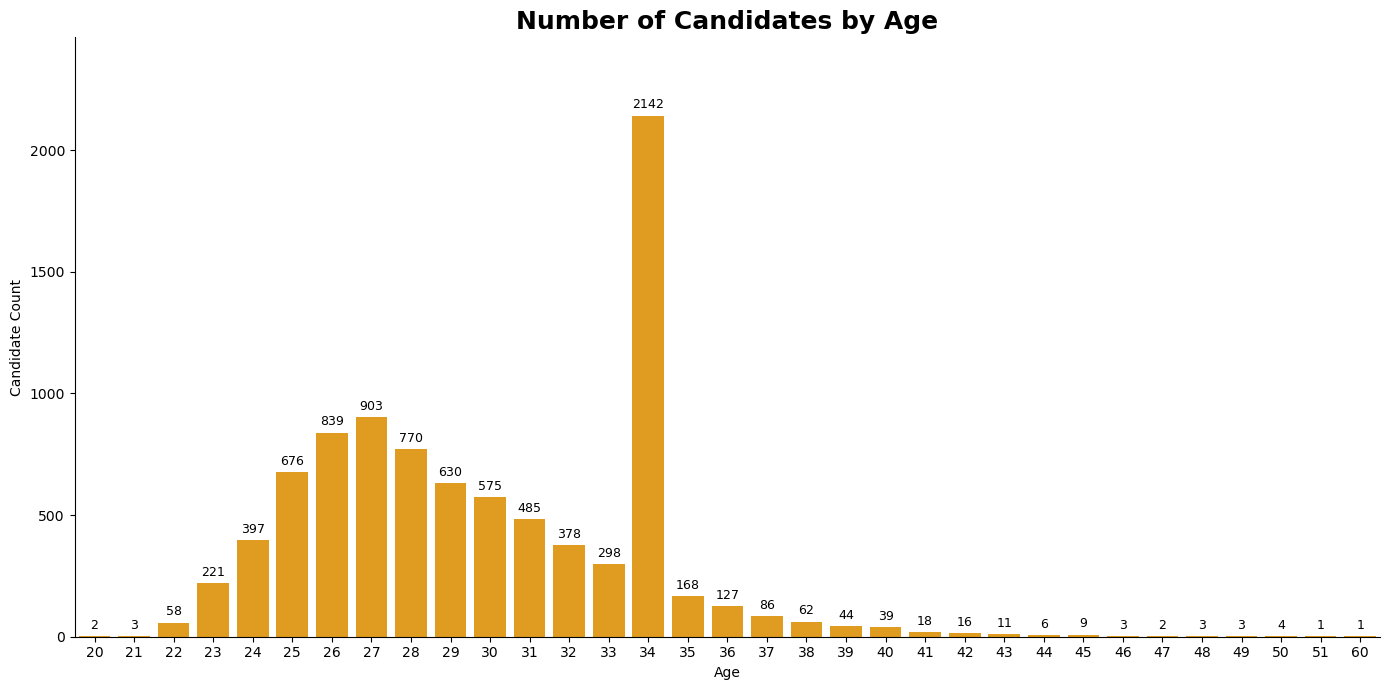

In [43]:
age_count2 = (
    data["Age"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

x = age_count2.index.tolist()
y = age_count2.tolist()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=x,
    y=y,
    color="orange"
)

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.title("Number of Candidates by Age", fontsize=18, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Candidate Count")
plt.ylim(0, max(y) * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

### Outliers check for `Age` column

In [44]:
age = pd.to_numeric(data["Age"].dropna())

# Calculate IQR
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = age[(age < lower_bound) | (age > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values : {outliers.unique()}")

Q1: 27.0
Q3: 34.0
IQR: 7.0
Lower bound: 16.5
Upper bound: 44.5
Number of outliers: 26
Outlier values : [50. 45. 46. 49. 47. 48. 60. 51.]


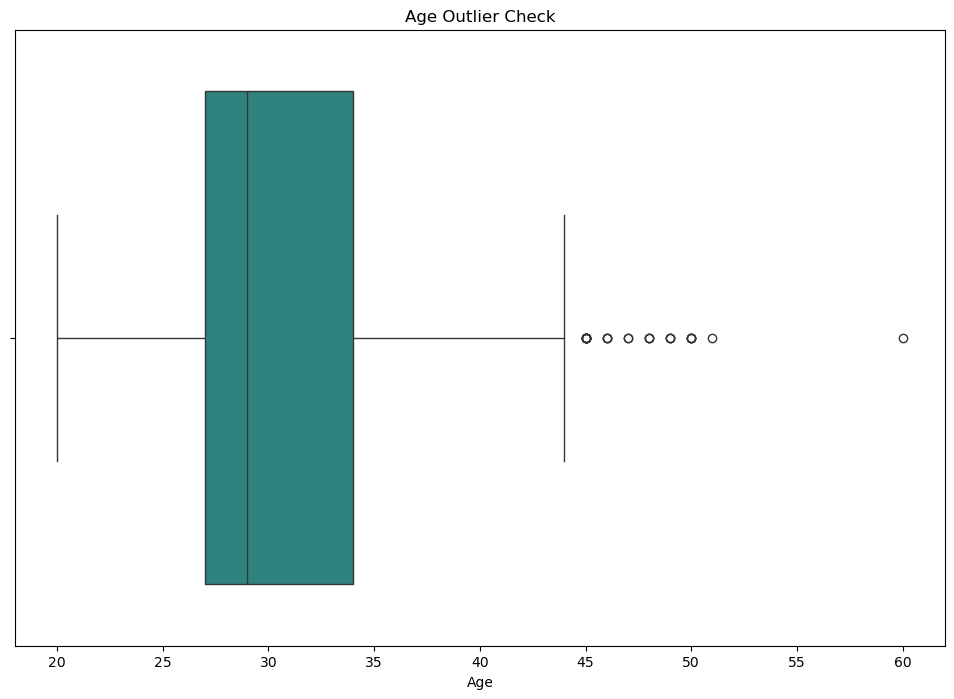

In [45]:
plt.figure(figsize=(12,8))

sns.boxplot(x=data["Age"].dropna(), palette='viridis')

plt.title("Age Outlier Check")
plt.xlabel("Age")
plt.show()

The decreasing number of candidates at higher ages indicates that the distribution is concentrated around younger ages and has a right tail. The mean age is approximately 29.91, while the median is 29. The IQR method flags ages above 44.5 as statistical outliers.
Because the higher ages can pull the mean upward, the median is the safer replacement value for the 15 missing ages. It represents the typical candidate more robustly and results in an actual whole-number age.

In [46]:
data[data['Age'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
397,398,2117861,Yes,62,60,E2,40.85,40.85,0.00,No,...,NaN,2,D15,Joined,2013-10-26,INFRA,Manipur,Noida,R1,North
406,407,2118480,No,4,30,E1,89.66,48.28,-41.38,No,...,NaN,5,D12,Joined,2014-03-30,CSMP,Kerala,Noida,R1,North
414,415,2119541,Yes,2,0,E2,56.86,37.25,-19.61,No,...,NaN,2,D15,Joined,2014-04-08,INFRA,Manipur,Noida,R1,North
425,426,2121112,No,3,30,Not Assigned,0.00,-6.45,-6.45,No,...,NaN,2,D4,Joined,2014-04-25,INFRA,Chhattisgarh,Bangalore,R2,South
446,447,2128251,No,58,30,E2,50.33,50.33,0.00,No,...,NaN,2,D24,Joined,2014-05-20,INFRA,West Bengal,Chennai,R2,South
485,486,2143765,Yes,41,90,E1,10.77,10.77,0.00,No,...,NaN,4,D7,Joined,2014-07-06,BFSI,Gujarat,Chennai,R2,South
526,527,2151137,No,4,45,E3,20.83,20.83,0.00,No,...,NaN,2,D23,Joined,2014-04-13,INFRA,Uttarkhand,Noida,R1,North
573,574,2160044,No,0,0,E2,17.78,14.31,-3.47,Yes,...,NaN,2,D13,Joined,2014-06-19,INFRA,Madhya Pradesh,Gurgaon,R1,North
616,617,2167868,No,5,30,E1,20.00,-4.00,-24.00,No,...,NaN,2,D13,Joined,2013-01-02,INFRA,Madhya Pradesh,Noida,R1,North
674,675,2177940,No,0,30,E1,13.46,34.56,21.10,No,...,NaN,5,D22,Joined,2013-01-22,CSMP,Uttar Pradesh,Gurgaon,R1,North


### Filling NULL values in `Age` column with `Median`

In [47]:
data['Age'].fillna(Age_median, inplace=True)

In [48]:
data['Age'].isna().sum()

np.int64(0)

In [49]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

## Treatment of `Offered_Band` column

In [50]:
data['Offered_Band'].replace("Not Assigned" , np.nan, inplace = True)

In [51]:
data['Offered_Band']

0       E2
1       E2
2       E2
3       E2
4       E2
        ..
8990    E1
8991    E1
8992    E2
8993    E1
8994    E1
Name: Offered_Band, Length: 8995, dtype: object

In [52]:
data['Offered_Band'].unique()

array(['E2', 'E1', 'E3', nan, 'E0'], dtype=object)

In [53]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5565
E2    2704
E3     502
E0     211
Name: count, dtype: int64

In [54]:
data['Offered_Band'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Offered_Band
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [55]:
#print(f"No of NULL values in Offered_Band column = {data['Offered_Band'].isna().sum()}")
data['Offered_Band'].isna().sum()

np.int64(13)

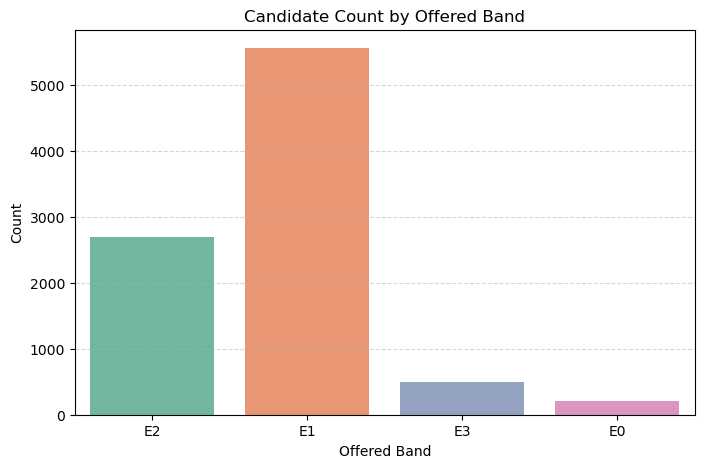

In [56]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Offered_Band",
    hue="Offered_Band",
    palette="Set2",
    legend=False
)

plt.xlabel("Offered Band")
plt.ylabel("Count")
plt.title("Candidate Count by Offered Band")
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.show()

In [57]:
data[data['Offered_Band'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
27,28,2207823,Yes,19,30,NaN,42.85,42.85,0.00,No,...,28.0,2,D13,Joined,2013-07-17,INFRA,Madhya Pradesh,Noida,R1,North
55,56,2286381,Yes,14,30,NaN,-12.50,-12.50,0.00,No,...,31.0,7,D4,Joined,2013-12-31,AXON,Chhattisgarh,Kolkata,R3,East
79,80,2365129,No,4,30,NaN,42.86,42.86,0.00,No,...,24.0,2,D12,Not Joined,2013-01-02,INFRA,Kerala,Cochin,R2,South
109,110,2452418,Yes,32,30,NaN,45.30,19.66,-25.64,No,...,30.0,6,D15,Joined,2013-02-20,ETS,Manipur,Bangalore,R2,South
138,139,2569520,No,5,30,NaN,-48.25,-48.25,0.00,No,...,31.0,2,D20,Joined,2013-03-30,INFRA,Telangana,Chennai,R2,South
167,168,2780669,Yes,29,60,NaN,33.33,266.67,233.34,No,...,32.0,1,D23,Not Joined,2013-05-11,ERS,Uttarkhand,Noida,R1,North
194,195,2845929,Yes,55,30,NaN,37.50,25.00,-12.50,No,...,25.0,2,D15,Joined,2013-06-15,INFRA,Manipur,Bangalore,R2,South
227,228,3211382,No,4,30,NaN,42.85,42.85,0.00,No,...,30.0,2,D22,Joined,2013-08-20,INFRA,Uttar Pradesh,Bangalore,R2,South
281,282,3300563,Yes,29,30,NaN,-30.00,-30.60,-0.60,No,...,33.0,5,D19,Joined,2013-11-05,CSMP,Tamil Nadu,Noida,R1,North
319,320,3379843,No,17,0,NaN,-12.04,-12.04,0.00,No,...,28.0,2,D3,Not Joined,2014-01-03,INFRA,Chandigarh,Chennai,R2,South


In [58]:
data[data['Offered_Band'] == 'E1'].head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
5,6,2117167,Yes,17,30,E1,42.83,42.83,0.00,No,...,34.0,2,D24,Joined,2013-02-03,INFRA,West Bengal,Noida,R1,North
7,8,2127572,Yes,16,0,E1,-20.00,-20.00,0.00,No,...,34.0,3,D6,Joined,2013-02-16,Healthcare,Goa,Noida,R1,North
8,9,2138169,No,1,30,E1,-22.22,-22.22,0.00,No,...,26.0,4,D5,Joined,2013-02-16,BFSI,Delhi,Gurgaon,R1,North
9,10,2143362,No,6,30,E1,240.00,220.00,-20.00,No,...,34.0,5,D23,Joined,2013-03-07,CSMP,Uttarkhand,Chennai,R2,South
18,19,2173730,No,1,30,E1,-13.42,42.86,56.28,No,...,34.0,2,D7,Joined,2013-05-14,INFRA,Gujarat,Gurgaon,R1,North


As there is only only 13 missing values in column `Offered_Band`, we can replace this with the `Mode` of the column i.e. E1

In [59]:
OB_mode = data['Offered_Band'].mode()[0]
OB_mode

'E1'

### Filling `Offered_Band` with `Mode` i.e. `E1`

In [60]:
data['Offered_Band'].fillna(OB_mode, inplace = True)

In [61]:
data['Offered_Band'].isna().sum()

np.int64(0)

In [62]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5578
E2    2704
E3     502
E0     211
Name: count, dtype: int64

## Treatment of `Location_ID` column

In [63]:
data['Location_ID']

0       L001
1       L002
2       L001
3       L001
4       L001
        ... 
8990    L002
8991    L002
8992    L001
8993    L001
8994    L002
Name: Location_ID, Length: 8995, dtype: object

In [64]:
data['Location_ID'].isna().sum()
# This showing no NULL values.

np.int64(0)

In [65]:
data['Location_ID'].value_counts()

# But here we can see there are 13 NULL valued Rows as Null is in Object type

Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

In [66]:
data[data['Location_ID'] == 'Null']

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
220,221,3110300,Yes,15,30,E1,42.83,42.83,0.00,No,...,26.0,2,D16,Joined,2013-08-06,INFRA,Odisha,NaN,NaN,NaN
289,290,3318393,Yes,0,30,E1,92.54,80.51,-12.03,No,...,23.0,2,D14,Joined,2013-11-16,INFRA,Maharashtra,NaN,NaN,NaN
449,450,2128714,Yes,41,45,E1,20.00,4.00,-16.00,No,...,33.0,7,D2,Joined,2014-05-24,AXON,Bihar,NaN,NaN,NaN
1157,1158,2222607,Yes,11,30,E1,42.86,42.86,0.00,No,...,28.0,2,D18,Joined,2013-05-14,INFRA,Rajasthan,NaN,NaN,NaN
2027,2028,2356982,Yes,1,90,E2,50.00,50.00,0.00,No,...,31.0,2,D24,Joined,2013-08-30,INFRA,West Bengal,NaN,NaN,NaN
2562,2563,2394715,Yes,9,30,E1,34.62,34.62,0.00,No,...,30.0,2,D10,Joined,2013-11-16,INFRA,Jharkhand,NaN,NaN,NaN
2774,2775,2419719,Yes,10,30,E1,86.89,86.89,0.00,No,...,35.0,2,D20,Joined,2013-10-18,INFRA,Telangana,NaN,NaN,NaN
2790,2791,2419919,Yes,20,30,E1,6.48,6.48,0.00,No,...,31.0,2,D8,Joined,2013-10-25,INFRA,Haryana,NaN,NaN,NaN
6941,6942,3304772,Yes,0,30,E1,48.15,57.41,9.26,No,...,27.0,2,D8,Joined,2013-12-22,INFRA,Haryana,NaN,NaN,NaN
7312,7313,3347807,No,4,30,E1,33.33,33.33,0.00,No,...,34.0,2,D18,Joined,2013-12-27,INFRA,Rajasthan,NaN,NaN,NaN


### Plot of `Location_ID`

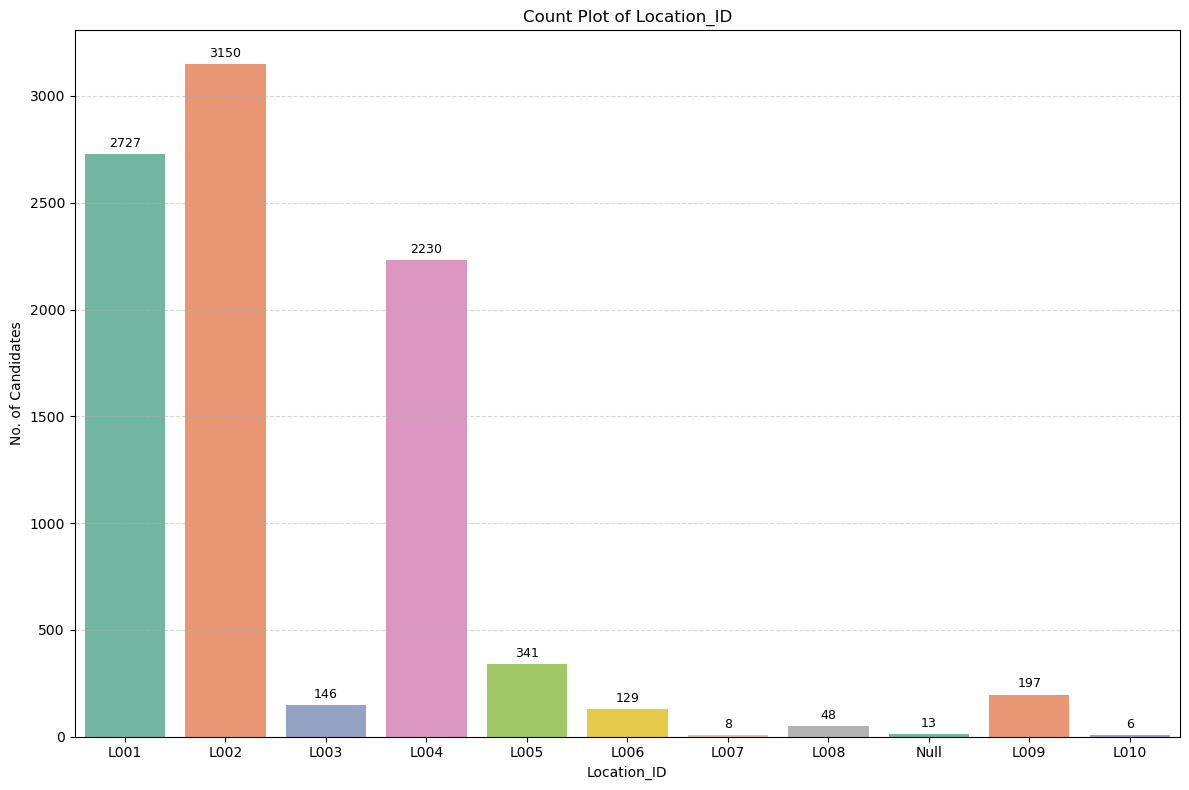

In [67]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_ID",
    hue="Location_ID",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As there is 13 NULL values and there are some Location_ID(s) which have value_counts less than the
NULL, so in this case `replcaing NULL with "Unknown"` will be a good choice.

In [68]:
data["Location_ID"] = data["Location_ID"].replace("Null", "Unknown")

In [69]:
data['Location_ID'].value_counts()

Location_ID
L002       3150
L001       2727
L004       2230
L005        341
L009        197
L003        146
L006        129
L008         48
Unknown      13
L007          8
L010          6
Name: count, dtype: int64

In [70]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                  0
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
Status                        0
Date_of_Interview             0
LOB                           0
Domicile_Name                 0
Location_Name                13
Region_Id                    13
Region_Name                  13
dtype: int64

### Treatment of `Location_Name`

In [71]:
LN_NULL = data['Location_Name'].isna().sum()

print(f"No of Null values in Location_Name = {LN_NULL}")

No of Null values in Location_Name = 13


In [72]:
data['Location_Name'].value_counts()

Location_Name
Chennai      3150
Noida        2727
Bangalore    2230
Hyderabad     341
Mumbai        197
Gurgaon       146
Kolkata       129
Pune           48
Cochin          8
Ahmedabad       6
Name: count, dtype: int64

In [73]:
data['Location_Name'].unique()

array(['Noida', 'Chennai', 'Gurgaon', 'Bangalore', 'Hyderabad', 'Kolkata',
       'Cochin', 'Pune', nan, 'Mumbai', 'Ahmedabad'], dtype=object)

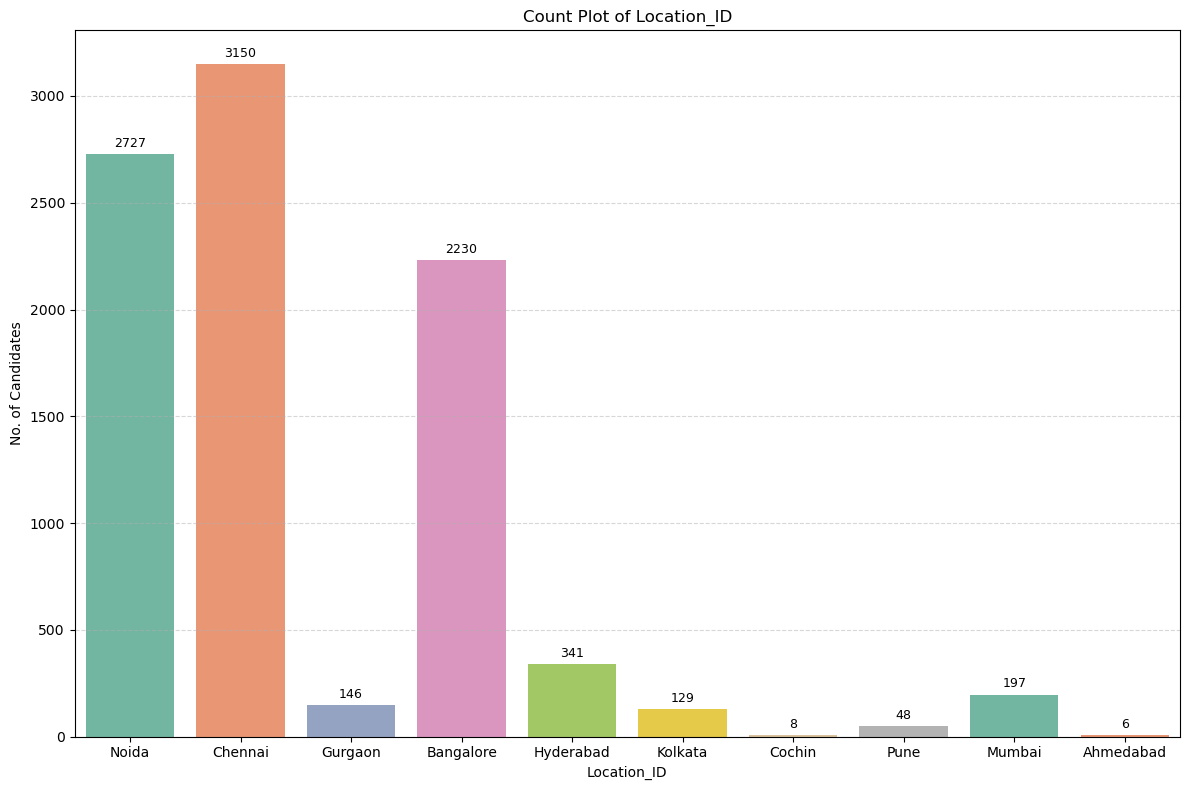

In [74]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_Name",
    hue="Location_Name",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As we have replced `NULL` with `Unknown` in Location_ID column.

In Location_Name going to do Same. 
Replacing `NULL` with `Unknown`

One thing to notice, in *Location_ID* column NULL values were as in Object dtype.

But in *Location_Name* column its in NULL format not in Object dtype.

So `.replace("Null" , "Unknown")` will not work, have to do `fillna()`

In [75]:
data['Location_Name'].fillna("Unknown", inplace = True)

In [76]:
data['Location_Name'].isna().sum()

np.int64(0)

#### Treatment of `Region_Id` column

In [77]:
data['Region_Id']

0       R1
1       R2
2       R1
3       R1
4       R1
        ..
8990    R2
8991    R2
8992    R1
8993    R1
8994    R2
Name: Region_Id, Length: 8995, dtype: object

In [78]:
data['Region_Id'].isna().sum()

np.int64(13)

In [79]:
data['Region_Id'].value_counts()

Region_Id
R2    5729
R1    2873
R4     251
R3     129
Name: count, dtype: int64

- Here we can see in `Region_Id` column the Null is in normal NULL format.

- But if we will do `.fillna("Unknown")` there will be only 13 values in `Unknown` bin.

- In this case as fillna("Unknown") can cause Data Imbalance that can directly affect the Model Performance.
So, Filling NULL with `Mode value(R2)` will be a safer option in this case.

In [80]:
RID_Mode = data['Region_Id'].mode()[0]

print(f"Mode of Region_Id column = {RID_Mode}")

Mode of Region_Id column = R2


In [81]:
data['Region_Id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Region_Id
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


In [82]:
# Filling NULL values in Region_Id with 'R2'
data['Region_Id'].fillna('R2', inplace = True)

In [83]:
data['Region_Id'].isna().sum()

np.int64(0)

## Treatment of `Region_Name` column

In [84]:
data['Region_Name']

0       North
1       South
2       North
3       North
4       North
        ...  
8990    South
8991    South
8992    North
8993    North
8994    South
Name: Region_Name, Length: 8995, dtype: object

In [85]:
RName_Null = data['Region_Name'].isna().sum()

print(f"Count of Null values in Region_Name column = {RName_Null}")

Count of Null values in Region_Name column = 13


In [86]:
data[['Region_Id','Region_Name']].value_counts()

Region_Id  Region_Name
R2         South          5729
R1         North          2873
R4         West            251
R3         East            129
Name: count, dtype: int64

- As we can see R2 is the South
- And in `Region_Id` column we have replaced NULL with `Mode("E2")`
- So here in `Region_Name` we have to fill NULL with `Mode("South")`

In [87]:
RN_Mode = data['Region_Name'].mode()[0]

print(f"Mode of Region_Name = {RN_Mode}")

Mode of Region_Name = South


In [88]:
# Replacing NULL with "South"

data['Region_Name'].fillna("South" , inplace = True)

In [89]:
data['Region_Name'].isna().sum()

np.int64(0)

In [90]:
data.isna().sum()

Sno                          0
Candidate_ID                 0
DOJ_Extended                 0
Acceptance_days              0
Notice_Period                0
Offered_Band                 0
Expected_CTC_hike_pct        0
Offered_CTC_hike_pct         0
CTC_diff_pct                 0
Joining_Bonus                0
Candidate_relocate_actual    0
Gender                       0
Candidate_Source             0
Experience_years             0
Location_ID                  0
Postal_Code                  0
Age                          0
LOB_Id                       0
Domicile_Id                  0
Status                       0
Date_of_Interview            0
LOB                          0
Domicile_Name                0
Location_Name                0
Region_Id                    0
Region_Name                  0
dtype: int64

### Null Value Treatment Done.

`There is no more NULL values in any column`

In [91]:
# data.to_csv("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv", index=False)

# print("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv - saved successfully!")

 <a id="eda-eda"></a>

<h1 style="color: red; font-weight: 800;">EDA (Exploratory Data Analysis)</h1>

In [92]:
join = pd.read_csv("Joining_Status.csv")

join_df = pd.DataFrame(join)

join_df

,Candidate_Ref,Status
0,2110407,Joined
1,2112635,Joined
2,2112838,Joined
3,2115021,Joined
4,2115125,Joined
...,...,...
8990,3822427,Joined
8991,3828206,Joined
8992,3834159,Joined
8993,3835433,Joined


In [93]:
join_df['Status'].value_counts()

Status
Joined        7313
Not Joined    1682
Name: count, dtype: int64

In [94]:
join_df.isna().sum()

Candidate_Ref    0
Status           0
dtype: int64

In [95]:
list(data.columns)

['Sno',
 'Candidate_ID',
 'DOJ_Extended',
 'Acceptance_days',
 'Notice_Period',
 'Offered_Band',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Joining_Bonus',
 'Candidate_relocate_actual',
 'Gender',
 'Candidate_Source',
 'Experience_years',
 'Location_ID',
 'Postal_Code',
 'Age',
 'LOB_Id',
 'Domicile_Id',
 'Status',
 'Date_of_Interview',
 'LOB',
 'Domicile_Name',
 'Location_Name',
 'Region_Id',
 'Region_Name']

 <a id="moving-status-to-end"></a>

<h2 style="color: green; font-weight: 800;">Moving Status column to end of DataFrame</h2>

In [96]:
data1 = data.copy(deep=True)

# A copy (deep copy) of data DatFrame is made so that data DataFrame i.e. upto Data Pre-Processing can be safely preserved.
data1

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


In [97]:
status = data1['Status']
status

0       Joined
1       Joined
2       Joined
3       Joined
4       Joined
         ...  
8990    Joined
8991    Joined
8992    Joined
8993    Joined
8994    Joined
Name: Status, Length: 8995, dtype: object

In [98]:
data1.drop("Status", axis = 1 , inplace = True)


In [99]:
data1["Status"] = status

In [100]:
data1

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


# Reviewing Status column

In [101]:
total_candidate = data1.shape[0]

print(f"Total number of candidates = {total_candidate}")

Total number of candidates = 8995


In [102]:
joined = data1['Status'].value_counts().to_list()[0]
not_joined = data1['Status'].value_counts().to_list()[1]

print(f"Number of candidates joined = {joined}")
print(f"Number of candidated didn't join = {not_joined}")

Number of candidates joined = 7313
Number of candidated didn't join = 1682


In [103]:
joined + not_joined

8995

In [104]:
print(f"Percentage joined = {(joined / total_candidate) * 100 : .2f} %")
print(f"Percentage not joined = {(not_joined / total_candidate) * 100 : .2f} %")

Percentage joined =  81.30 %
Percentage not joined =  18.70 %


 <a id="outlier-treatment"></a>

<h2 style="color: green; font-weight: 800;">Outlier Treatment</h2>

In [105]:
numerical_columns = list(data1.select_dtypes(include = 'number'))

print(f"Numerical Columns = {numerical_columns}")

Numerical Columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [106]:
data1[numerical_columns].describe()

,Sno,Candidate_ID,Acceptance_days,Notice_Period,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Experience_years,Postal_Code,Age,LOB_Id
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,4498.000000,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-3.207447,4.239022,453494.479266,29.910506,3.113063
std,2596.777169,4.863448e+05,25.811616,22.220239,29.788975,36.064060,27.412448,2.547571,180254.661181,4.092452,2.125902
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-200.000000,0.000000,122107.000000,20.000000,1.000000
25%,2249.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-12.755000,3.000000,201301.000000,27.000000,1.000000
50%,4498.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,560034.000000,29.000000,2.000000
75%,6746.500000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,600020.000000,34.000000,4.000000
max,8995.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,385.720000,24.000000,700027.000000,60.000000,9.000000


In [107]:
# Number of outlier in every numerical column
for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = list(data1[num_col][(data1[num_col] < lower_bound) | (data[num_col] > upper_bound)])

    no_of_outliers = len(outliers)

    print(f"For column || {num_col} || number of outliers = {no_of_outliers}")

For column || Sno || number of outliers = 0
For column || Candidate_ID || number of outliers = 0
For column || Acceptance_days || number of outliers = 394
For column || Notice_Period || number of outliers = 42
For column || Expected_CTC_hike_pct || number of outliers = 522
For column || Offered_CTC_hike_pct || number of outliers = 663
For column || CTC_diff_pct || number of outliers = 1272
For column || Experience_years || number of outliers = 195
For column || Postal_Code || number of outliers = 0
For column || Age || number of outliers = 26
For column || LOB_Id || number of outliers = 15


In [108]:
data1[numerical_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8995 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


## BoxPlot before the Outlier Treatment

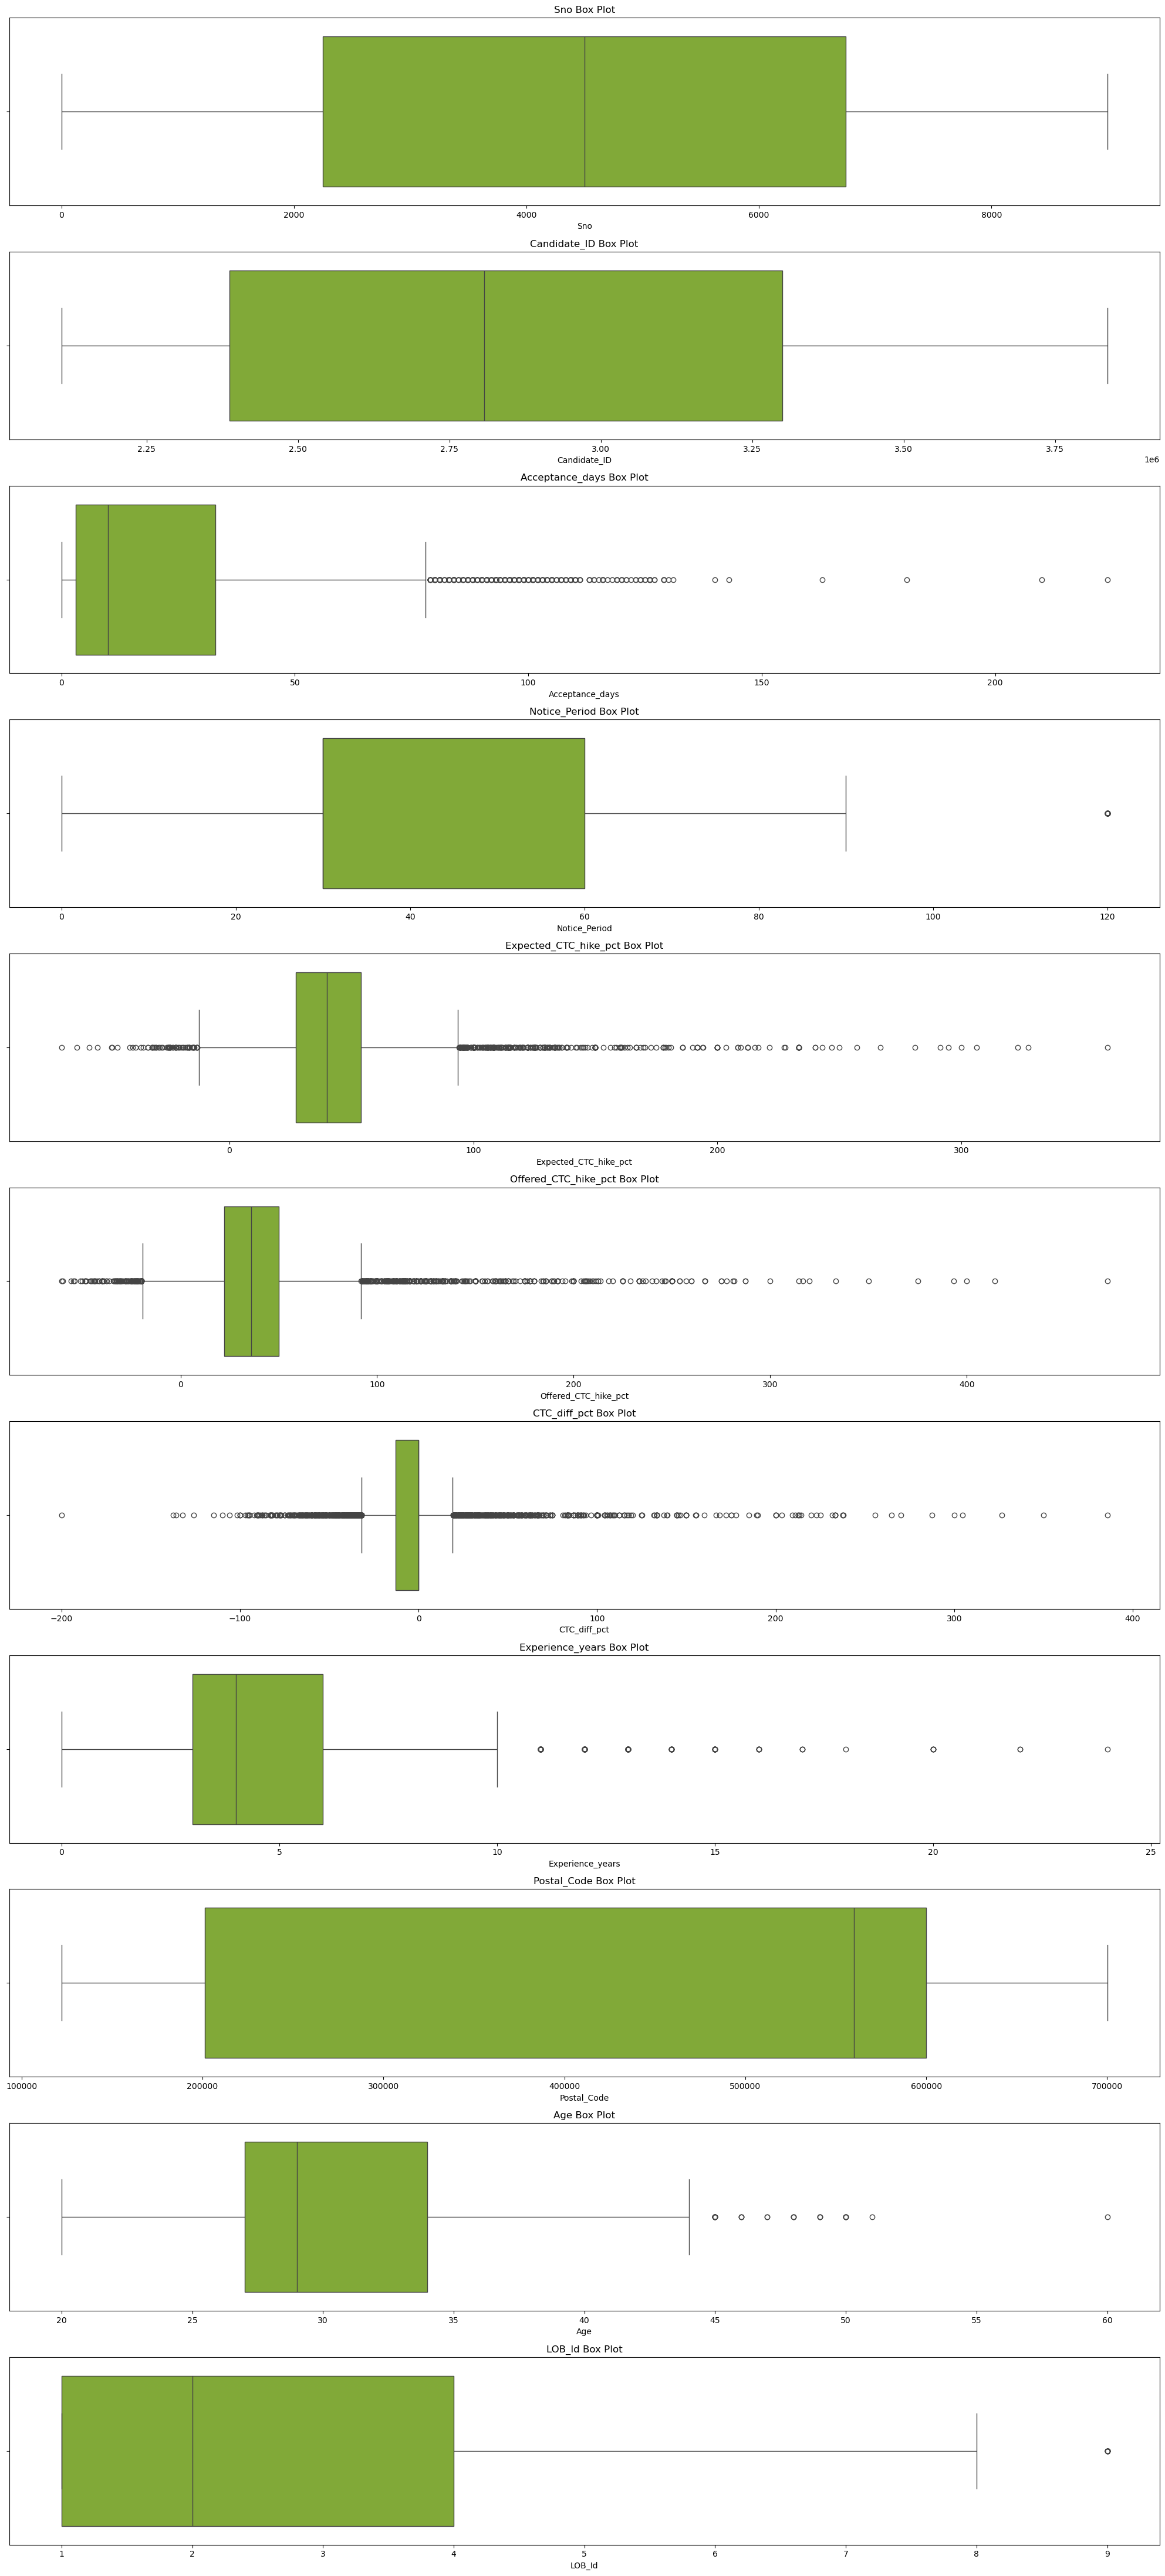

In [109]:
plt.figure(figsize=(20, 4 * len(numerical_columns)))

for count, num_col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, count)

    sns.boxplot(
        x=data1[num_col],
        color="#86BC25"
    )

    plt.title(f"{num_col} Box Plot")
    plt.xlabel(num_col)

plt.tight_layout()
plt.show()

In [110]:
# Outliers values for every numerical columns

for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = list(data1[num_col][(data1[num_col] < lower_bound) | (data[num_col] > upper_bound)])
    print(f"Column || {num_col} ||")
    print(f"Lower Bound = {lower_bound} & Upper Bound = {upper_bound}\n")
    print(f"For column || {num_col} || outliers = {outliers} \n")

Column || Sno ||
Lower Bound = -4496.0 & Upper Bound = 13492.0

For column || Sno || outliers = [] 

Column || Candidate_ID ||
Lower Bound = 1016100.75 & Upper Bound = 4670434.75

For column || Candidate_ID || outliers = [] 

Column || Acceptance_days ||
Lower Bound = -42.0 & Upper Bound = 78.0

For column || Acceptance_days || outliers = [120, 98, 83, 105, 84, 126, 106, 90, 103, 86, 93, 84, 107, 92, 79, 79, 108, 82, 210, 80, 97, 88, 90, 99, 86, 111, 87, 95, 98, 87, 96, 80, 91, 101, 98, 105, 79, 140, 93, 99, 86, 87, 93, 91, 123, 90, 88, 87, 104, 93, 98, 79, 126, 117, 87, 109, 96, 89, 88, 80, 98, 127, 81, 85, 86, 97, 81, 90, 81, 118, 101, 80, 114, 92, 81, 97, 105, 89, 88, 84, 95, 89, 84, 109, 97, 103, 92, 92, 110, 126, 129, 124, 96, 84, 85, 81, 86, 116, 103, 124, 84, 104, 92, 97, 181, 90, 123, 104, 129, 105, 86, 116, 91, 99, 94, 121, 121, 94, 93, 91, 119, 119, 102, 102, 96, 91, 113, 99, 88, 94, 109, 94, 95, 111, 107, 104, 109, 95, 97, 97, 115, 84, 110, 125, 114, 110, 81, 107, 96, 88, 10

In [111]:
# Checking min and max for numerical columns

for num_col in numerical_columns : 
    # Calculate IQR
    Q1 = data1[num_col].quantile(0.25)
    Q3 = data1[num_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_table = data1[num_col].min()
    max_table = data1[num_col].max()

    print(f"|| {num_col} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_bound}")
    print(f"Min = {min_table} | Lower Bond = {lower_bound}\n")

|| Sno ||
Max = 8995 | Upper Bound = 13492.0
Min = 1 | Lower Bond = -4496.0

|| Candidate_ID ||
Max = 3836076 | Upper Bound = 4670434.75
Min = 2109586 | Lower Bond = 1016100.75

|| Acceptance_days ||
Max = 224 | Upper Bound = 78.0
Min = 0 | Lower Bond = -42.0

|| Notice_Period ||
Max = 120 | Upper Bound = 105.0
Min = 0 | Lower Bond = -15.0

|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 93.72
Min = -68.83 | Lower Bond = -12.600000000000005

|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 91.86500000000001
Min = -60.53 | Lower Bond = -19.775000000000002

|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 19.1325
Min = -200.0 | Lower Bond = -31.8875

|| Experience_years ||
Max = 24 | Upper Bound = 10.5
Min = 0 | Lower Bond = -1.5

|| Postal_Code ||
Max = 700027 | Upper Bound = 1198098.5
Min = 122107 | Lower Bond = -396777.5

|| Age ||
Max = 60.0 | Upper Bound = 44.5
Min = 20.0 | Lower Bond = 16.5

|| LOB_Id ||
Max = 9 | Upper Bound = 8.5
Min = 1 | Lower Bond = -3.5



In [112]:
numerical_columns

['Sno',
 'Candidate_ID',
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Postal_Code',
 'Age',
 'LOB_Id']

### Columns to change the upper bound and lower bound
1. Acceptance_days
2. Expected_CTC_hike_pct
3. Offered_CTC_hike_pct
4. CTC_diff_pct
5. Experience_years
6. Age
7. Notice_Period
8. `Postal_Code is not included in Outliers treatment because its a Categorical Column but its datatype is numerical in nature. In later process we will treat that.`

## Counting Outliers with quartiles `+- 3 x (IQR)`

In [113]:
# Excluded: IDs, postal codes, and category codes
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_cap:
    q1 = data1[column].quantile(0.25)
    q3 = data1[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (3 * iqr)
    upper_limit = q3 + (3 * iqr)

    min_table = data1[column].min()
    max_table = data1[column].max()
    
    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    print(f"For column || {column} || number of outliers = {outlier_count}")
    print(f"\n|| {column} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_limit}")
    print(f"Min = {min_table} | Lower Bond = {lower_limit}\n")

print("Outliers have been counted using 3 × IQR.")

For column || Acceptance_days || number of outliers = 23

|| Acceptance_days ||
Max = 224 | Upper Bound = 123.0
Min = 0 | Lower Bond = -87.0

For column || Notice_Period || number of outliers = 0

|| Notice_Period ||
Max = 120 | Upper Bound = 150.0
Min = 0 | Lower Bond = -60.0

For column || Expected_CTC_hike_pct || number of outliers = 135

|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 133.59
Min = -68.83 | Lower Bond = -52.47000000000001

For column || Offered_CTC_hike_pct || number of outliers = 206

|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 133.73000000000002
Min = -60.53 | Lower Bond = -61.64

For column || CTC_diff_pct || number of outliers = 541

|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 38.265
Min = -200.0 | Lower Bond = -51.019999999999996

For column || Experience_years || number of outliers = 17

|| Experience_years ||
Max = 24 | Upper Bound = 15.0
Min = 0 | Lower Bond = -6.0

For column || Age || number of outliers = 1

|| Age ||
Max = 60.0 | 

### Changing Q1 and Q3 as `5 and 95 percentile`

In [114]:
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_cap:
    lower_limit = data1[column].quantile(0.05)
    upper_limit = data1[column].quantile(0.99)

    # data1[column] = data1[column].clip(
    #     lower=lower_limit,
    #     upper=upper_limit
    # )

    min_table = data1[column].min()
    max_table = data1[column].max()

    print(f"|| {column} ||")
    print(f"Max = {max_table} | Upper Bound = {upper_limit}")
    print(f"Min = {min_table} | Lower Bond = {lower_limit}\n")

print("Outliers counted using the 5th and 95th percentiles.")

|| Acceptance_days ||
Max = 224 | Upper Bound = 103.05999999999949
Min = 0 | Lower Bond = 0.0

|| Notice_Period ||
Max = 120 | Upper Bound = 90.0
Min = 0 | Lower Bond = 0.0

|| Expected_CTC_hike_pct ||
Max = 359.77 | Upper Bound = 150.0
Min = -68.83 | Lower Bond = 7.69

|| Offered_CTC_hike_pct ||
Max = 471.43 | Upper Bound = 185.71
Min = -60.53 | Lower Bond = 0.0

|| CTC_diff_pct ||
Max = 385.72 | Upper Bound = 100.6731999999981
Min = -200.0 | Lower Bond = -37.373999999999995

|| Experience_years ||
Max = 24 | Upper Bound = 13.0
Min = 0 | Lower Bond = 1.0

|| Age ||
Max = 60.0 | Upper Bound = 40.0
Min = 20.0 | Lower Bond = 24.0

Outliers counted using the 5th and 95th percentiles.


### Changing Q1 and Q3 as `3 and 99 percentile`

In [115]:
columns_to_check = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

for column in columns_to_check:
    lower_limit = data1[column].quantile(0.03)
    upper_limit = data1[column].quantile(0.99)

    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    print(f"For column || {column} || number of outliers = {outlier_count}")
    print(f"Max = {data1[column].max()} | Upper Bound = {upper_limit}")
    print(f"Min = {data1[column].min()} | Lower Bound = {lower_limit}\n")

print("Outliers counted using the 5th and 99th percentile limits.")

For column || Acceptance_days || number of outliers = 90
Max = 224 | Upper Bound = 103.05999999999949
Min = 0 | Lower Bound = 0.0

For column || Notice_Period || number of outliers = 42
Max = 120 | Upper Bound = 90.0
Min = 0 | Lower Bound = 0.0

For column || Expected_CTC_hike_pct || number of outliers = 351
Max = 359.77 | Upper Bound = 150.0
Min = -68.83 | Lower Bound = 1.7355999999999994

For column || Offered_CTC_hike_pct || number of outliers = 358
Max = 471.43 | Upper Bound = 185.71
Min = -60.53 | Lower Bound = -9.689

For column || CTC_diff_pct || number of outliers = 360
Max = 385.72 | Upper Bound = 100.6731999999981
Min = -200.0 | Lower Bound = -45.934400000000004

For column || Experience_years || number of outliers = 300
Max = 24 | Upper Bound = 13.0
Min = 0 | Lower Bound = 1.0

For column || Age || number of outliers = 140
Max = 60.0 | Upper Bound = 40.0
Min = 20.0 | Lower Bound = 23.0

Outliers counted using the 5th and 99th percentile limits.


In [116]:
data1.shape

(8995, 26)

In [117]:
#data1 = data.copy(deep=True)

In [118]:
#data1.shape

### After observing all 3 different methods for Outlier Treatment, we can conlcude that - 
- `Forwarding ahead with 3 x of IQR as Outlier Treatment`
- `Clip the outlier cap with Upper limit and Lower limit`


## Capping outliers with Lower and Upper bounds determined as 
- #### `Lower Bound = Q1 - 3 x IQR`
- #### `Upper Bound = Q3 + 3 x IQR`

In [119]:
columns_to_cap = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Experience_years",
    "Age"
]

iqr_limits = {}

for column in columns_to_cap:
    q1 = data1[column].quantile(0.25)
    q3 = data1[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (3 * iqr)
    upper_limit = q3 + (3 * iqr)

    iqr_limits[column] = (lower_limit, upper_limit)

    data1[column] = data1[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outliers capped using 3 × IQR limits.")

Outliers capped using 3 × IQR limits.


### Checking for outliers if remained in case.

In [120]:
outlier_check = []

for column in columns_to_cap:
    lower_limit, upper_limit = iqr_limits[column]

    outlier_count = (
        (data1[column] < lower_limit) |
        (data1[column] > upper_limit)
    ).sum()

    min_col = data1[column].min()
    max_col = data1[column].max()

    outlier_check.append({
        "Column": column,
        "Minimum": min_col,
        "maximum": max_col,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outliers After Treatment": outlier_count
    })

outlier_check = pd.DataFrame(outlier_check)

outlier_check

,Column,Minimum,maximum,Lower Limit,Upper Limit,Outliers After Treatment
0,Acceptance_days,0.00,123.000,-87.00,123.000,0
1,Notice_Period,0.00,120.000,-60.00,150.000,0
2,Expected_CTC_hike_pct,-52.47,133.590,-52.47,133.590,0
3,Offered_CTC_hike_pct,-60.53,133.730,-61.64,133.730,0
4,CTC_diff_pct,-51.02,38.265,-51.02,38.265,0
5,Experience_years,0.00,15.000,-6.00,15.000,0
6,Age,20.00,55.000,6.00,55.000,0


## BoxPlots after the Outlier Treatment


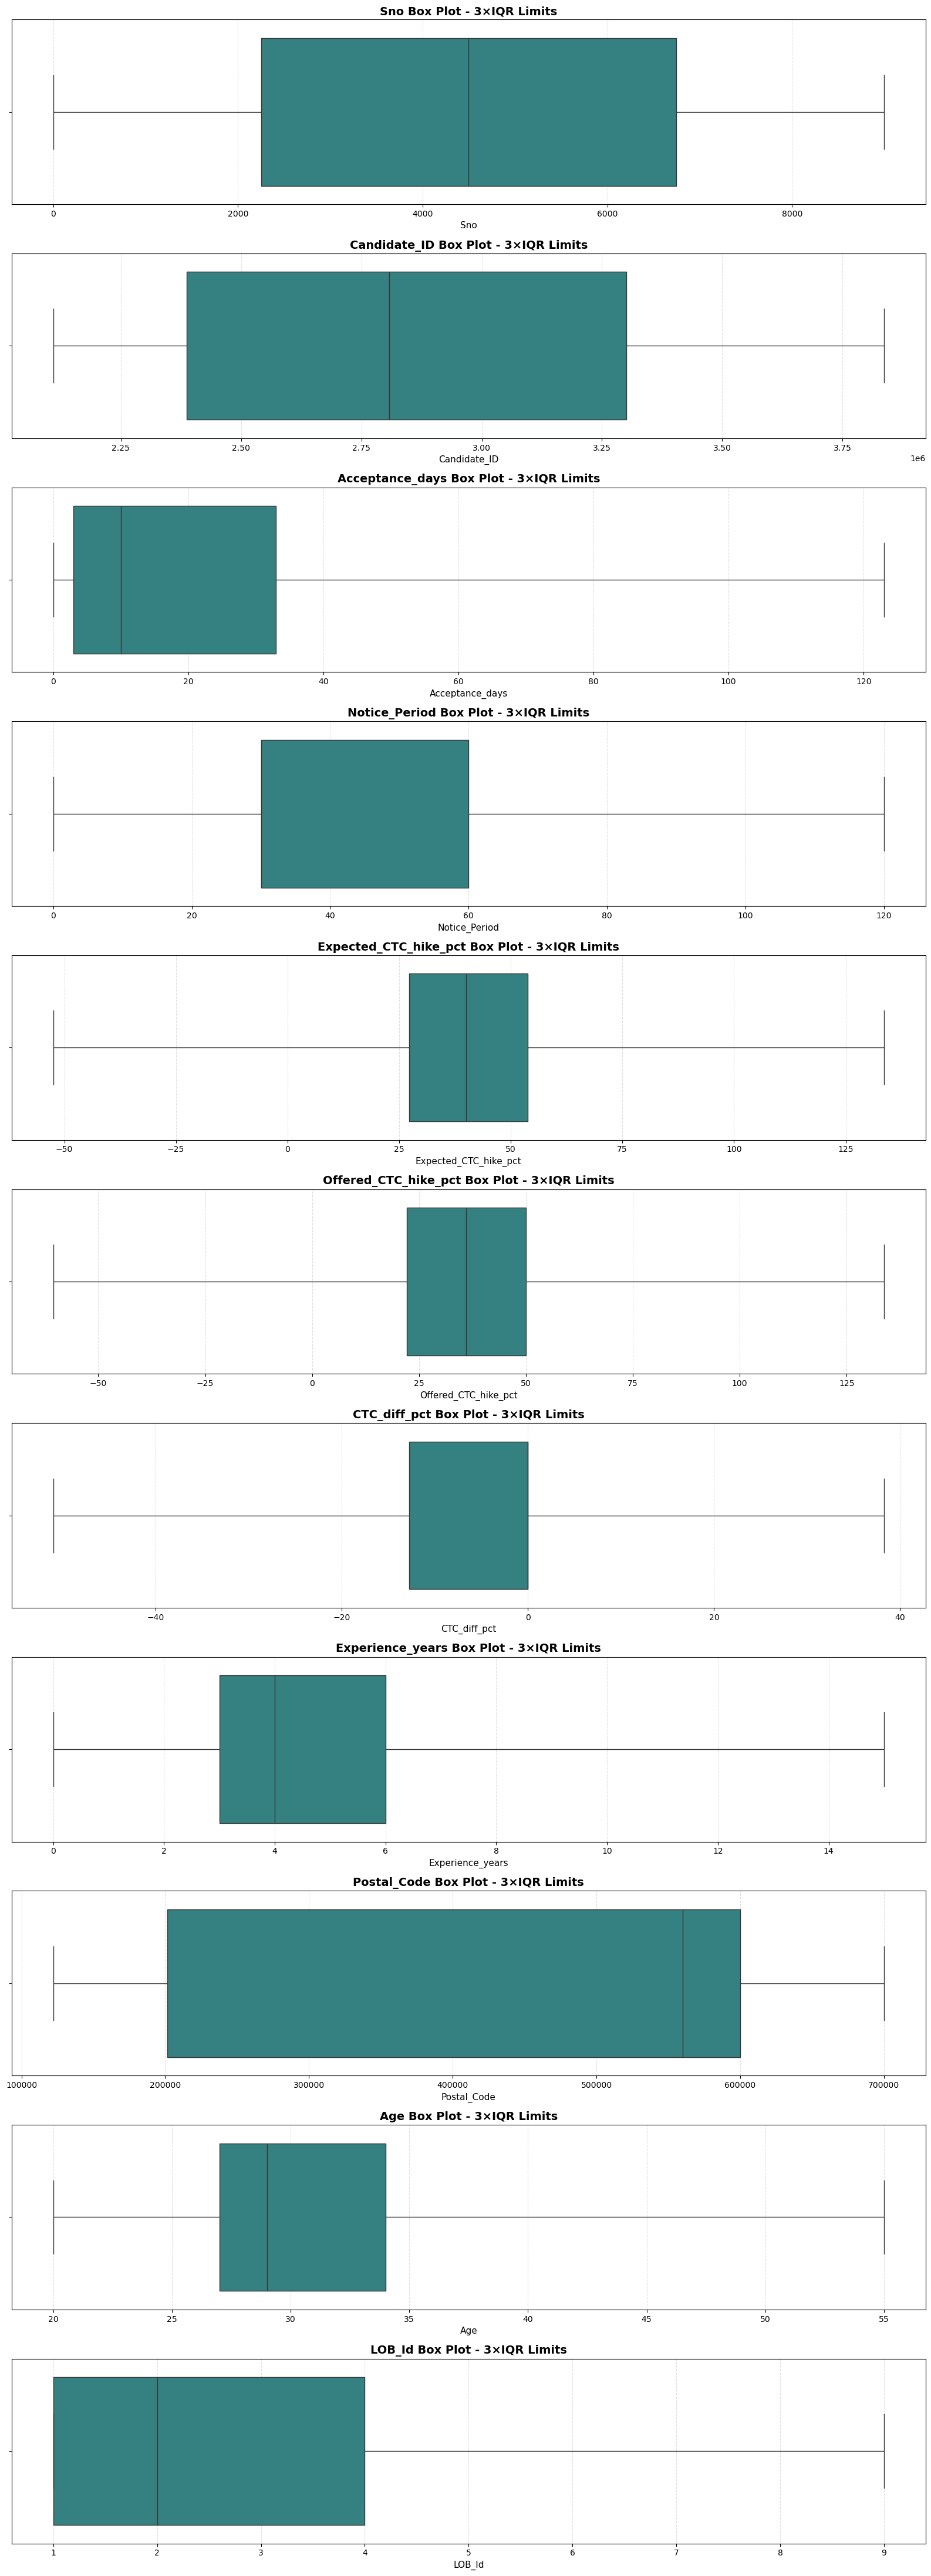

In [121]:
fig, axes = plt.subplots(
    nrows=len(numerical_columns),
    ncols=1,
    figsize=(16, 4 * len(numerical_columns))
)

axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):
    sns.boxplot(
        x=data1[column].dropna(),
        color="#298C8C",
        whis=3,
        ax=ax
    )

    ax.set_title(
        f"{column} Box Plot - 3×IQR Limits",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel(column, fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Outliers Treatment Done!

 <a id="date-time"></a>

<h2 style="color: green; font-weight: 800;">Treatment of Date_of_Interview Column</h2>

- Its data type is `Object`
- So have to handle it, either have to change its Data Type or separating Date, Month, Year in different columns.

In [122]:
print(f"Data Type of Date_of_Interview Column = {data1['Date_of_Interview'].dtype}")
print(data1['Date_of_Interview'].head(10))
print(data1['Date_of_Interview'].unique()[:10]) 

Data Type of Date_of_Interview Column = object
0    2013-01-08
1    2013-01-12
2    2013-01-25
3    2013-01-27
4    2013-01-28
5    2013-02-03
6    2013-02-11
7    2013-02-16
8    2013-02-16
9    2013-03-07
Name: Date_of_Interview, dtype: object
['2013-01-08' '2013-01-12' '2013-01-25' '2013-01-27' '2013-01-28'
 '2013-02-03' '2013-02-11' '2013-02-16' '2013-03-07' '2013-04-03']


### Changing the data type of Date_of_Interview column from `Object` to `Date_Time`

In [123]:
data1['Date_of_Interview'] = pd.to_datetime(data1['Date_of_Interview'], errors='coerce')

In [124]:
print(f"Data Type of Date_of_Interview Column = {data1['Date_of_Interview'].dtype}")


Data Type of Date_of_Interview Column = datetime64[ns]


 <a id="postal-code-treatment"></a>

<h2 style="color: green; font-weight: 800;">Treatment of Postal Code Column</h2>

In [125]:
data1['Postal_Code'].head()

0    201301
1    600020
2    201301
3    201301
4    201301
Name: Postal_Code, dtype: int64

In [126]:
type(data1['Postal_Code'])

pandas.core.series.Series

In [127]:
print(f"Data Type of Postal_Code column = {type(data1['Postal_Code'][0])}")

Data Type of Postal_Code column = <class 'numpy.int64'>


In [128]:
data1['Postal_Code'].value_counts()

Postal_Code
600020    3150
201301    2727
560034    2231
500004     342
400001     200
122107     146
700027     130
411002      49
682001       8
382460       7
600018       1
560002       1
560063       1
500045       1
411006       1
Name: count, dtype: int64

In [129]:
print(f"No of Categories in Postal_Code column = {len(list(data1['Postal_Code'].value_counts()))}")

No of Categories in Postal_Code column = 15


- ##### Here we can see `Postal_Code` code column's data type is `int` rather than `object`,
- ##### But the problem is its behaving as `Categorical Column` not `Continuous Numerical Column`.
- ##### There are only 15 different Postal Codes.
- ##### So changing its data type from `int` to `string`
- ##### Doing this we can make the column as Categorical Column and in labeling we will label it further.

In [130]:
print(f"Before. Postal_Code dtype: {data1['Postal_Code'].dtype}")

data1['Postal_Code'] = data1['Postal_Code'].astype(str)

print(f"After. Postal_Code dtype: {data1['Postal_Code'].dtype}")

Before. Postal_Code dtype: int64
After. Postal_Code dtype: object


 <a id="numerical-plots"></a>

<h2 style="color: green; font-weight: 800;">Distribution Plots of Numerical Columns</h2>

In [131]:
numerical_columns

['Sno',
 'Candidate_ID',
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Postal_Code',
 'Age',
 'LOB_Id']

Columns removed from Visualization = 
1. Sno
2. Candiadte_ID
3. Postal_Code
4. LOB_Id


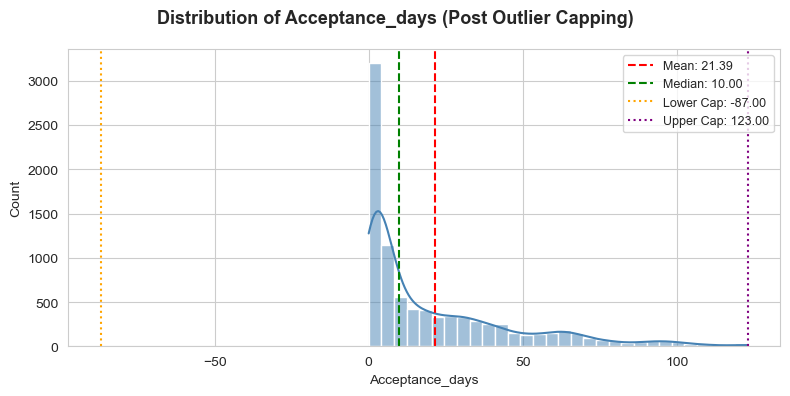

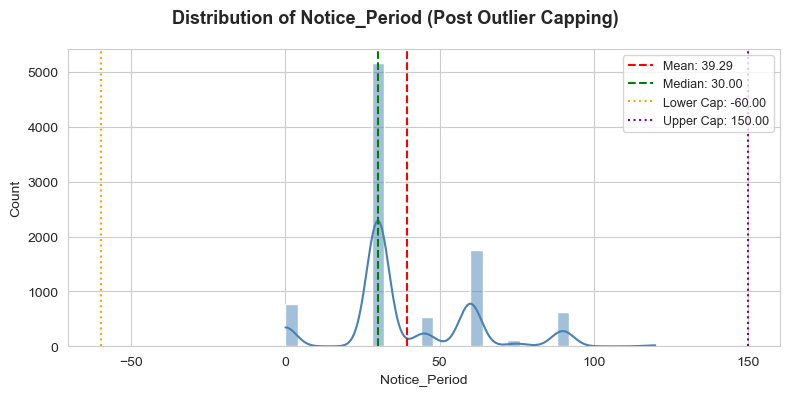

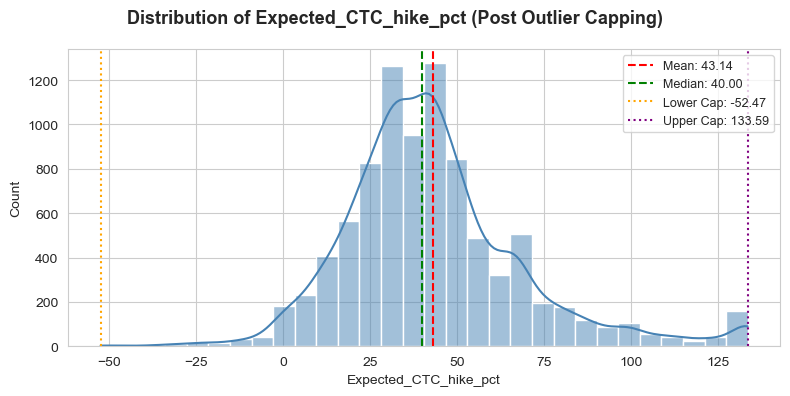

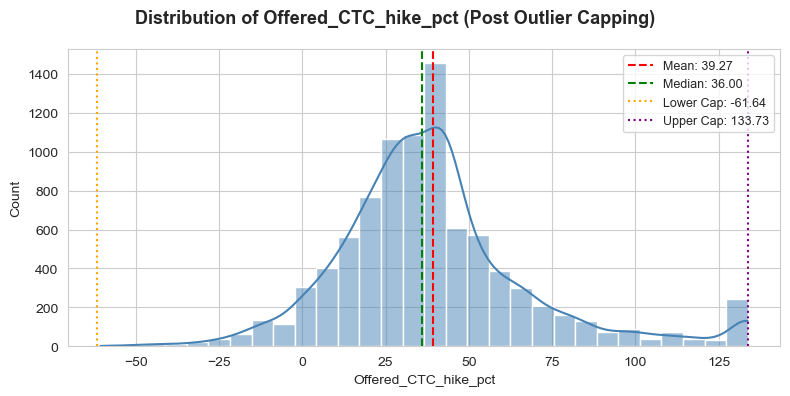

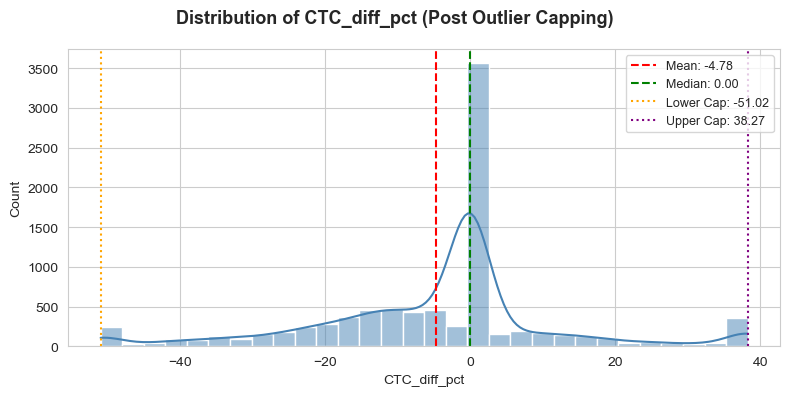

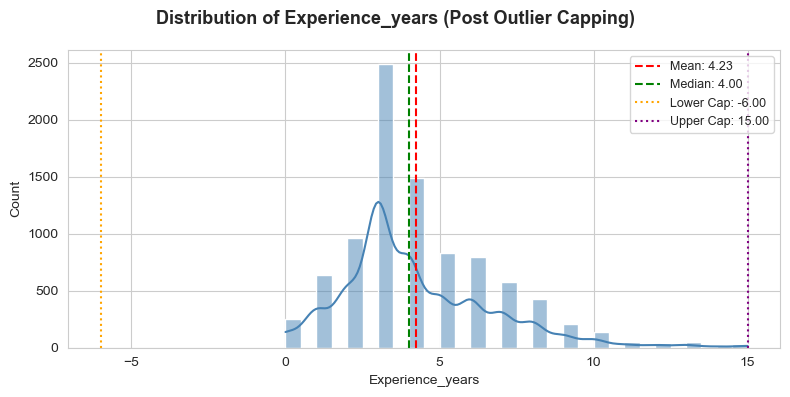

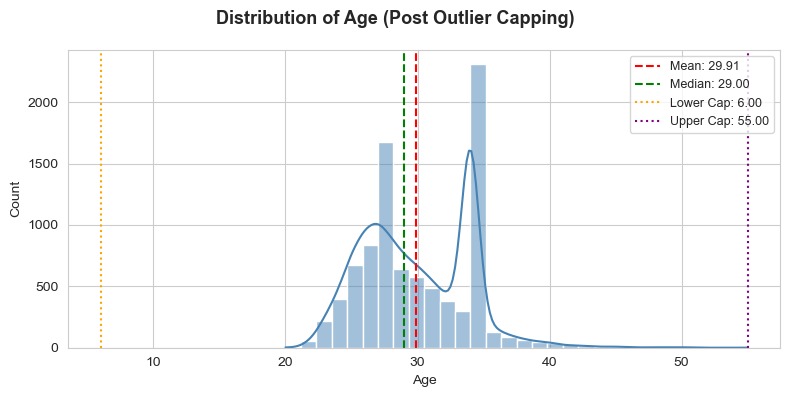

In [132]:
sns.set_style("whitegrid")

numerical_columns2 = [
 'Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Age'
]

for col in numerical_columns2:
    lower_limit, upper_limit = iqr_limits[col]

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f'Distribution of {col} (Post Outlier Capping)', 
                 fontsize=13, fontweight='bold')

    sns.histplot(data1[col].dropna(), kde=True, ax=ax,
                 color='steelblue', edgecolor='white', bins=30)

    ax.axvline(data1[col].mean(),   color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean: {data1[col].mean():.2f}')
    ax.axvline(data1[col].median(), color='green',  linestyle='--',
               linewidth=1.5, label=f'Median: {data1[col].median():.2f}')
    ax.axvline(lower_limit, color='orange', linestyle=':',
               linewidth=1.5, label=f'Lower Cap: {lower_limit:.2f}')
    ax.axvline(upper_limit, color='purple', linestyle=':',
               linewidth=1.5, label=f'Upper Cap: {upper_limit:.2f}')

    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Numerical Columns

1. ### **`Acceptance_days`**

- *Heavy right skewed* — majority of candidates accepted within 0–10 days (median: 10), but a long tail stretches to 120+ days
- *Mean (21.39) is pulled far right of median* — classic skew signal

2. ### **`Notice_Period`**

- *Multi-modal distribution* — clear spikes at 0, 30, 60, and 90 days — this makes perfect sense as notice periods are typically fixed contractual values
- Median of 30 days is the dominant notice period
- Mean (39.29) is dragged up by the 60/90-day clusters


3. ### **`Expected_CTC_hike_pct`**

- *Fairly normal with a slight right skew* — centered around 40% (median)
- *Mean and median are very close (43.14 vs 40)* — relatively balanced distribution
- *Spike near the upper cap (~130%) worth noting* — some candidates had very high expectations


4. ### **`Offered_CTC_hike_pct`**

- *Very similar shape to Expected_CTC_hike_pct* — near-normal, centered around 36–39%
- *Slightly lower median (36) vs expected (40)* — suggests offers came in below candidate expectations on average
- *Same upper cap spike visible* — mirrors the expected hike pattern

5. ### **`CTC_diff_pct`**

- *Most candidates were offered less than expected* — left skew with mean at -4.78 while median sits at 0
- Large spread from -50 to 0 suggests many candidates were significantly under-offered
- *Small spike near upper cap (38.27)* — a niche group received well above expectations


6. ### **`Experience_years`**

- *Sharp dominant peak at 3–4 years* — predominantly an early-career hiring pool (mean: 4.23, median: 4.00)
- A gradual right tail up to 15 years indicates a smaller but present mid-to-senior segment
- Secondary clusters around 6–10 years suggest two distinct hiring tracks


7. ### **`Age`**

- *Bimodal distribution with clear peaks at ~28 and ~34 years*, aligning with the two experience clusters
- *Mean (29.91) and median (29.00) are very close* — distribution is balanced around late 20s
- Workforce skews young, concentrated in the late 20s to early 30s

 <a id="categorical-plots"></a>

<h2 style="color: green; font-weight: 800;">Plots of Categorical Columns</h2>

In [133]:
categorical_columns = list(data1.select_dtypes(include = 'object'))

print(f"Categorical Columns = {categorical_columns}")

Categorical Columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Postal_Code', 'Domicile_Id', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name', 'Status']


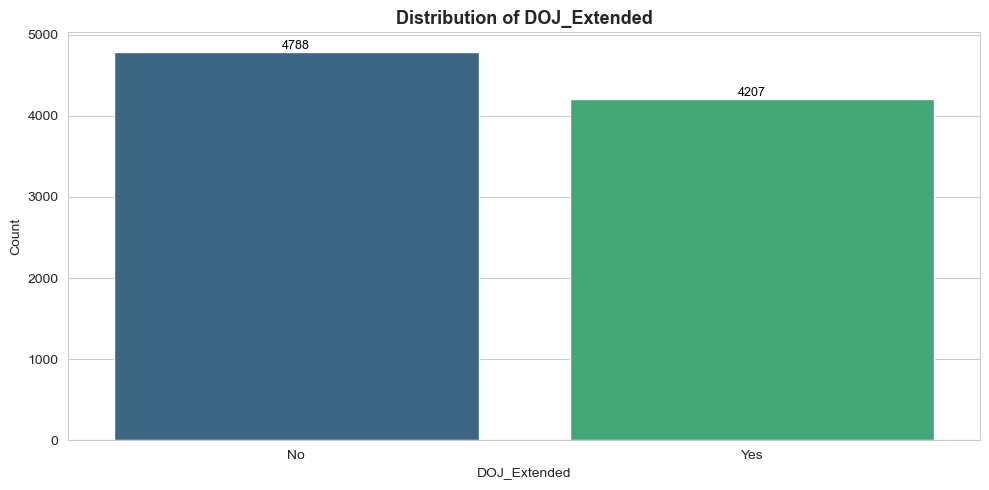

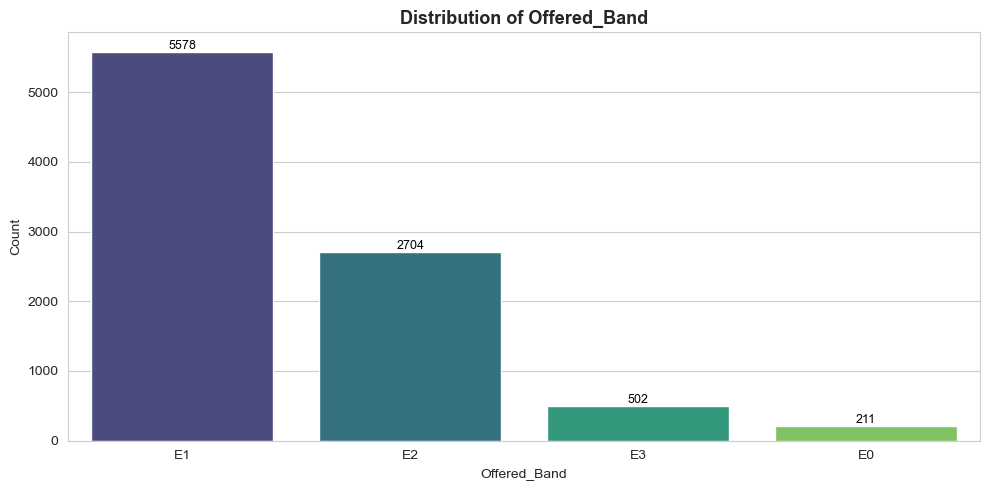

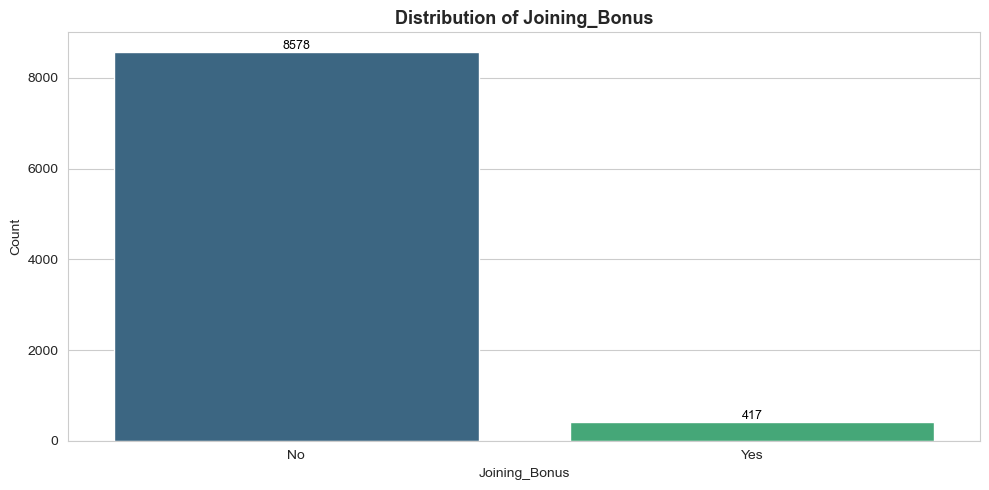

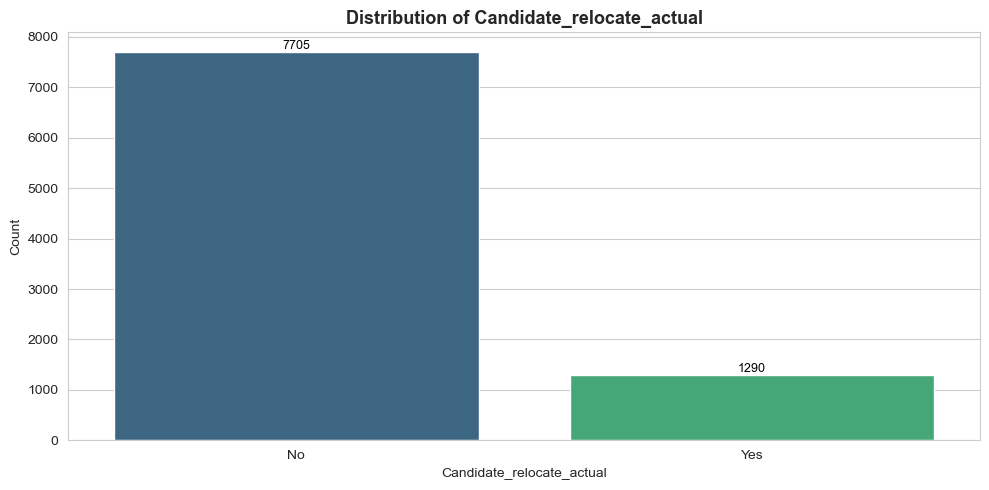

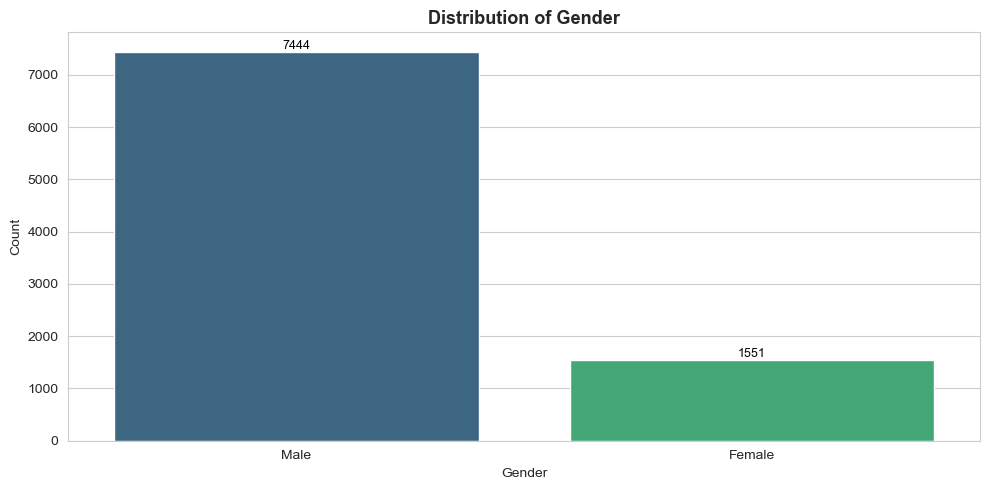

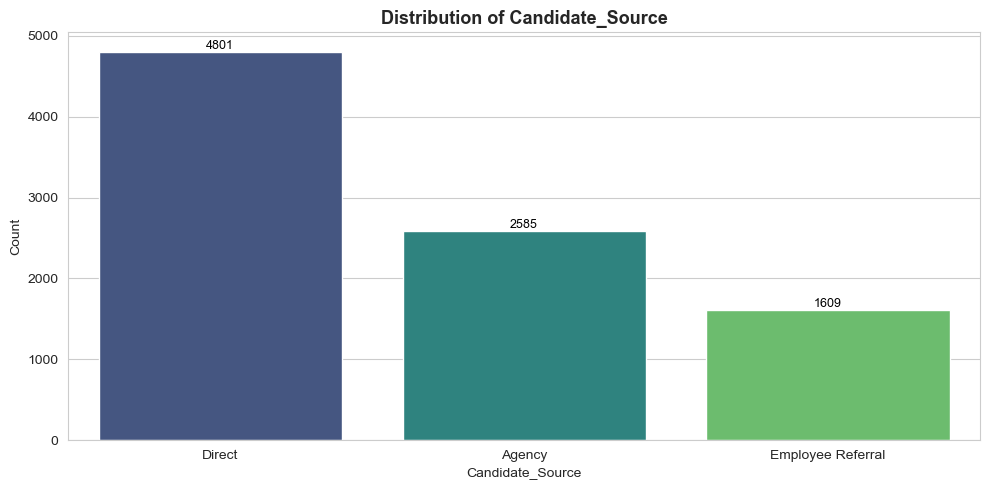

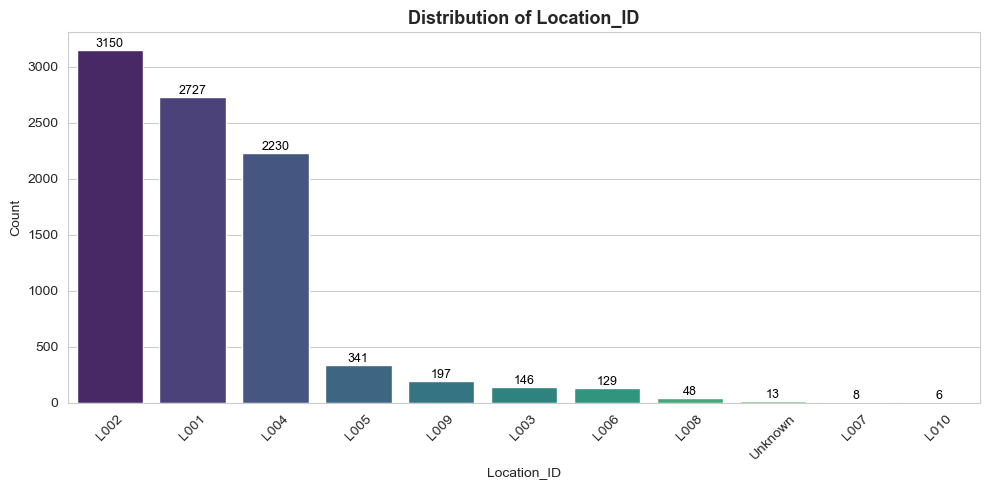

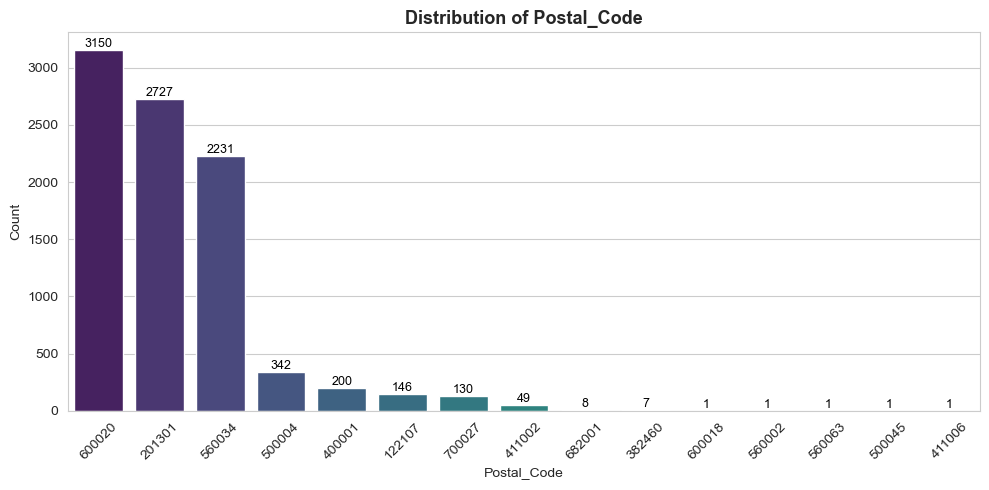

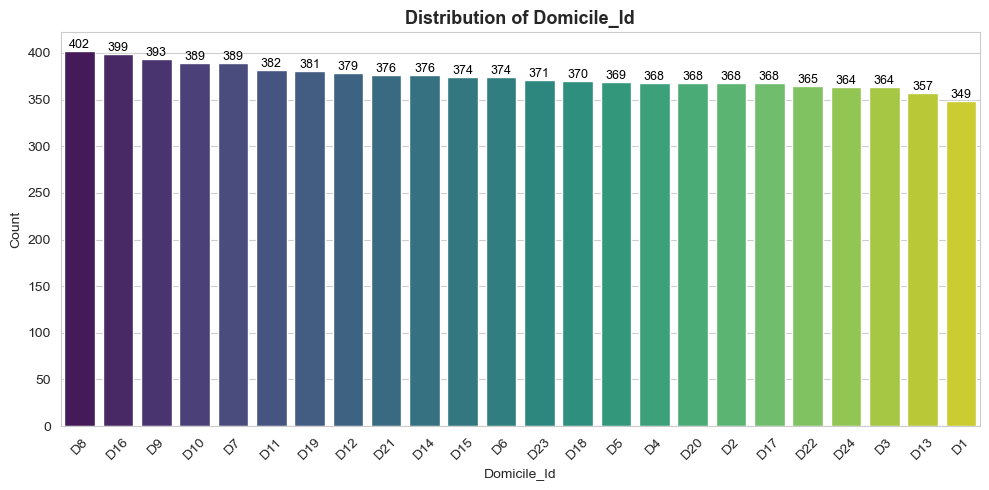

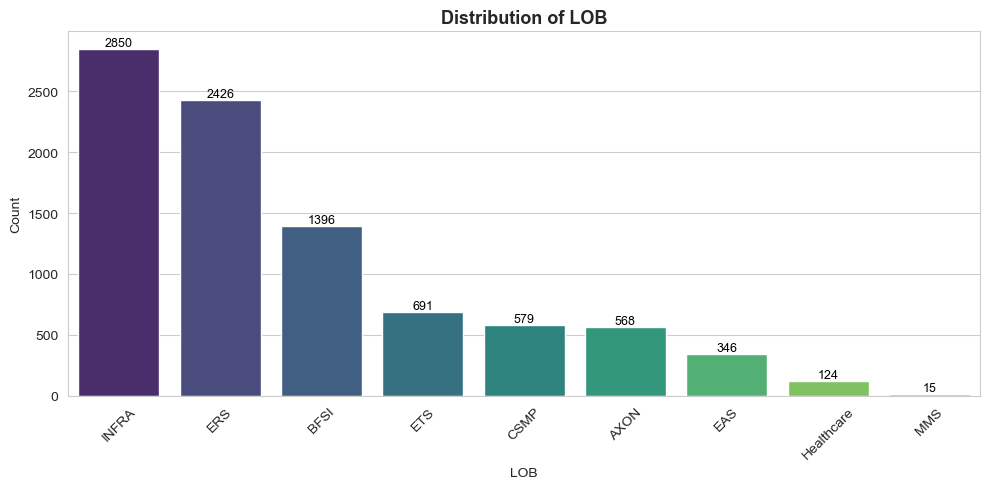

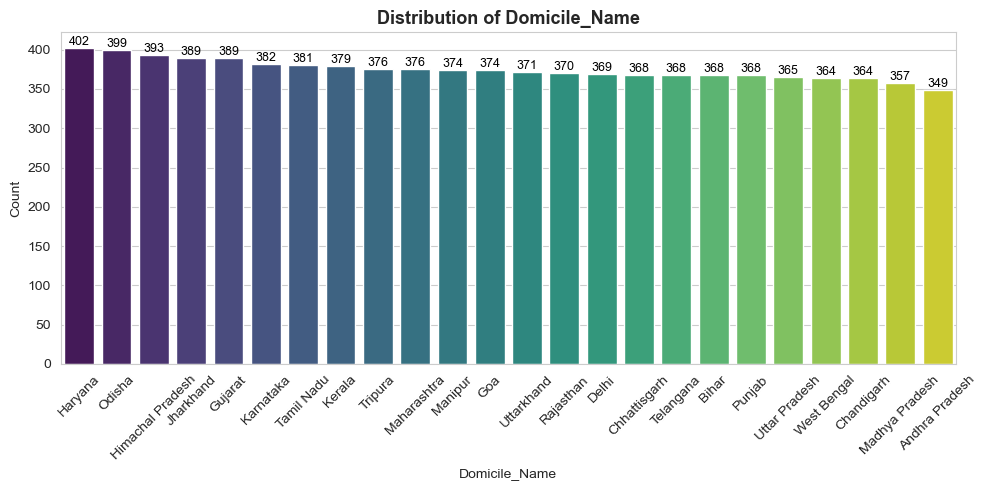

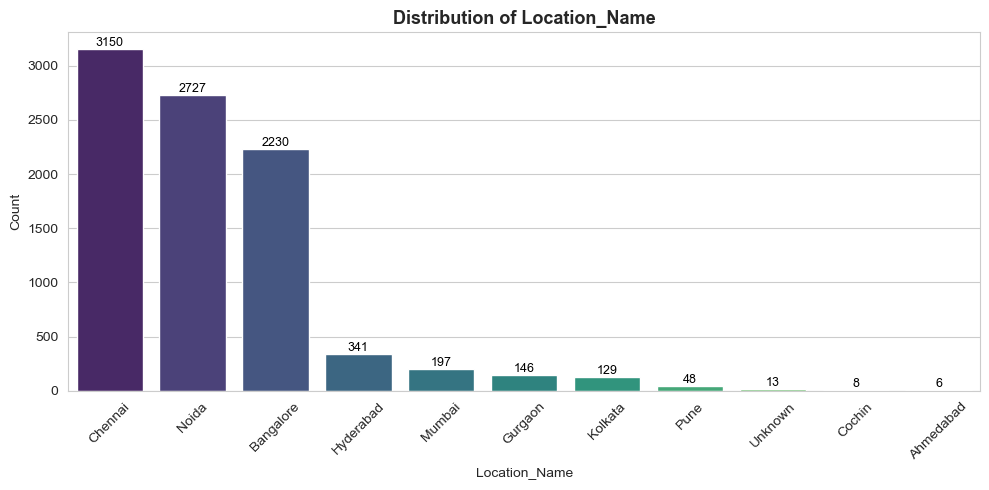

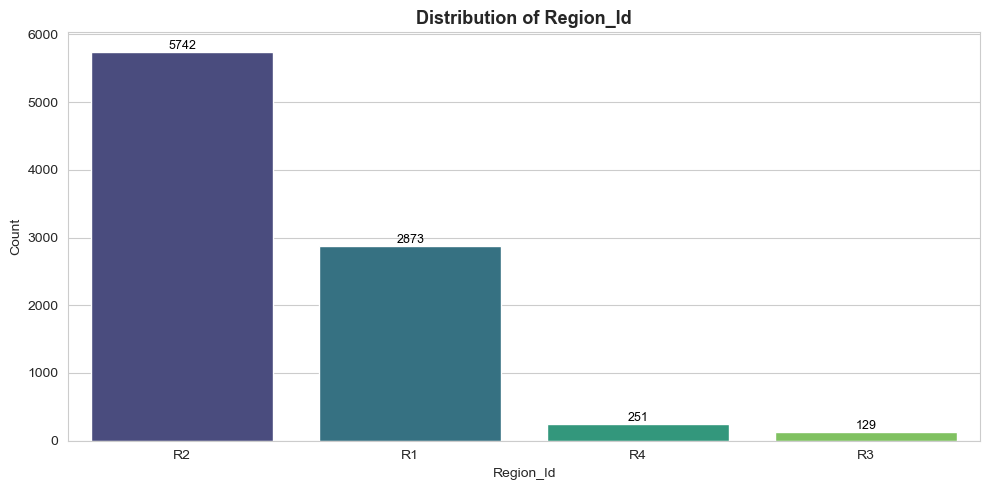

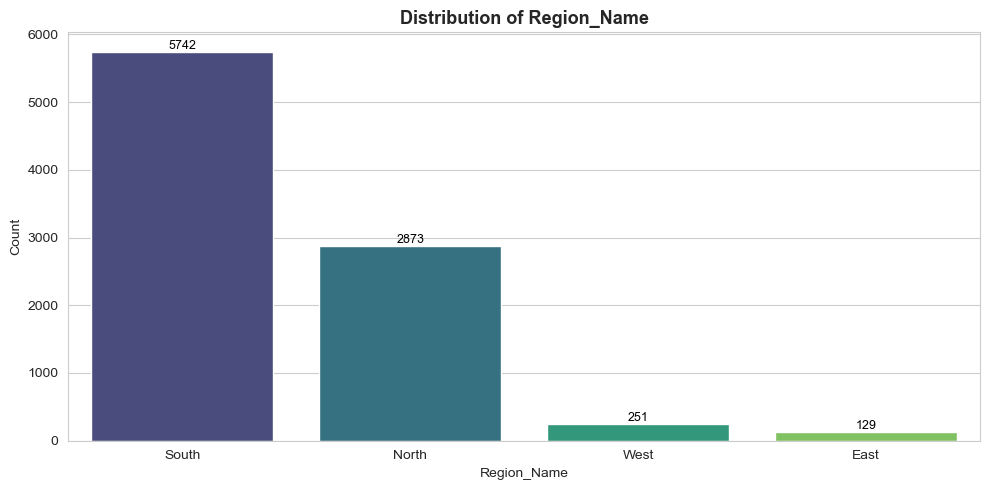

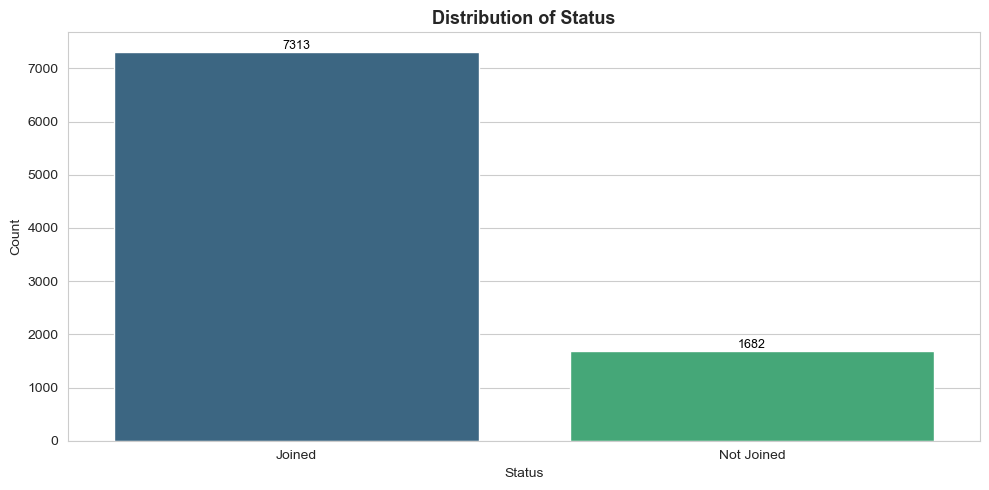

In [134]:
sns.set_style("whitegrid")

for col in categorical_columns:
    value_counts = data1[col].value_counts()

    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax,
                palette='viridis', edgecolor='white')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black')

    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x')

    if len(value_counts.index) > 5:
       plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Categorical Columns


1. *`DOJ_Extended`*

- Nearly balanced split — 53% candidates did not extend DOJ vs 47% who did, suggesting DOJ extension is a common occurrence worth investigating for its impact on joining
- High "Yes" volume (4207) signals a systemic delay pattern, not an exception



2. *`Offered_Band`*

- Heavily skewed toward E1 — E1 alone accounts for ~62% of all offers, with E2 at 30%; E0 and E3 are negligible minorities
- Band distribution is entry-level dominated, which may explain higher dropout rates if compensation expectations don't match



3. *`Joining_Bonus`*

- Extremely imbalanced — 95.4% candidates received no joining bonus, making this feature nearly a constant with very low predictive signal
- The 417 who received a bonus form too small a group to draw strong conclusions without targeted analysis



4. *`Candidate_relocate_actual`*

- Majority didn't relocate (85.7%) — relocation is an exception, not the norm in this dataset
- The 1290 who relocated represent a key subgroup to watch for dropout risk given the added friction of moving



5. *`Gender`*

- Heavily male-dominated — Males make up ~83% (7444) of candidates vs 17% Female (1551), indicating a strong gender skew in the hiring process



6. *`Candidate_Source`*

- Direct hiring leads at 53%, followed by Agency (28%) and Employee Referral (18%) — referral channel is notably smaller
- Agency sourcing, being the costliest channel, warrants a dropout rate check to validate ROI



7. *`Location_ID`*

- Top 3 locations (L002, L001, L004) account for ~90% of all candidates — remaining 7 locations are negligible in volume
- Heavy concentration means location-level insights are effectively driven by just Chennai, Noida, and Bangalore



8. *`Domicile_Id`*

- Remarkably uniform distribution — all 24 domicile IDs hover between 349–402 candidates, suggesting deliberate geographic spread in sourcing
- No single domicile dominates, making this a well-balanced feature across states



9. *`LOB`*

- INFRA and ERS together account for ~58% of candidates — bottom 3 (Healthcare, MMS, EAS) are severely underrepresented
- MMS with just 15 candidates is statistically insignificant and may skew LOB-level analysis



10. *`Domicile_Name`*

- Evenly spread across 24 Indian states — Haryana tops slightly at 402 but the range is narrow (349–402), confirming balanced geographic sourcing
- No state-level outlier, domicile is unlikely to be a strong predictor of joining behavior



11. *`Location_Name`*

- Chennai, Noida, and Bangalore are the dominant hiring hubs — together ~90% of volume; all other cities are long-tail
- Pune (48), Cochin (8), and Ahmedabad (6) have too little data for reliable location-specific insights



12. *`Region_Id / Region_Name`*

- South region overwhelmingly dominates at 64% (5742), followed by North at 32% (2873) — West and East are near-absent
- East region (129 candidates) is too thin to draw conclusions; regional analysis is effectively a South vs North story

13. *`Postal_Code`*

- Clear Class imbalance - most of the Candidates majorly comes from particular 3 Postal Codes

13. *`Status`*

- Clear class imbalance — 81.3% Joined vs 18.7% Not Joined; the dataset is significantly skewed toward joiners
- This imbalance is important — any predictive model built on this data must handle it to avoid biased results



 <a id="all-vs-status-statistical"></a>

<h2 style="color: green; font-weight: 800;">All Columns vs Status(Target Feature) Statistical Analysis</h2>

In [135]:
target  = 'Status'

numerical_columns = list(data1.select_dtypes(include='number').columns)

category_wo_status = [
    'DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual',
    'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'LOB','Postal_Code',
    'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name'
]

SEP = "=" * 60

# SECTION 1: Categorical vs Status (Stacked % Table)
print("\n" + SEP)
print("   SECTION 1 — CATEGORICAL FEATURES vs STATUS (%)")
print(SEP)

for col in category_wo_status:
    ct = pd.crosstab(data1[col], data1[target], normalize='index') * 100
    ct = ct.round(2)
    ct['Total_Count'] = pd.crosstab(data1[col], data1[target]).sum(axis=1)
    ct.index.name = col

    print(f"\n--- {col} ---")
    print(ct.to_string())

# SECTION 2: Numerical vs Status (Descriptive Stats Table)
print("\n\n" + SEP)
print("   SECTION 2 — NUMERICAL FEATURES vs STATUS (Stats)")
print(SEP)

stats_to_show = ['mean', 'median', 'std', 'min', 'max',
                 lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
stat_names    = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1 (25%)', 'Q3 (75%)']

for col in numerical_columns:
    print(f"\n--- {col} ---")
    grouped = data1.groupby(target)[col].agg(stats_to_show)
    grouped.columns = stat_names
    print(grouped.round(2).to_string())


   SECTION 1 — CATEGORICAL FEATURES vs STATUS (%)

--- DOJ_Extended ---
Status        Joined  Not Joined  Total_Count
DOJ_Extended                                 
No             81.08       18.92         4788
Yes            81.55       18.45         4207

--- Offered_Band ---
Status        Joined  Not Joined  Total_Count
Offered_Band                                 
E0             76.30       23.70          211
E1             81.32       18.68         5578
E2             80.92       19.08         2704
E3             85.26       14.74          502

--- Joining_Bonus ---
Status         Joined  Not Joined  Total_Count
Joining_Bonus                                 
No              81.34       18.66         8578
Yes             80.58       19.42          417

--- Candidate_relocate_actual ---
Status                     Joined  Not Joined  Total_Count
Candidate_relocate_actual                                 
No                          78.17       21.83         7705
Yes                   

# Visual representation of Categorical Columns vs Target (Status)

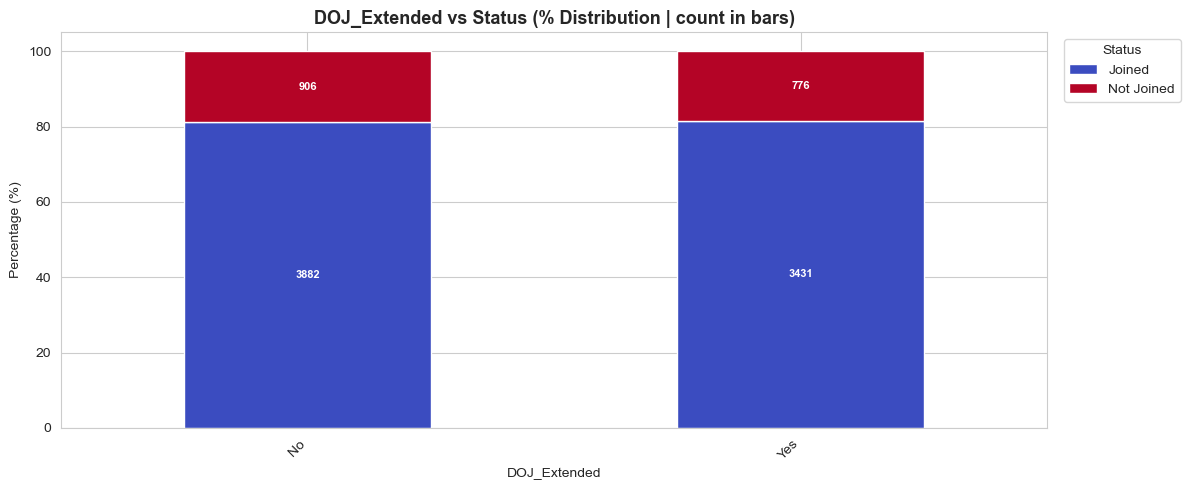

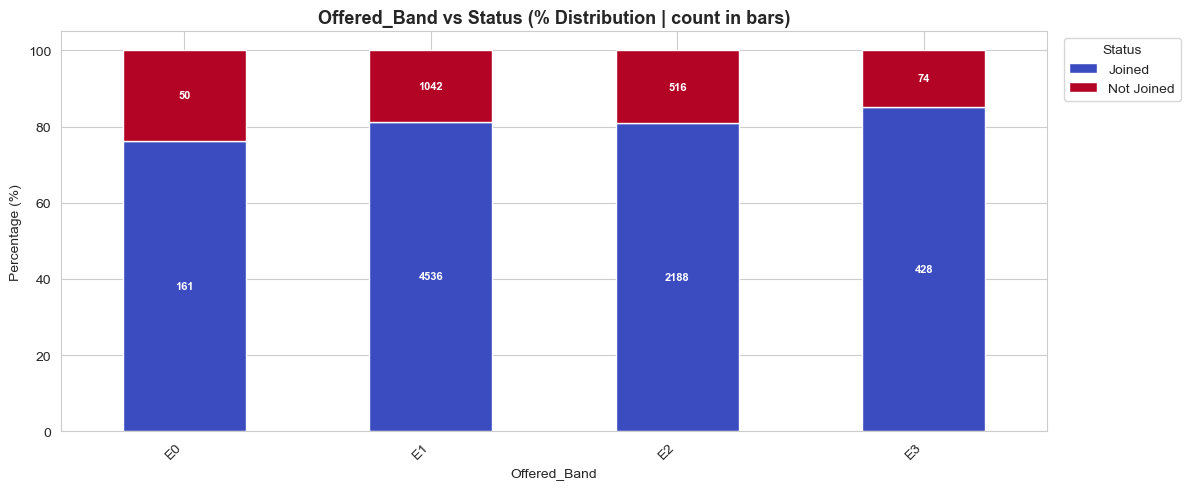

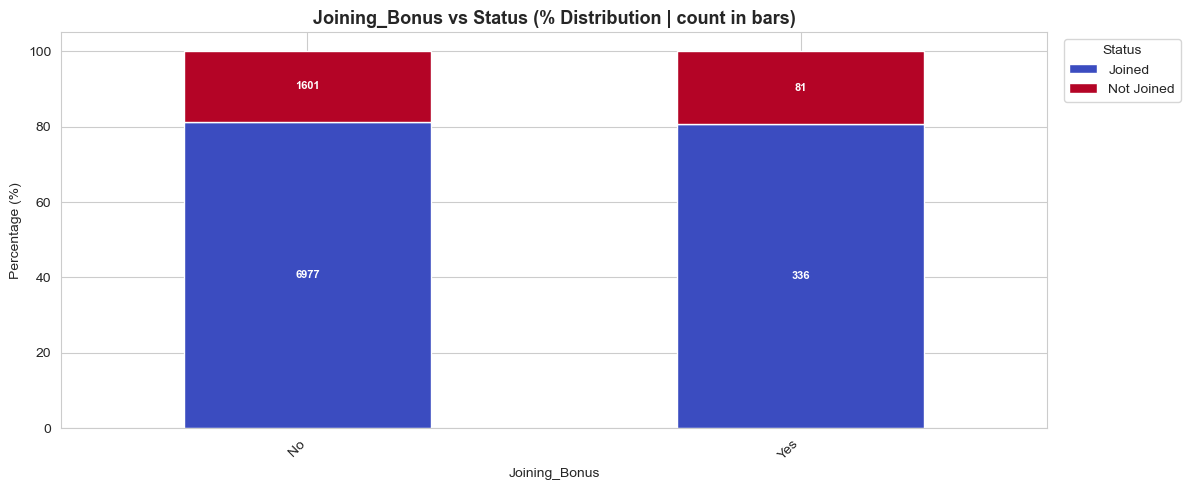

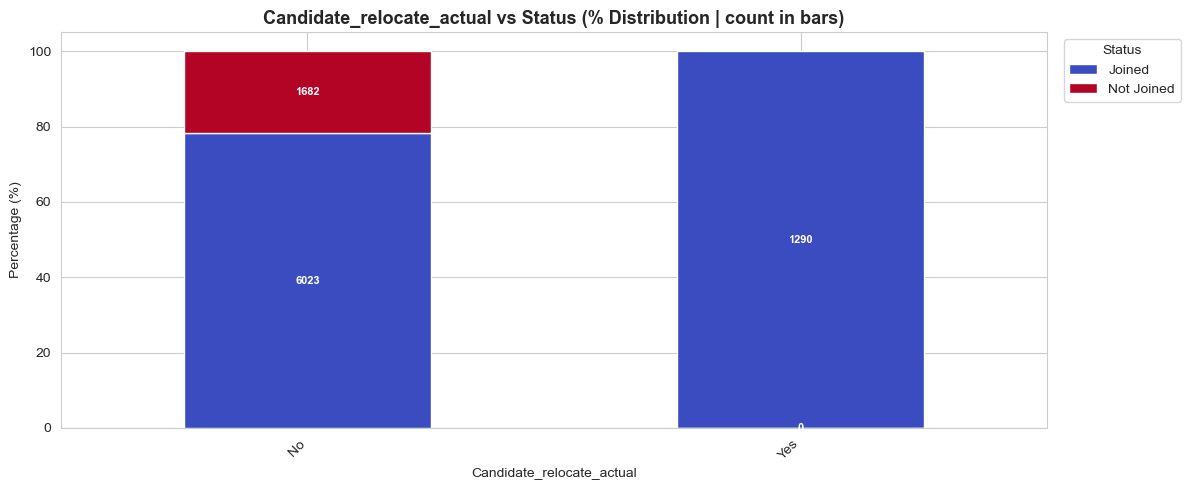

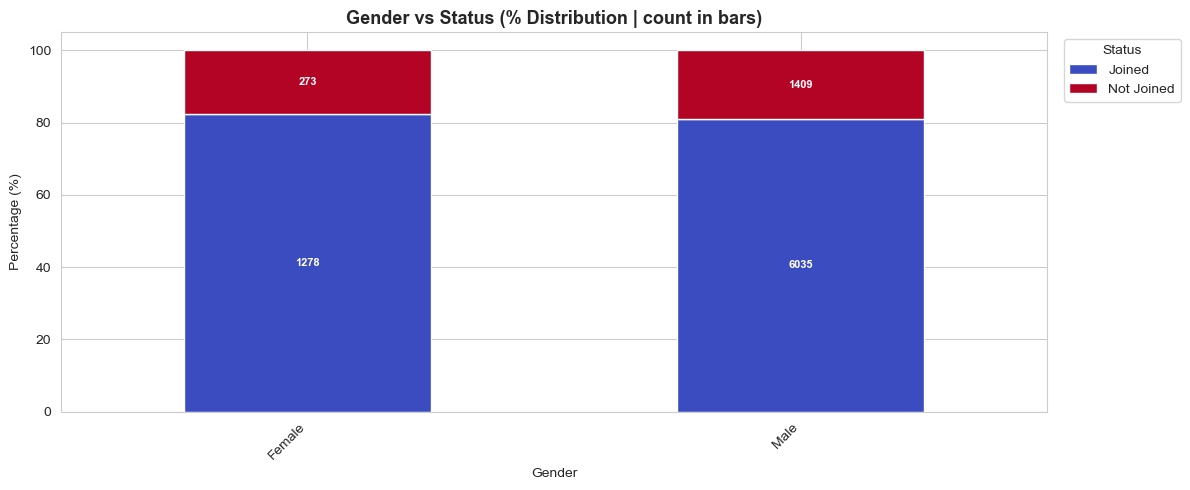

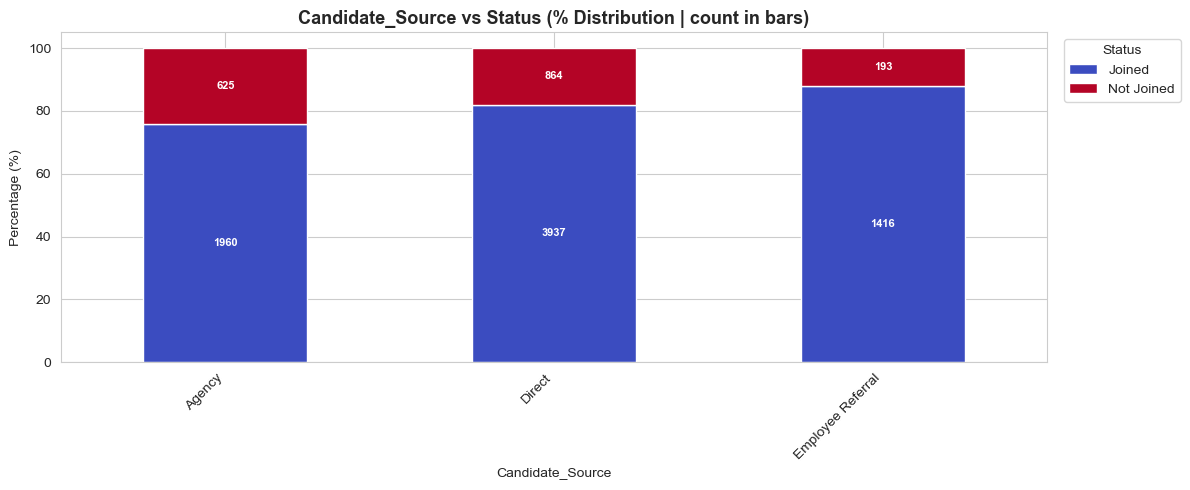

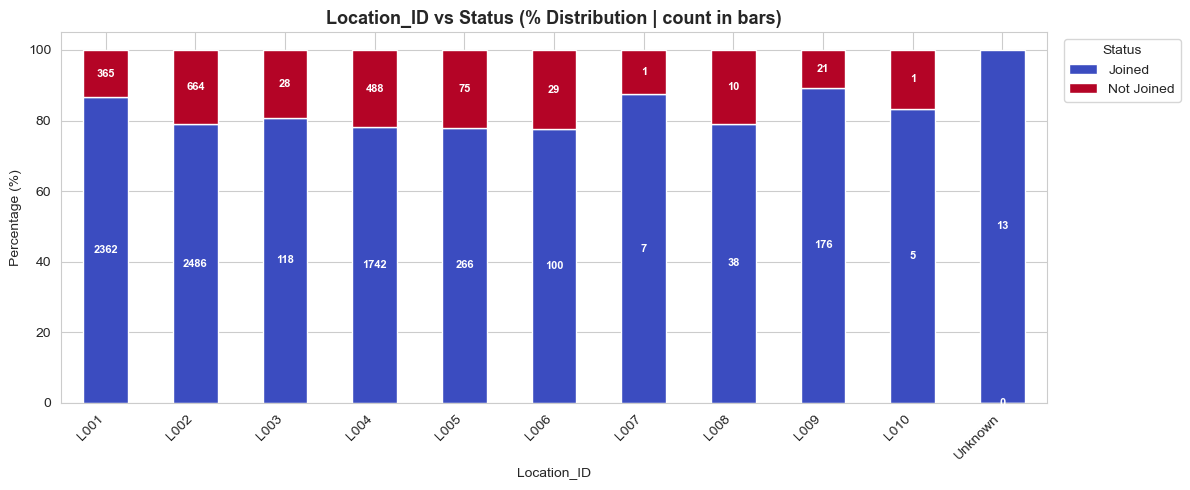

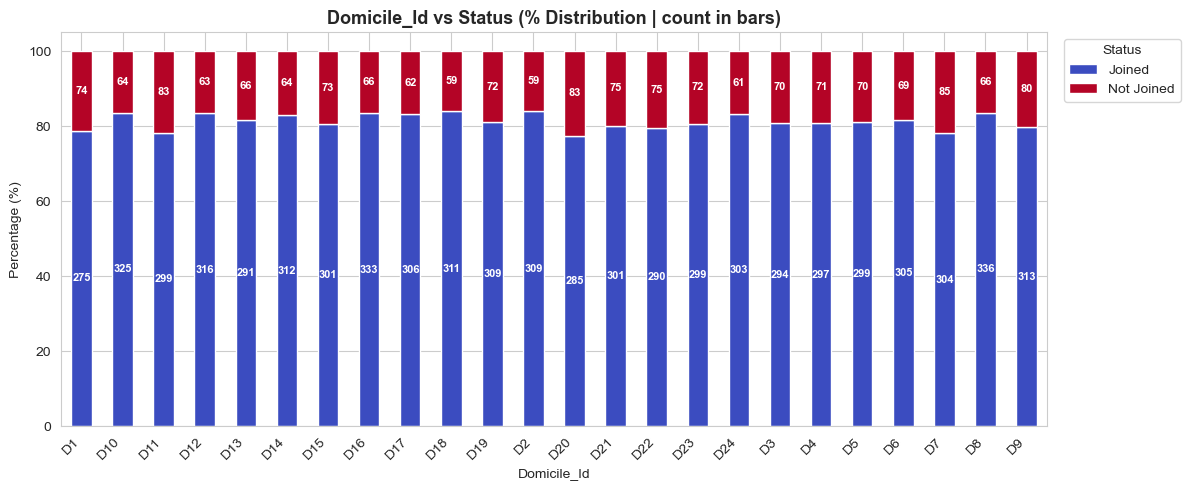

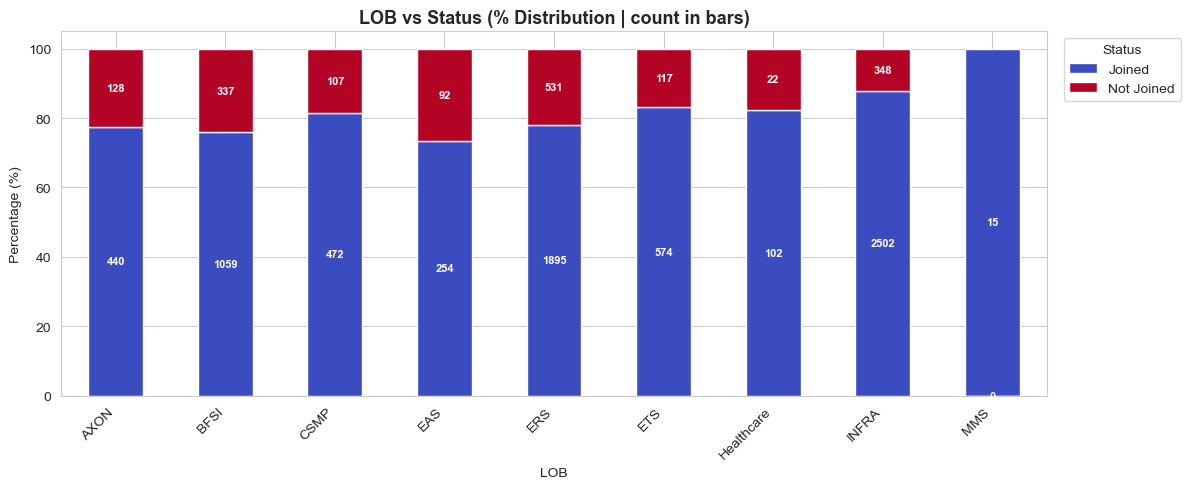

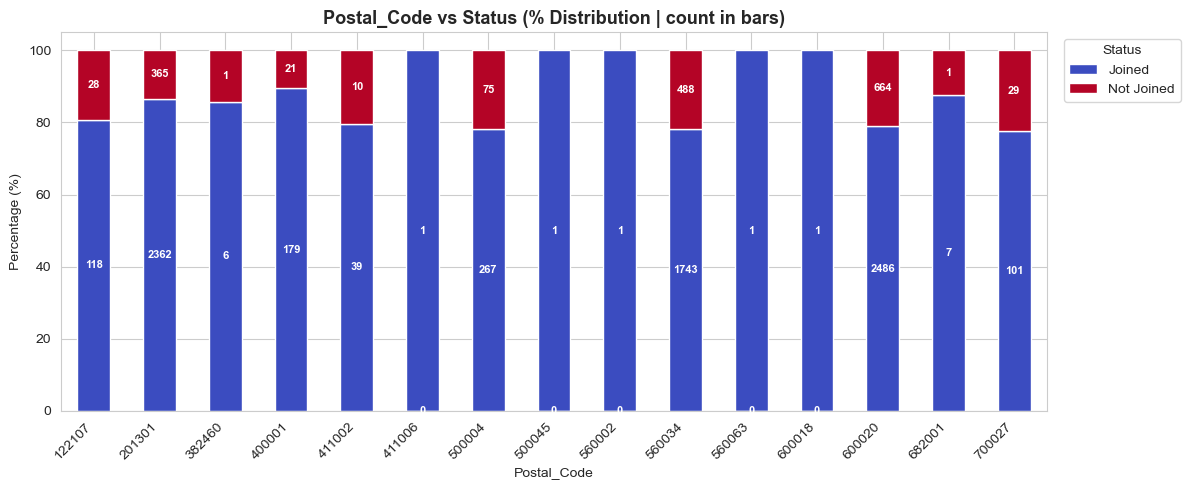

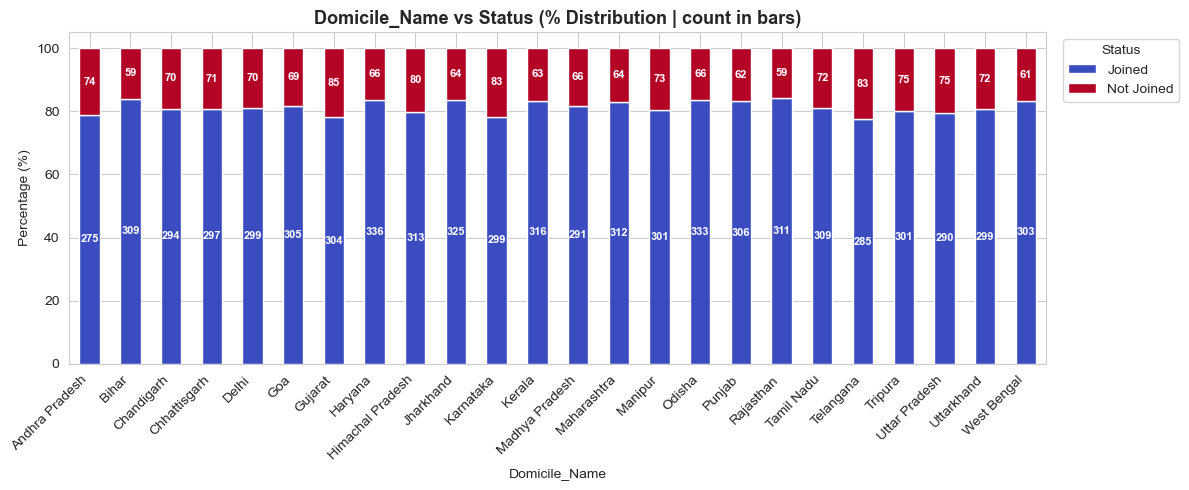

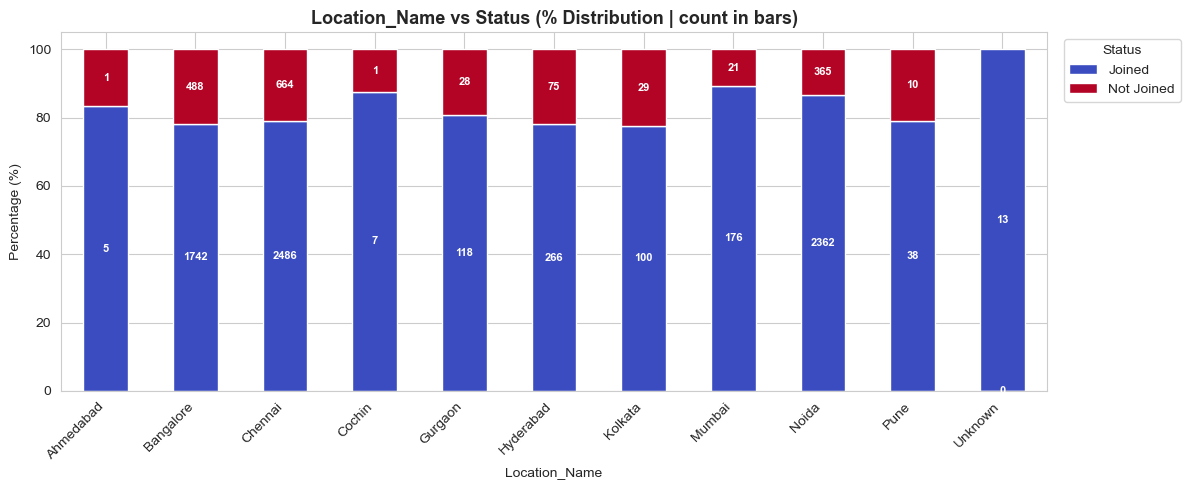

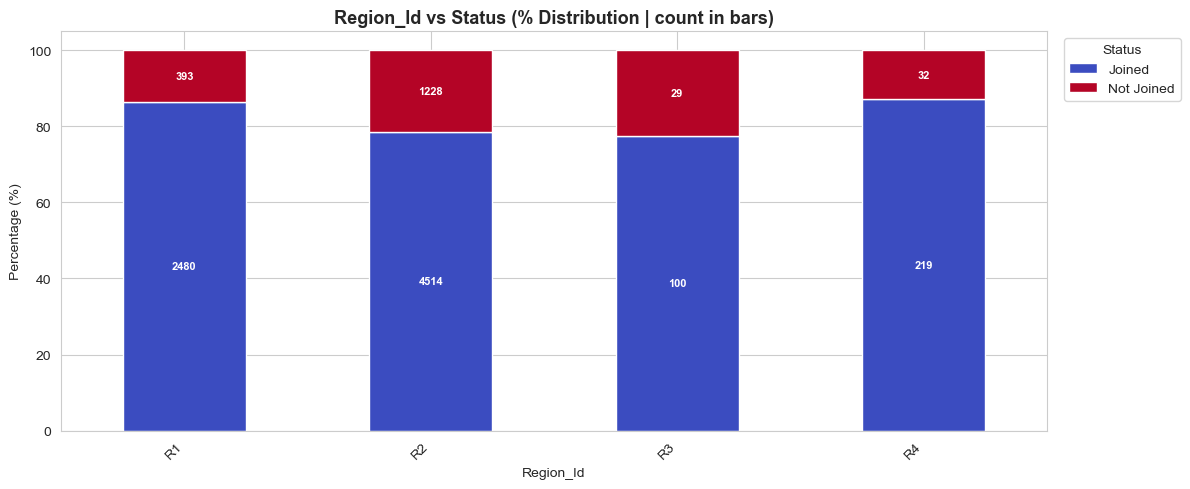

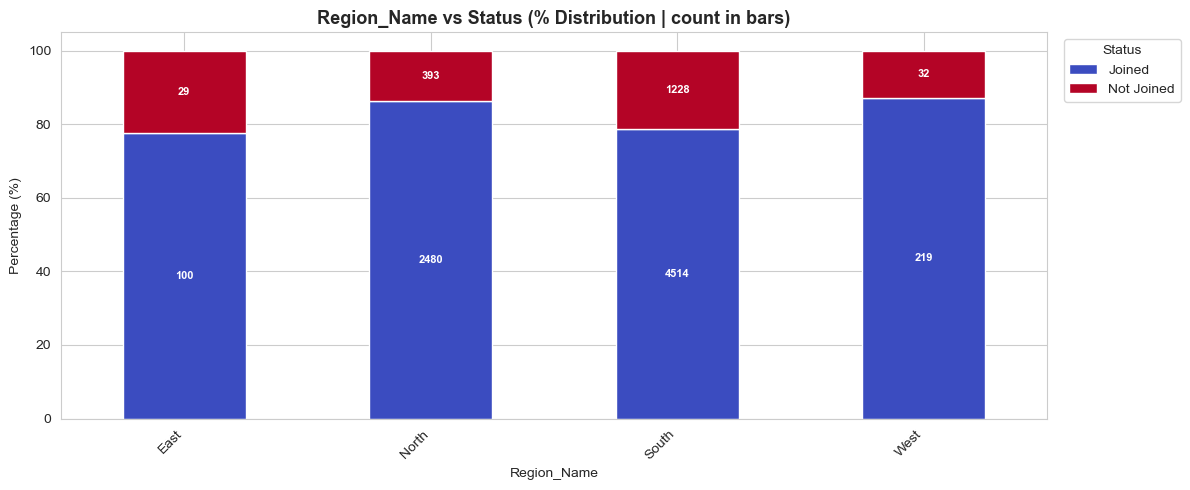

In [136]:
sns.set_style("whitegrid")
target = 'Status'

category_wo_status = [
    'DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual',
    'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'LOB','Postal_Code',
    'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name'
]

for col in category_wo_status:
    ct_count = pd.crosstab(data1[col], data1[target])
    ct_pct   = pd.crosstab(data1[col], data1[target], normalize='index') * 100

    ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12, 5),
                     colormap='coolwarm', edgecolor='white')

    # Count of labels inside each stacked segment 
    for bar_stack, status_col in zip(ax.containers, ct_count.columns):
        for bar, (idx, row) in zip(bar_stack, ct_count.iterrows()):
            count = row[status_col]
            x     = bar.get_x() + bar.get_width() / 2
            y     = bar.get_y() + bar.get_height() / 2  
                               
            ax.text(x, y, str(count), ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')

    plt.title(f'{col} vs {target} (% Distribution | count in bars)',
              fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title=target, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Insights from the Distribution Diagrams of Categorical Columns


1. *`DOJ_Extended`*

- No meaningful impact — joining rates are virtually identical whether DOJ was extended (81.55%) or not (81.08%), making this feature a near-zero signal for predicting Status



2. *`Offered_Band`*

- Higher band = higher joining rate — E3 leads at 85.26% while E0 lags at 76.30%, suggesting senior/better-compensated offers see less dropout
- E1 dominates volume (5578) but sits at an average 81.32% — the bulk of attrition risk lives here



3. *`Joining_Bonus`*

- Bonus has no effect — joining rates are nearly identical (81.34% No vs 80.58% Yes), meaning the bonus is not influencing candidates' final decision to join
- This feature can safely be deprioritized in any predictive model



4. *`Candidate_relocate_actual`*

- Relocation = guaranteed joining — 100% of the 1290 candidates who relocated actually joined, making this the strongest categorical signal in the entire dataset
- Non-relocators drop to 78.17%, confirming that physical relocation is the clearest commitment indicator



5. *`Gender`*

- Gender has negligible impact — Female (82.40%) and Male (81.07%) joining rates differ by barely 1.3 percentage points
- Not a useful predictor of Status, though gender diversity in sourcing remains a separate concern



7. *`Candidate_Source`*

- Employee Referrals are the highest quality source — 88% joining rate vs Agency's 75.82%, a 12-point gap that signals referrals bring more committed candidates
- Agency, being the costliest sourcing channel, also has the highest dropout — a clear ROI red flag



8. *`Location_ID`*

- Mumbai (L009: 89.34%) and Noida (L001: 86.62%) are the strongest joining locations — Kolkata (L006: 77.52%) and Hyderabad (L005: 78.01%) show the most dropout risk
- Top 3 locations drive 90% of volume, so their rates effectively define overall business performance



9. *`Domicile_Id / Domicile_Name`*

- Extremely narrow range — joining rates across all 24 states span only 77.45% (Telangana) to 84.05% (Rajasthan), a ~7-point band with no dramatic outliers
- Domicile is a weak predictor of Status; candidate's home state has little bearing on joining behavior



10. *`LOB`*

- INFRA is the standout performer at 87.79% joining rate while EAS (73.41%) and BFSI (75.86%) are the weakest — a 14-point spread making LOB one of the most discriminating features
- BFSI's high volume (1396) combined with a low joining rate makes it the single largest contributor to absolute dropout numbers



11. *`Location_Name`*

- Mumbai (89.34%) and Noida (86.62%) lead; Kolkata (77.52%) and Bangalore (78.12%) lag — despite Bangalore being the 3rd largest hub, it underperforms on joining rate
- Chennai, the highest volume city, sits at a below-average 78.92% — a high-priority location for dropout intervention



12. *`Region_Name`*

- North (86.32%) and West (87.25%) significantly outperform South (78.61%) and East (77.52%) — an ~9-point North-South gap is a major finding given South contributes 64% of all volume
- Most dropout risk is concentrated in the South region purely by scale — fixing South joining rates would move the overall needle the most

# Visual Representation of Numerical Columns vs Target (Status)

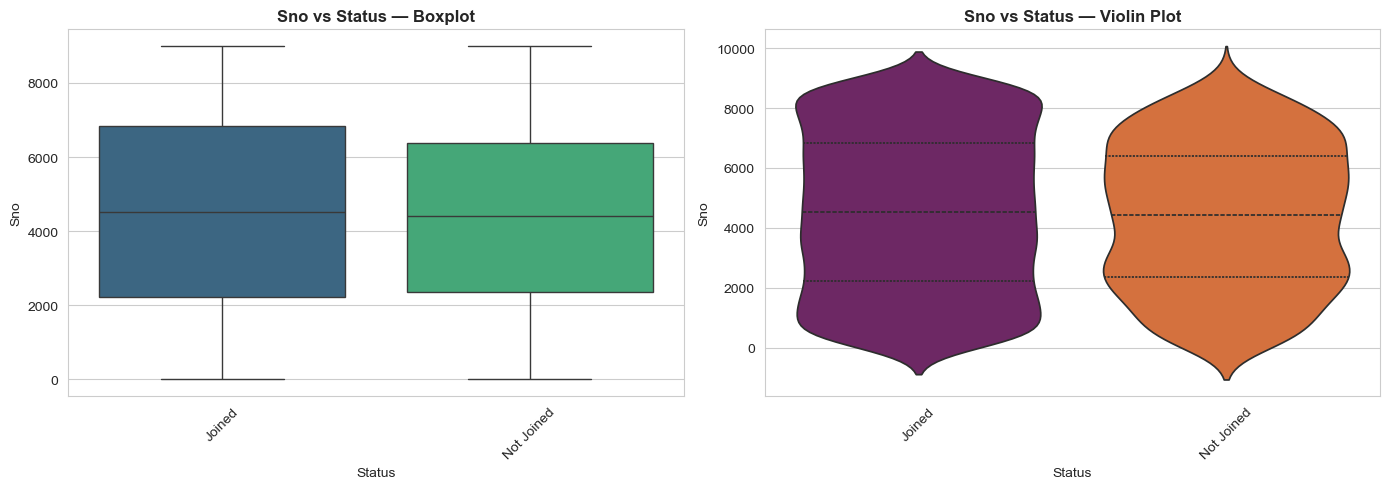

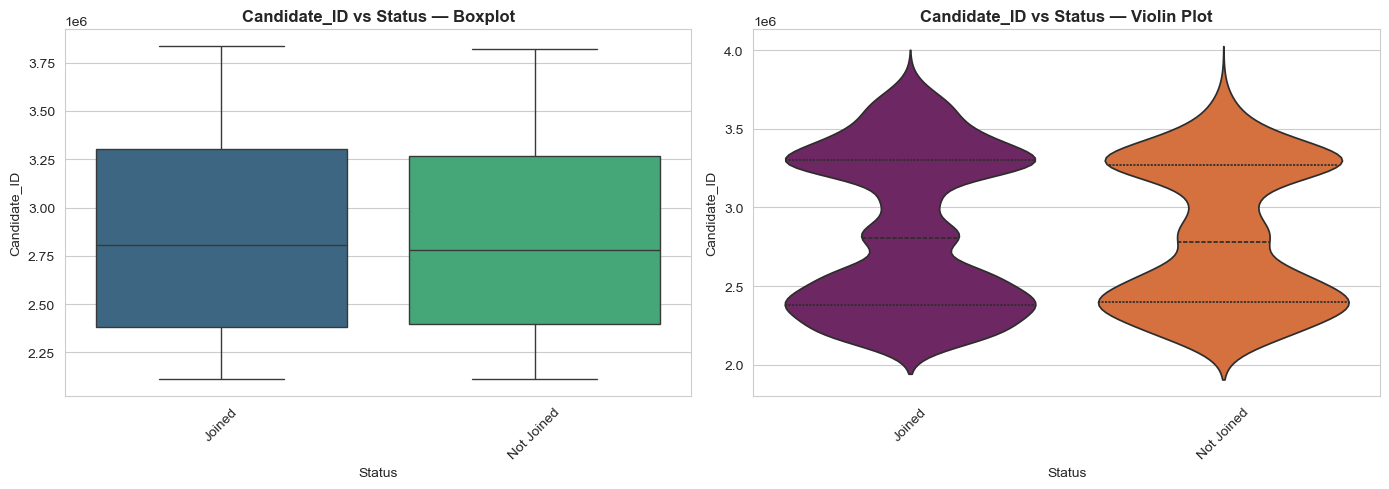

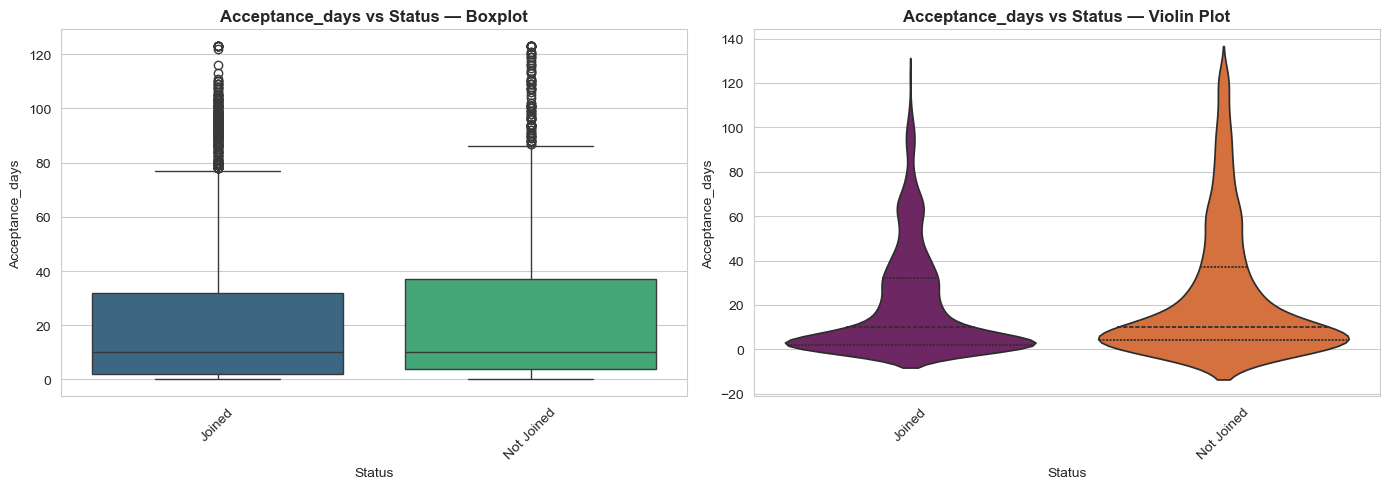

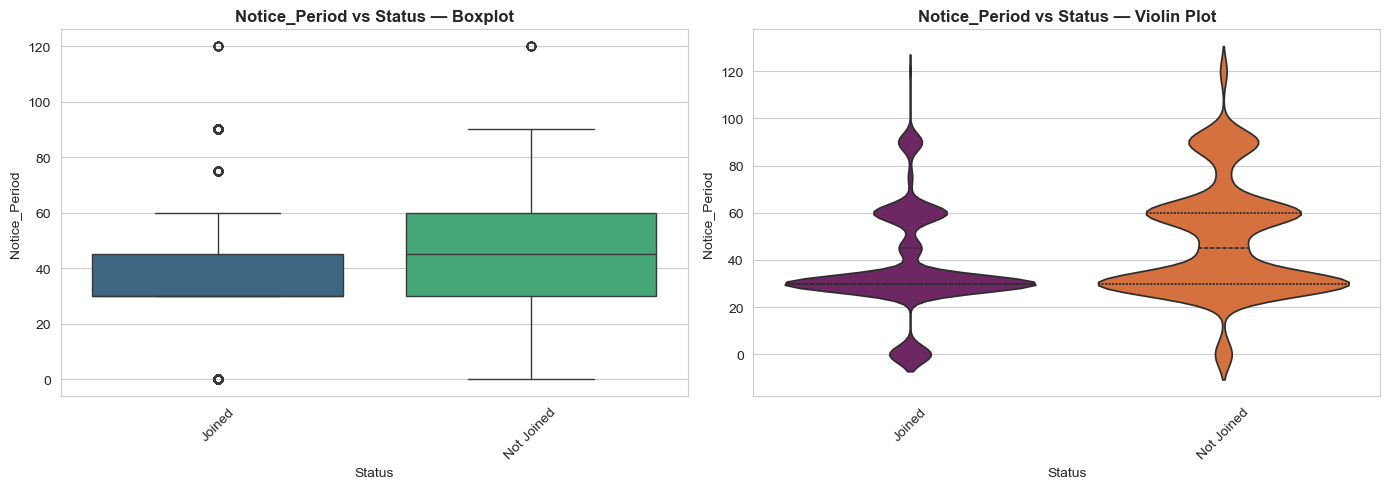

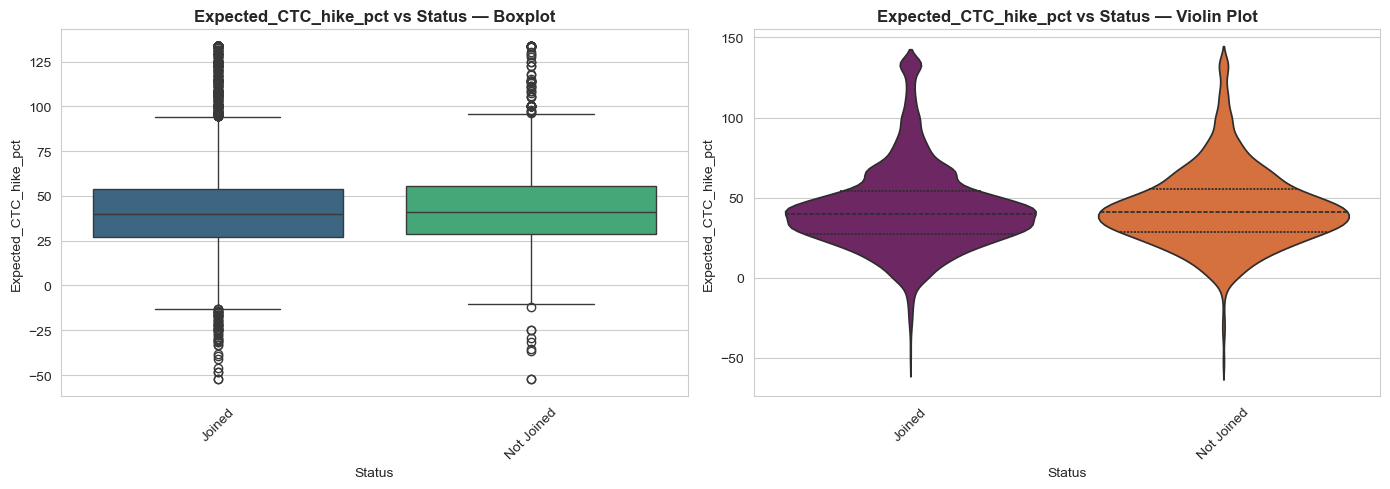

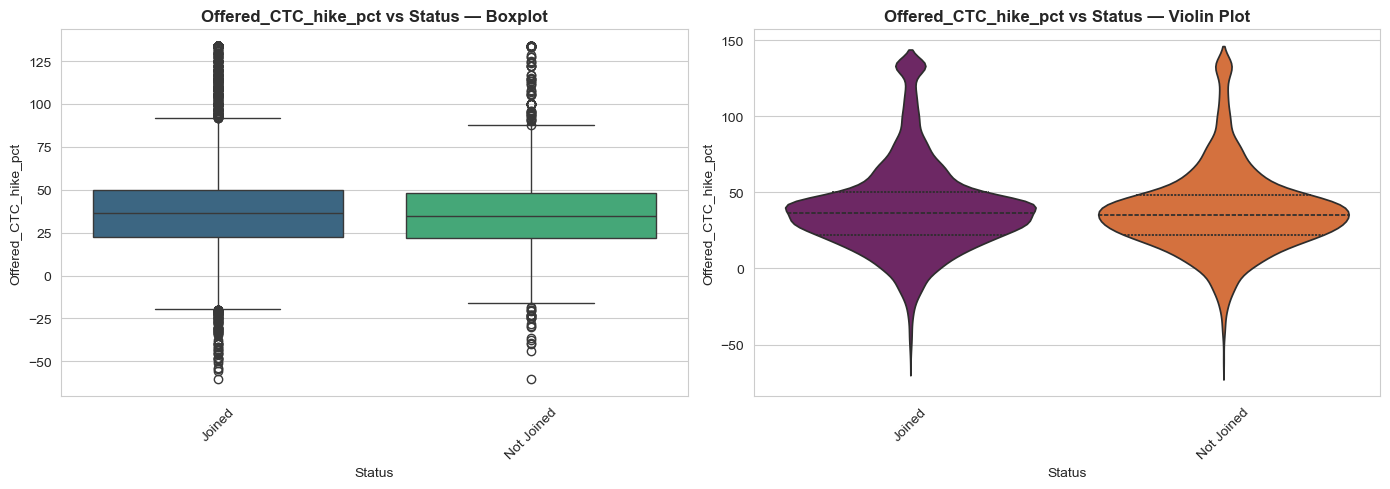

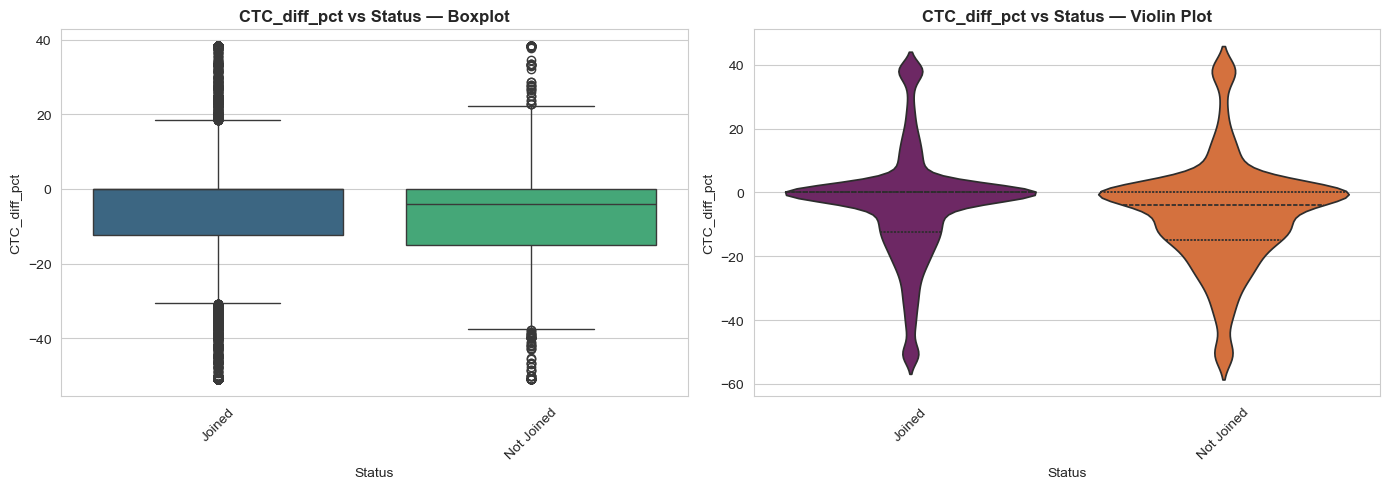

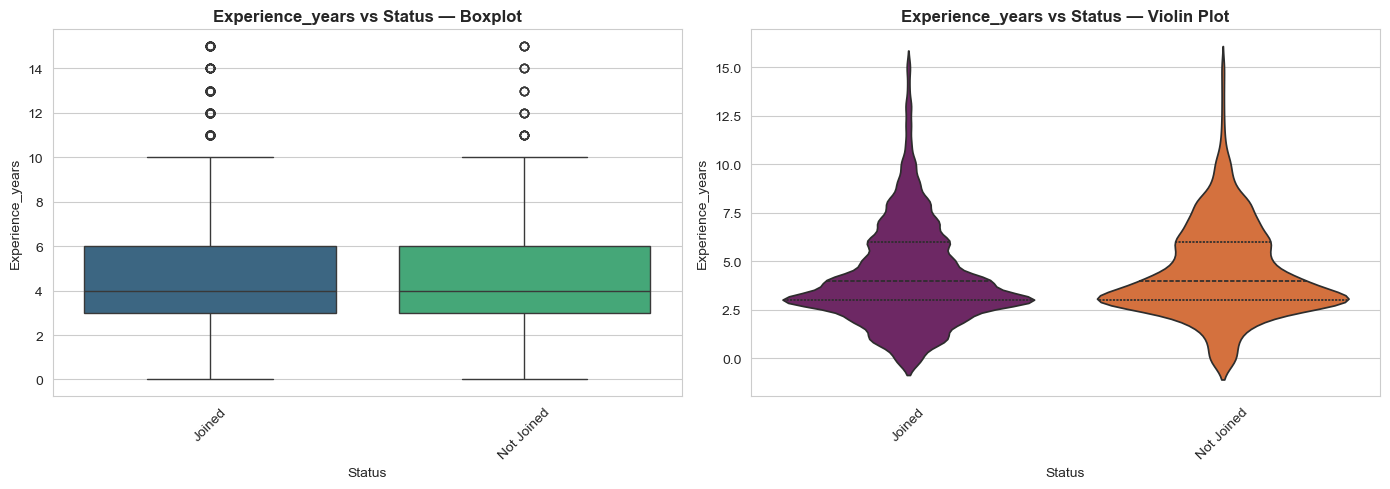

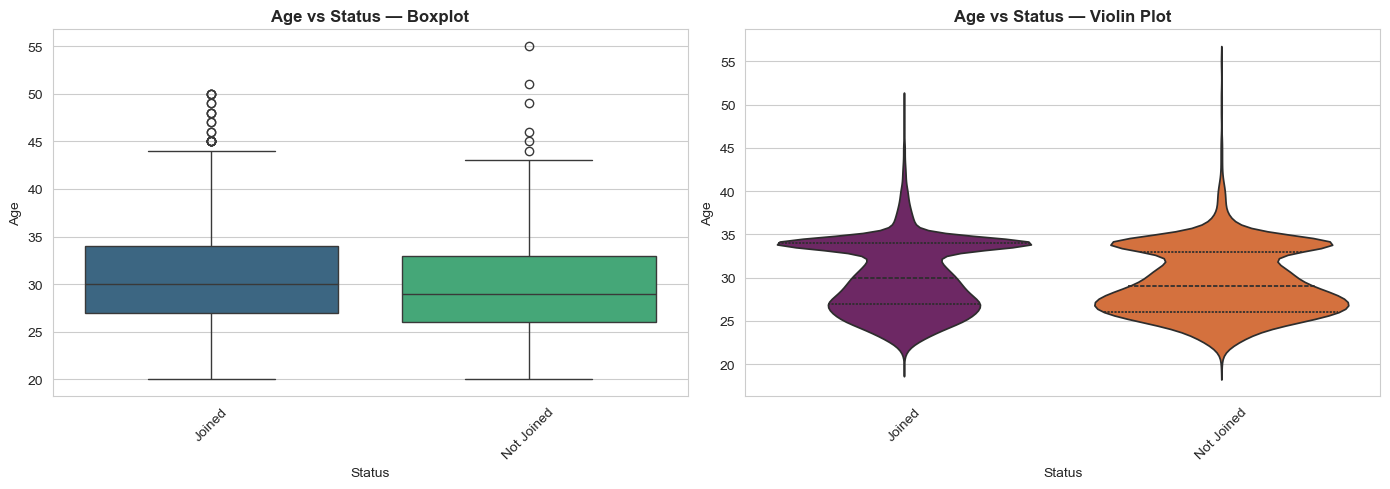

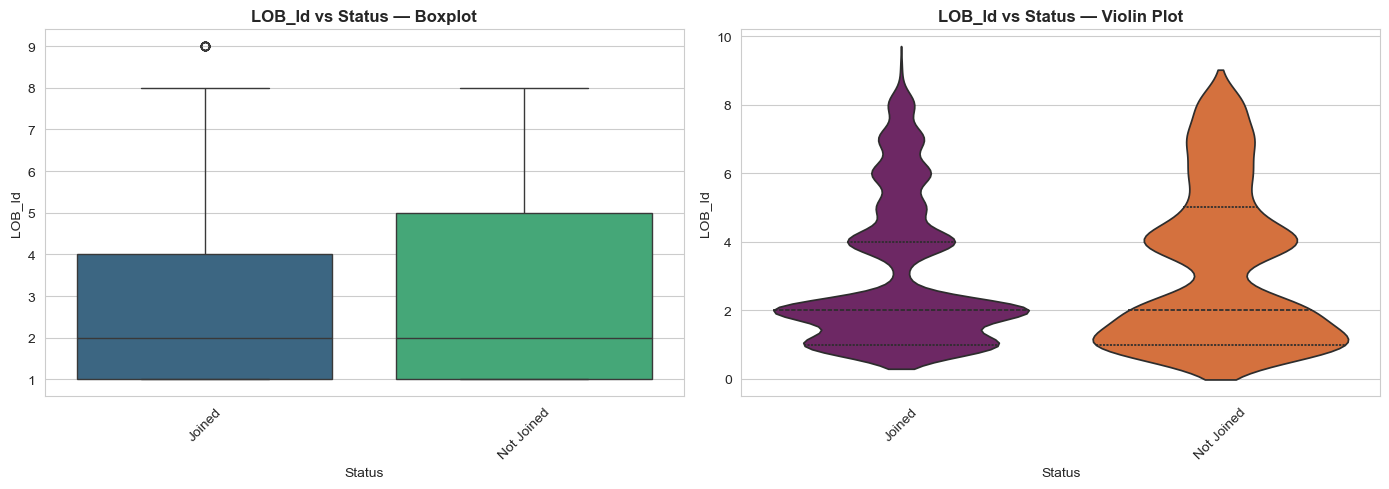

In [137]:
sns.set_style("whitegrid")

target = 'Status'

for col in numerical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=data1, x=target, y=col, ax=axes[0], palette='viridis')
    
    axes[0].set_title(f'{col} vs {target} — Boxplot', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)

    sns.violinplot(data=data1, x=target, y=col, ax=axes[1], palette='inferno', inner='quartile')
    
    axes[1].set_title(f'{col} vs {target} — Violin Plot', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Insights from the Distribution Diagrams of Numerical Columns vs Target (Status)


1. *`Acceptance_days`*

- Not Joined candidates take longer to accept — mean of 24.76 days vs 20.62 for Joined, and Q3 is higher too (37 vs 32) — delay in acceptance is an early dropout signal
- Candidates who accept quickly are more likely to join.



2. *`Notice_Period`*

- Strongest numerical predictor of dropout — Not Joined mean is 48.19 days vs Joined's 37.24, with median 45 vs 30 — a full 15-day median gap
- Longer notice periods give candidates more time to receive counter-offers; high notice period = high dropout risk



3. *`Expected_CTC_hike_pct`*

- Near-identical distributions — Joined (43.06%) vs Not Joined (43.47%) — expected hike has zero discriminating power on joining outcome
- Both groups want similar hikes; the difference lies in what they were offered, not what they expected



4. *`Offered_CTC_hike_pct`*

- Marginal difference — Joined candidates received slightly higher offered hike (39.63%) vs Not Joined (37.67%), but the gap is small
- Not a strong standalone predictor, but combined with CTC_diff_pct it tells a richer story



5. *`CTC_diff_pct`*

- `Key financial signal` — Not Joined candidates have a larger negative gap vs Joined, meaning they were offered further below their expectation
- Candidates offered exactly at or above expectation almost always join



6. *`Experience_years`*

- Virtually no difference  — experience level does not predict joining behavior
- Can be deprioritized as a standalone feature; may have weak interaction effects with band or CTC



7. *`Age`*

- Negligible difference — Joined mean 30.00 vs Not Joined 29.51, almost identical distributions with same min/max range
- Age is not a predictor of Status in this dataset; drop from any predictive model

 <a id="correlation-heatmap"></a>

<h2 style="color: green; font-weight: 800;">Numerical Columns Importance : Correlation Heatmap</h2>

In [138]:
numerical_columns = list(data1.select_dtypes(include = 'number').columns)

print(numerical_columns)

['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Age', 'LOB_Id']


### Correlation between Numerical Features (without Target Feature)

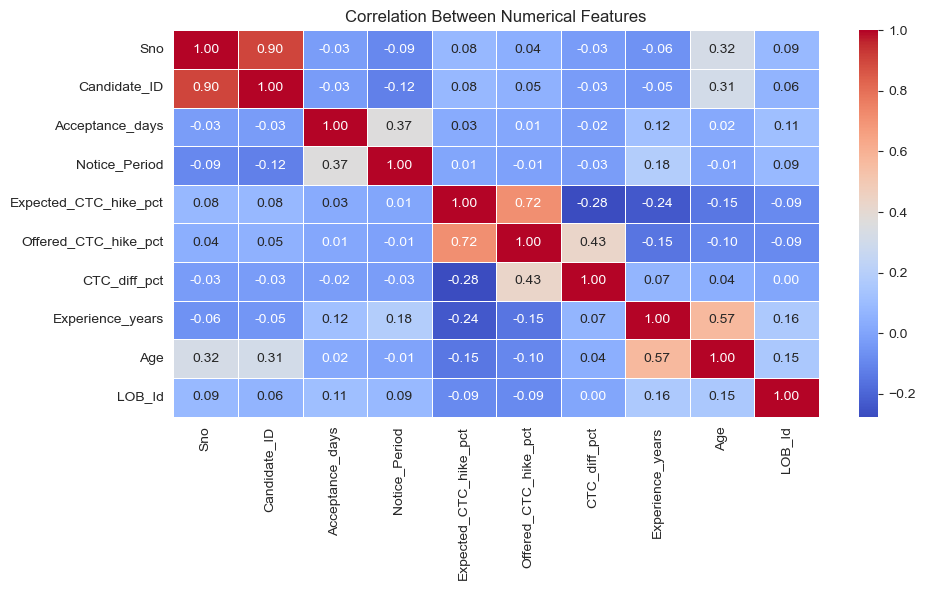

In [139]:
corr_matrix = data1[numerical_columns].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Between Numerical Features')
plt.tight_layout()
plt.show()

### Correlation between Numerical columns with Status Column (Target feature)

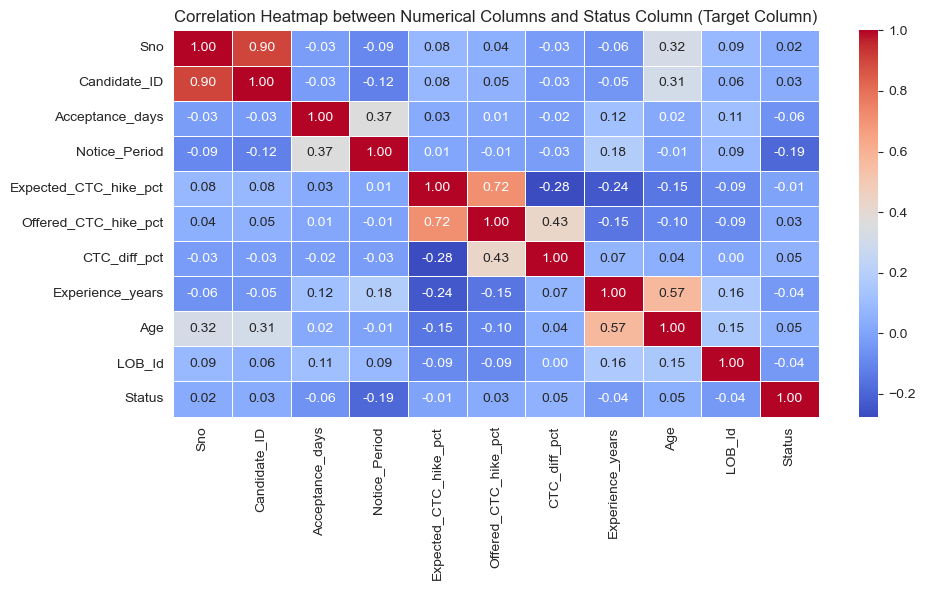

In [140]:
corr_df = data1[numerical_columns].copy(deep=True)
corr_df['Status'] = data1['Status'].map({'Joined': 1, 'Not Joined': 0})

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap between Numerical Columns and Status Column (Target Column)')
plt.tight_layout()
plt.show()

## Target Variable (Status) Analysis

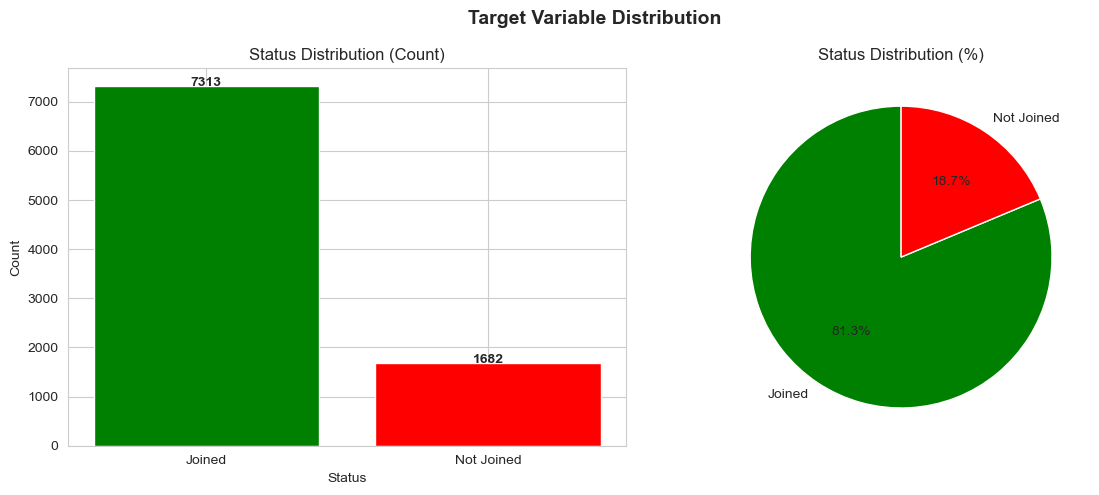

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# count plot
status_counts = data1['Status'].value_counts()

axes[0].bar(status_counts.index, status_counts.values, color=['green', 'red'])

axes[0].set_title('Status Distribution (Count)')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')

for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['green', 'red'], startangle=90)

axes[1].set_title('Status Distribution (%)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Status column is imbalanced, have to do sampling before model training.

# Pair Ploting

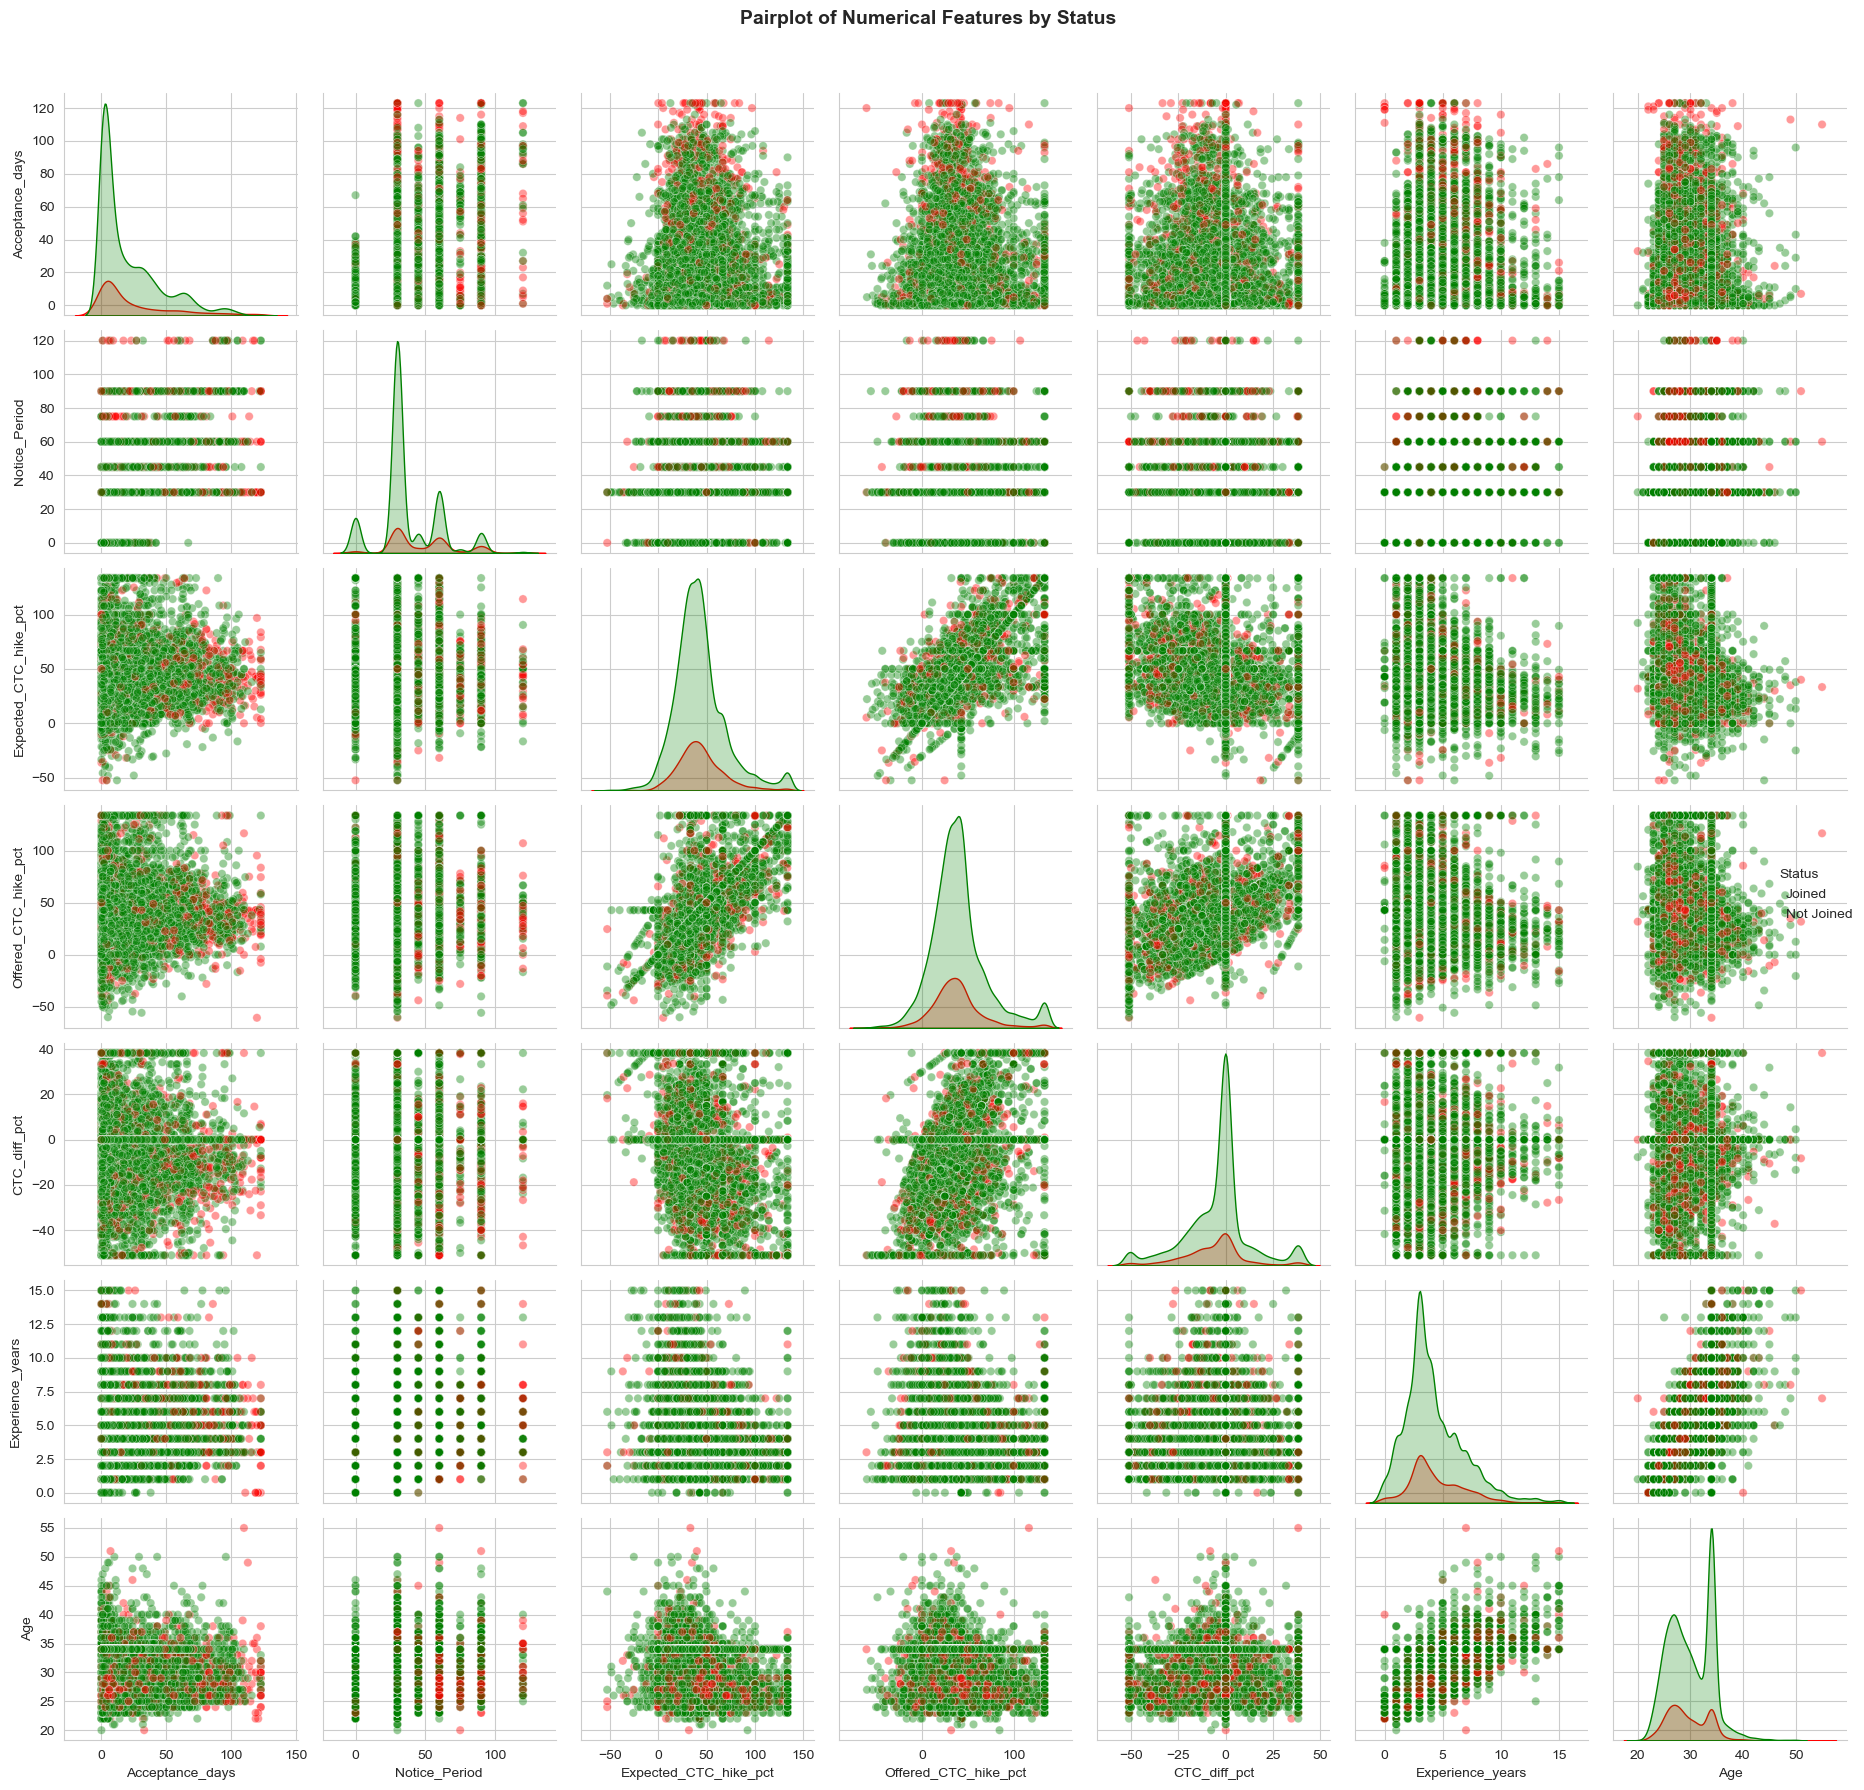

In [142]:
pairplot_cols = ['Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct',
                 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Age', 'Status']

sns.pairplot(data1[pairplot_cols], hue='Status',
             palette={'Joined': 'green', 'Not Joined': 'red'},
             diag_kind='kde', plot_kws={'alpha': 0.4})

plt.suptitle('Pairplot of Numerical Features by Status', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Temporal Analysis

In [143]:
data2 = data1.copy(deep=True)

data2['Offer_Month'] = data2['Date_of_Interview'].dt.month
data2['Offer_Year']  = data2['Date_of_Interview'].dt.year
data2['Offer_Quarter'] = data2['Date_of_Interview'].dt.quarter

print(data2[['Offer_Month', 'Offer_Year', 'Offer_Quarter', 'Status']].head())

   Offer_Month  Offer_Year  Offer_Quarter  Status
0            1        2013              1  Joined
1            1        2013              1  Joined
2            1        2013              1  Joined
3            1        2013              1  Joined
4            1        2013              1  Joined


In [144]:
grouped = pd.crosstab([data2['Offer_Year'], data2['Offer_Month']], data2['Status'])

grouped

Status                  Joined  Not Joined
Offer_Year Offer_Month                    
2013       1               488          94
           2               390          99
           3               502          92
           4               525         108
           5               585         111
           6               408          84
           7               460          94
           8               435          82
           9               456         142
           10              454         137
           11              552         138
           12              490         122
2014       1               703         185
           2               272          81
           3                52           6
           4               127          20
           5               122          28
           6               118          26
           7               171          30
           8                 3           3

In [145]:
data2['Offer_Quarter'].unique()

array([1, 2, 3, 4], dtype=int32)

In [146]:
data2['Offer_Year'].value_counts()

Offer_Year
2013    7048
2014    1947
Name: count, dtype: int64

### Year wise Joining Trend

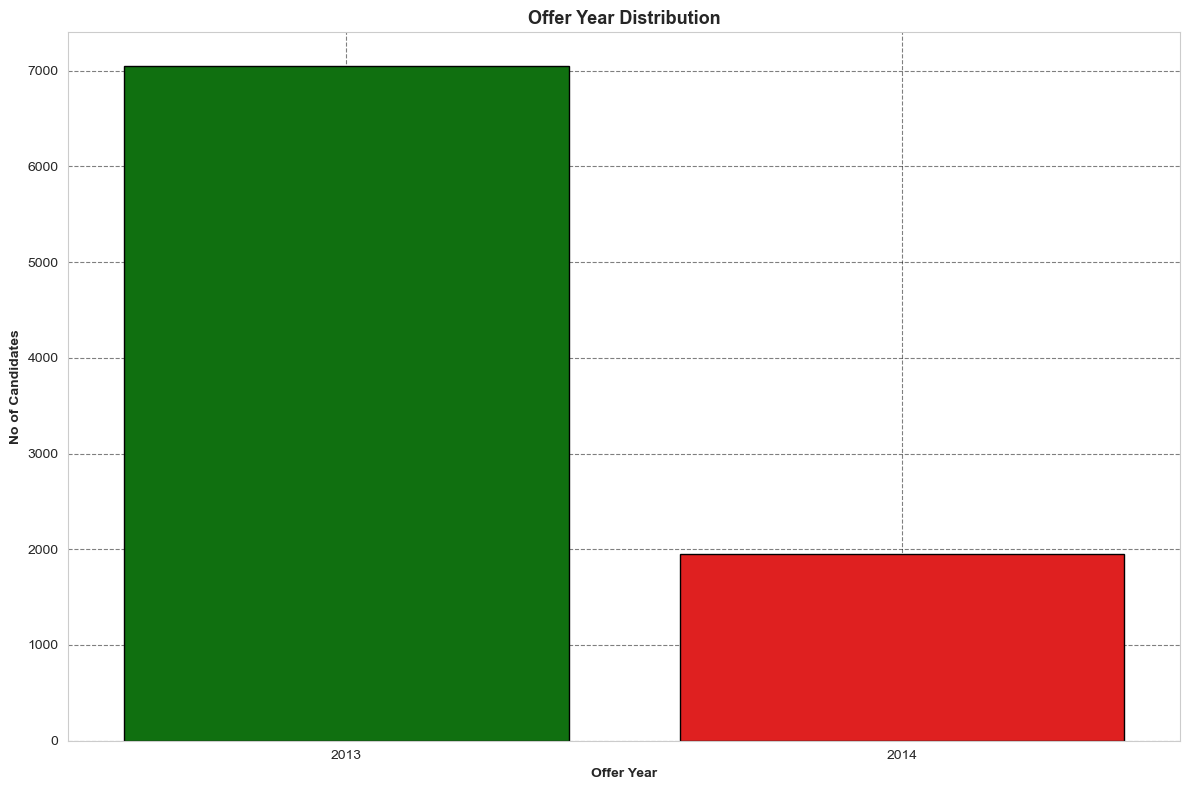

In [147]:
plt.figure(figsize=(12, 8))

year_val_counts = data2['Offer_Year'].value_counts()

sns.barplot(x=year_val_counts.index, y=year_val_counts.values,
            palette=['green', 'red'], edgecolor='black') 

plt.title('Offer Year Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Offer Year', fontsize=10, fontweight='bold')
plt.ylabel('No of Candidates', fontsize=10, fontweight='bold')

plt.grid(linestyle="--", color='black', alpha=0.5)
plt.tight_layout()
plt.show()

### Joining Trend in months of each year.

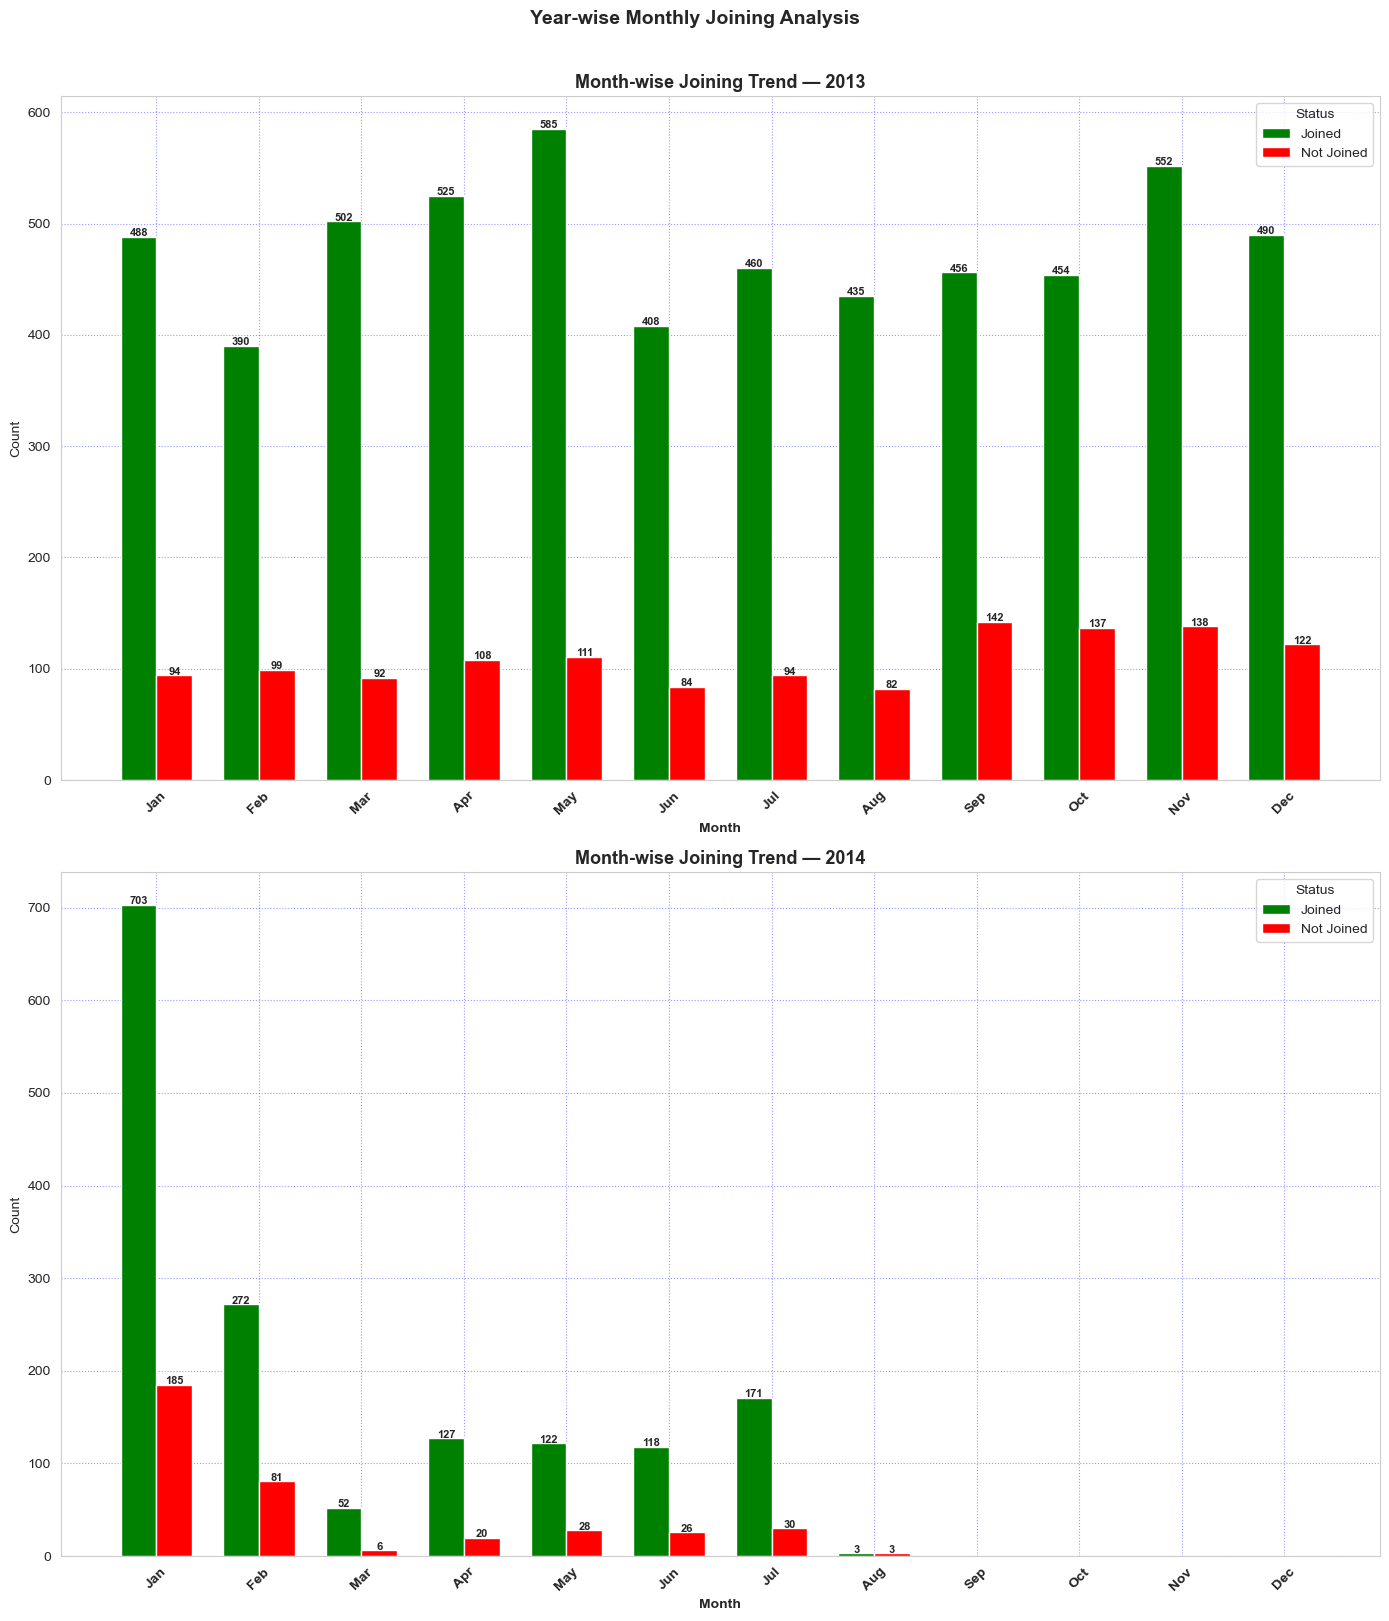

In [148]:
grouped = pd.crosstab([data2['Offer_Year'], data2['Offer_Month']], data2['Status'])

years = grouped.index.get_level_values('Offer_Year').unique()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(len(years), 1, figsize=(14, 8 * len(years)))

if len(years) == 1:
    axes = [axes]

for ax, year in zip(axes, years):
    year_data = grouped.xs(year, level='Offer_Year').reindex(range(1, 13), fill_value=0)

    x     = range(len(year_data))
    width = 0.35

    ax.bar([i - width/2 for i in x],
           year_data.get('Joined', 0),
           width=width, label='Joined', color='green', edgecolor='white')

    ax.bar([i + width/2 for i in x],
           year_data.get('Not Joined', 0),
           width=width, label='Not Joined', color='red', edgecolor='white')

    ax.set_title(f'Month-wise Joining Trend — {int(year)}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month', fontweight="bold")
    ax.set_ylabel('Count')
    ax.set_xticks(list(x))
    ax.set_xticklabels(month_labels, rotation=45, fontweight="bold")
    ax.legend(title='Status')

    ax.grid(linestyle=":", color="blue", alpha=0.4)
    ax.set_axisbelow(True)   

    # annotate counts on top of bars
    for i, (nj, j) in enumerate(zip(year_data.get('Not Joined', [0]*12),
                                     year_data.get('Joined',     [0]*12))):
        if nj > 0: ax.text(i + width/2, nj + 0.5, str(int(nj)), ha='center', fontsize=8, fontweight='bold')
        if j  > 0: ax.text(i - width/2, j  + 0.5, str(int(j)),  ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Year-wise Monthly Joining Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Correlation between Year, Month, Quarter and Status (Target Column)

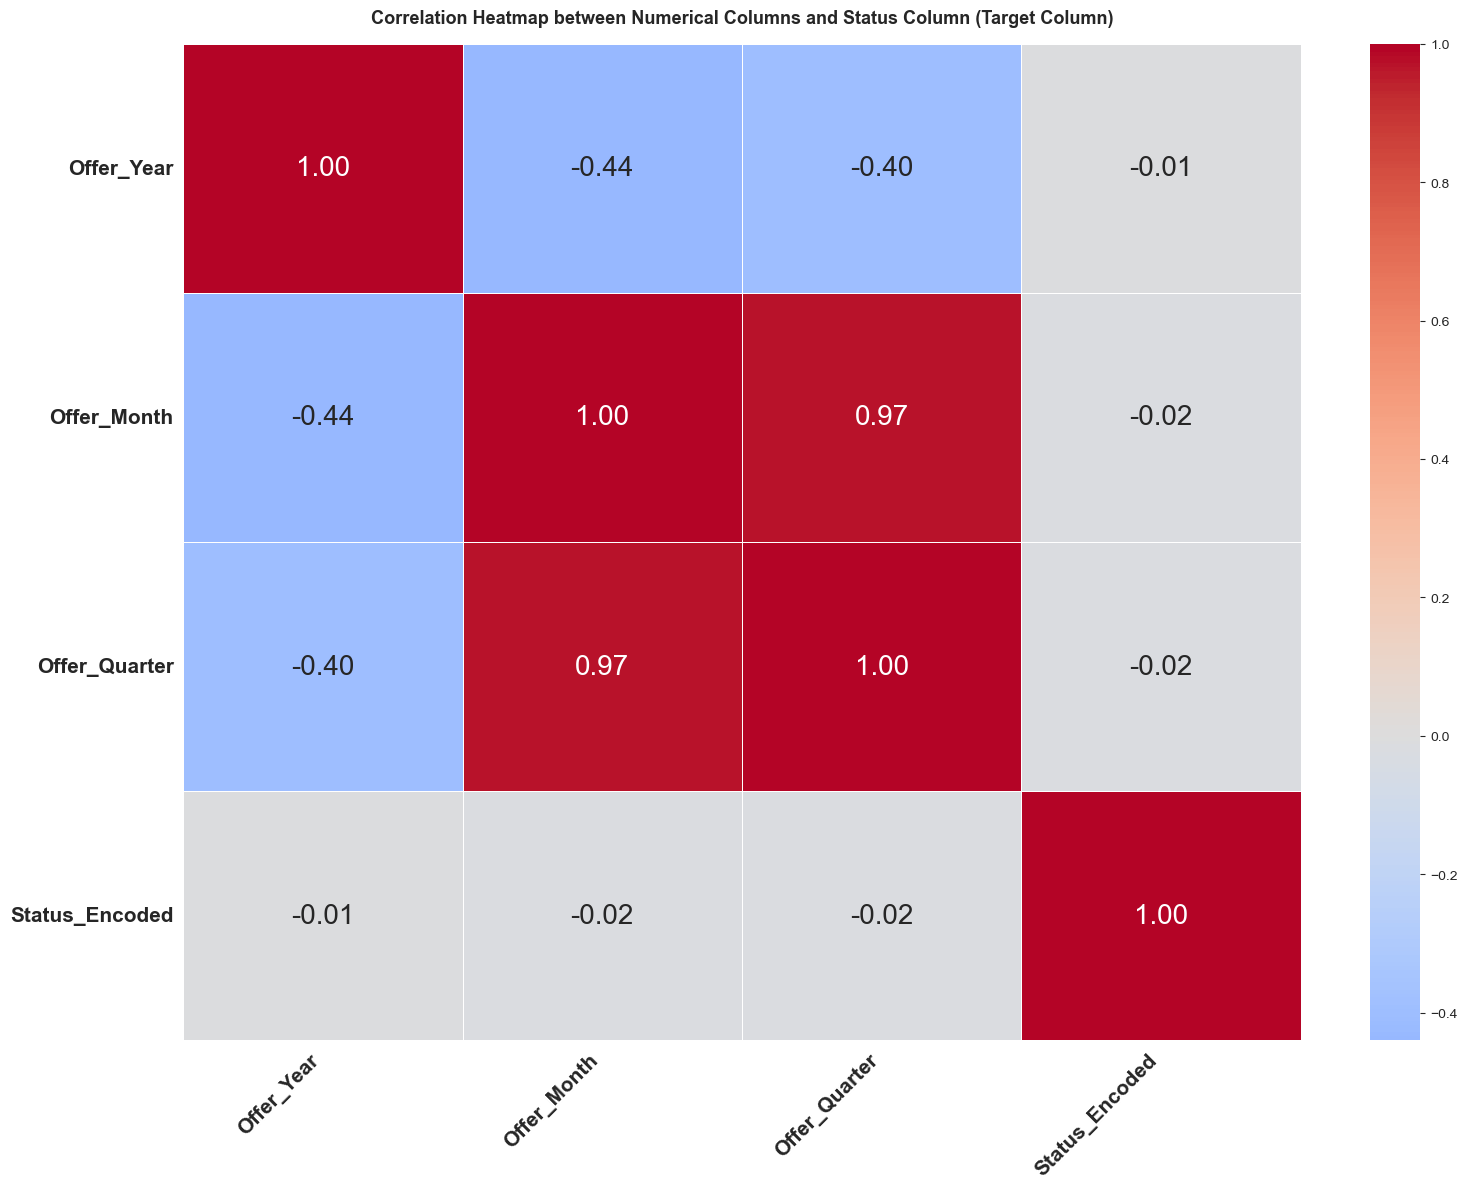

In [149]:
data2['Status_Encoded'] = data2['Status'].map({'Joined': 1, 'Not Joined': 0})

corr_cols = ['Offer_Year', 'Offer_Month', 'Offer_Quarter', 'Status_Encoded']

corr_matrix = data2[corr_cols].corr().round(2)

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 20})

plt.title('Correlation Heatmap between Numerical Columns and Status Column (Target Column)',
          fontsize=13, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=15, fontweight="bold")
plt.yticks(rotation=0, fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### Correlation between Year, Month and Quarter and Status is very low.
- *Option 1* : We Can Drop `Date_Of_Interview` Column in Feature Engineering.
- *Option 2* : We can Keep Year, Month, Quarter separate columns, as many features has similar kind of Smaller Correlation with Status. (We will remove it if it will severely increase `Curse of Dimensionality`)

In [150]:
data1

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.950,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2,2112635,No,18,30,E2,50.00,133.73,38.265,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.000,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.000,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.000,No,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,133.59,133.73,0.000,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,8992,3828206,Yes,2,0,E1,133.59,133.73,0.000,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.000,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.070,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


In [151]:
data1.to_csv("(Upto_EDA)HR_HIRING_ANALYTICS.csv", index=False)

print("(Upto_EDA)HR_HIRING_ANALYTICS.csv - saved successfully!")

(Upto_EDA)HR_HIRING_ANALYTICS.csv - saved successfully!


#### EDA Done. Ready for Feature Engineering.

 <a id="feature-engineering"></a>

<h2 style="color: green; font-weight: 800;">Feature Engineering</h2>

In [152]:
data3 = pd.read_csv("(Upto_EDA)HR_HIRING_ANALYTICS.csv")

dataFE = data3.copy(deep=True)

dataFE

# FE => Feature Engineering

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.950,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2,2112635,No,18,30,E2,50.00,133.73,38.265,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.000,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.000,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.000,No,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,133.59,133.73,0.000,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,8992,3828206,Yes,2,0,E1,133.59,133.73,0.000,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.000,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.070,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


In [153]:
numerical_cols1 = list(dataFE.select_dtypes(include="number").columns)

print(f"Numerical Columns = {numerical_cols1}")

categorical_cols1 = list(dataFE.select_dtypes(include='object').columns)

print(f"\n\nCategorical Columns = {categorical_cols1}")

Numerical Columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


Categorical Columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name', 'Status']


In [154]:
type(dataFE['Postal_Code'][0])

numpy.int64

In [155]:
type(data1['Postal_Code'][0])

str

In [156]:
print(dataFE['Date_of_Interview'].dtypes)

object


In [157]:
print(data1['Date_of_Interview'].dtype)

datetime64[ns]


### Here one thing to notice :
- The data types of Date_of_Interview and Postal_Code is not same as we have changed in data1,
its chaned to normal base as first dataset.
- When you save a DataFrame to .csv, it saves only raw text values — no metadata about whether a column is datetime, category, object, or int.

In [158]:
dfFE = data1.copy(deep=True)

# Using the data1 so that all changed will be there.

In [159]:
dfFE

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.950,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2,2112635,No,18,30,E2,50.00,133.73,38.265,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.000,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.000,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.000,No,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,133.59,133.73,0.000,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,8992,3828206,Yes,2,0,E1,133.59,133.73,0.000,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.000,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.070,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


In [160]:
print(f"Data Type of Date_of_Interview = {dfFE['Date_of_Interview'].dtype}")
print(f"Data Type of Postal_Code = {dfFE['Postal_Code'].dtype}")

Data Type of Date_of_Interview = datetime64[ns]
Data Type of Postal_Code = object


### `Steps of Feature Engineering` : 
1. Drop Unnecessary Columns.
2. Target Encoding
3. Binary Encoding
4. Ordinal Encoding
5. One-Hot Encoding (OHE)
6. Feature Creation (New Derived Features)
7. Scaling / Normalization
8. Handle Class Imbalance (SMOTE)
9. Final Dataset Prep for ML

 <a id="drop-columns"></a>

<h2 style="color: green; font-weight: 800;">Drop Unnecessary Columns</h2>

#### Columns to drop : 
1. Sno -> Just normal Index, no work with ML.
2. Candidate_ID -> Unique identifier (Primary Key) per candidate — no pattern useful for ML.
3. Location_ID -> Location_Name is there, it will be easy to identify Location Name after encoding rather than Location_ID.
4. Region_Id -> Region_Name is there, it will be easy to identify Region Name after encoding rather than Region_Id.
5. Domicile_Id -> Domicile_Name is there, it will be easy to identify Domicile Name after encoding rather than Domicile_Id.
6. LOB_Id -> LOB is there, it will be easy to identify Line Of Business Name after encoding rather than LOB_Id.
7. Date_of_Interview -> This column is not contributing high enough.

In [161]:
print(f"Columns : {(list(dfFE.columns))}")

Columns : ['Sno', 'Candidate_ID', 'DOJ_Extended', 'Acceptance_days', 'Notice_Period', 'Offered_Band', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Experience_years', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id', 'Date_of_Interview', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Id', 'Region_Name', 'Status']


#### Dropping : `Sno`

In [162]:
dfFE.drop('Sno', axis=1, inplace=True)

dfFE

,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,2110407,Yes,14,30,E2,-20.79,13.16,33.950,No,No,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,2112635,No,18,30,E2,50.00,133.73,38.265,No,No,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,2112838,No,3,45,E2,42.84,42.84,0.000,No,No,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,2115021,No,26,30,E2,42.84,42.84,0.000,No,No,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,2115125,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,3822427,No,4,0,E1,133.59,133.73,0.000,No,No,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,3828206,Yes,2,0,E1,133.59,133.73,0.000,No,No,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,3834159,No,0,0,E2,35.42,35.42,0.000,No,No,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,3835433,No,0,30,E1,76.92,53.85,-23.070,No,No,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


#### Dropping : `Candidate_ID`

In [163]:
dfFE.drop('Candidate_ID', axis=1, inplace=True)

In [164]:
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


#### There are 2 columns related to Location :
1. Location_ID
2. Location_Name
- Both are categorical columns and object data type, so one can be dropped.
- Dropping Location_ID because Location_Name contains names.
- And after encoding it will be easy to decode Location_Name from Encoded numbers. 

In [165]:
dfFE['Location_ID'].value_counts()

Location_ID
L002       3150
L001       2727
L004       2230
L005        341
L009        197
L003        146
L006        129
L008         48
Unknown      13
L007          8
L010          6
Name: count, dtype: int64

In [166]:
dfFE['Location_Name'].value_counts()

Location_Name
Chennai      3150
Noida        2727
Bangalore    2230
Hyderabad     341
Mumbai        197
Gurgaon       146
Kolkata       129
Pune           48
Unknown        13
Cochin          8
Ahmedabad       6
Name: count, dtype: int64

In [167]:
print(dfFE['Location_ID'].dtypes)

object


#### Dropping `Location_ID`

In [168]:
dfFE.drop('Location_ID', axis=1, inplace=True)
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Age,LOB_Id,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,...,34.0,1,D6,2013-01-08,ERS,Goa,Noida,R1,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,...,34.0,2,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,...,27.0,2,D10,2013-01-25,INFRA,Jharkhand,Noida,R1,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,...,34.0,2,D3,2013-01-27,INFRA,Chandigarh,Noida,R1,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,...,34.0,2,D21,2013-01-28,INFRA,Tripura,Noida,R1,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,...,34.0,1,D21,2013-08-19,ERS,Tripura,Chennai,R2,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,...,34.0,4,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,...,34.0,2,D18,2013-08-20,INFRA,Rajasthan,Noida,R1,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,...,34.0,2,D2,2013-08-20,INFRA,Bihar,Noida,R1,North,Joined


#### There are 2 columns related to LOB :
1. LOB
2. LOB_Id
- Both are categorical columns and object data type, so one can be dropped.
- Dropping LOB_Id because LOB contains names.
- And after encoding it will be easy to decode LOB from Encoded numbers. 

In [169]:
dfFE['LOB_Id'].value_counts()

LOB_Id
2    2850
1    2426
4    1396
6     691
5     579
7     568
8     346
3     124
9      15
Name: count, dtype: int64

In [170]:
dfFE['LOB'].value_counts()

LOB
INFRA         2850
ERS           2426
BFSI          1396
ETS            691
CSMP           579
AXON           568
EAS            346
Healthcare     124
MMS             15
Name: count, dtype: int64

In [171]:
dfFE.drop('LOB_Id', axis=1, inplace=True)

#### There are 2 columns related to Region :
1. Region_Id
2. Region_Name
- Both are categorical columns and object data type, so one can be dropped.
- Dropping Region_Id because Region_Name contains names.
- And after encoding it will be easy to decode Region Name from Encoded numbers. 

In [172]:
dfFE['Region_Id'].value_counts()

Region_Id
R2    5742
R1    2873
R4     251
R3     129
Name: count, dtype: int64

In [173]:
dfFE['Region_Name'].value_counts()

Region_Name
South    5742
North    2873
West      251
East      129
Name: count, dtype: int64

#### Dropping `Region_Id`

In [174]:
dfFE.drop('Region_Id', axis=1, inplace=True)

dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Experience_years,Postal_Code,Age,Domicile_Id,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,...,7,201301,34.0,D6,2013-01-08,ERS,Goa,Noida,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,...,8,600020,34.0,D9,2013-01-12,INFRA,Himachal Pradesh,Chennai,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,...,4,201301,27.0,D10,2013-01-25,INFRA,Jharkhand,Noida,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,...,4,201301,34.0,D3,2013-01-27,INFRA,Chandigarh,Noida,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,...,6,201301,34.0,D21,2013-01-28,INFRA,Tripura,Noida,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,...,1,600020,34.0,D21,2013-08-19,ERS,Tripura,Chennai,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,...,3,600020,34.0,D9,2013-08-20,BFSI,Himachal Pradesh,Chennai,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,...,5,201301,34.0,D18,2013-08-20,INFRA,Rajasthan,Noida,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,...,4,201301,34.0,D2,2013-08-20,INFRA,Bihar,Noida,North,Joined


#### There are 2 columns related to Domicile :
1. Domicile_Id
2. Domicile_Name
- Both are categorical columns and object data type, so one can be dropped.
- Dropping Domicile_Id because Domicile_Name contains names.
- And after encoding it will be easy to decode Domicile_Name Name from Encoded numbers. 

In [175]:
dfFE['Domicile_Id'].value_counts()

# Perfectly balanced column

Domicile_Id
D8     402
D16    399
D9     393
D10    389
D7     389
D11    382
D19    381
D12    379
D21    376
D14    376
D15    374
D6     374
D23    371
D18    370
D5     369
D4     368
D20    368
D2     368
D17    368
D22    365
D24    364
D3     364
D13    357
D1     349
Name: count, dtype: int64

In [176]:
dfFE['Domicile_Name'].value_counts()

Domicile_Name
Haryana             402
Odisha              399
Himachal Pradesh    393
Jharkhand           389
Gujarat             389
Karnataka           382
Tamil Nadu          381
Kerala              379
Tripura             376
Maharashtra         376
Manipur             374
Goa                 374
Uttarkhand          371
Rajasthan           370
Delhi               369
Chhattisgarh        368
Telangana           368
Bihar               368
Punjab              368
Uttar Pradesh       365
West Bengal         364
Chandigarh          364
Madhya Pradesh      357
Andhra Pradesh      349
Name: count, dtype: int64

#### Dropping `Domicial_Id`

In [177]:
dfFE.drop('Domicile_Id', axis=1, inplace=True)

dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Postal_Code,Age,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,Agency,7,201301,34.0,2013-01-08,ERS,Goa,Noida,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,Employee Referral,8,600020,34.0,2013-01-12,INFRA,Himachal Pradesh,Chennai,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,Agency,4,201301,27.0,2013-01-25,INFRA,Jharkhand,Noida,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,Employee Referral,4,201301,34.0,2013-01-27,INFRA,Chandigarh,Noida,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,Employee Referral,6,201301,34.0,2013-01-28,INFRA,Tripura,Noida,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,Employee Referral,1,600020,34.0,2013-08-19,ERS,Tripura,Chennai,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,Direct,3,600020,34.0,2013-08-20,BFSI,Himachal Pradesh,Chennai,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,Direct,5,201301,34.0,2013-08-20,INFRA,Rajasthan,Noida,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,Direct,4,201301,34.0,2013-08-20,INFRA,Bihar,Noida,North,Joined


#### Dropping `Date_of_Interview`
- As we discussed Date_of_Interview is not contributing as a single column.
- As well as after Trivial Analysis , we found that its compounds (e.g. Month, Year, Quarter) are not contributing much.
- So dropping the Column to reduce Curse of Dimensionality.

In [178]:
dfFE['Date_of_Interview']

0      2013-01-08
1      2013-01-12
2      2013-01-25
3      2013-01-27
4      2013-01-28
          ...    
8990   2013-08-19
8991   2013-08-20
8992   2013-08-20
8993   2013-08-20
8994   2013-08-21
Name: Date_of_Interview, Length: 8995, dtype: datetime64[ns]

In [179]:
dfFE.drop('Date_of_Interview', axis=1, inplace=True)

dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Postal_Code,Age,LOB,Domicile_Name,Location_Name,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,Agency,7,201301,34.0,ERS,Goa,Noida,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,Employee Referral,8,600020,34.0,INFRA,Himachal Pradesh,Chennai,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,Agency,4,201301,27.0,INFRA,Jharkhand,Noida,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,Employee Referral,4,201301,34.0,INFRA,Chandigarh,Noida,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,Employee Referral,6,201301,34.0,INFRA,Tripura,Noida,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,Employee Referral,1,600020,34.0,ERS,Tripura,Chennai,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,Direct,3,600020,34.0,BFSI,Himachal Pradesh,Chennai,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,Direct,5,201301,34.0,INFRA,Rajasthan,Noida,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,Direct,4,201301,34.0,INFRA,Bihar,Noida,North,Joined


##### `Postal_Code` column is also very imbalanced, it can be removed. But will check it after making demo Model once, if its making big difference or not.

In [180]:
dfFE['Postal_Code'].value_counts()

Postal_Code
600020    3150
201301    2727
560034    2231
500004     342
400001     200
122107     146
700027     130
411002      49
682001       8
382460       7
600018       1
560002       1
560063       1
500045       1
411006       1
Name: count, dtype: int64

In [181]:
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Postal_Code,Age,LOB,Domicile_Name,Location_Name,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,Agency,7,201301,34.0,ERS,Goa,Noida,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,Employee Referral,8,600020,34.0,INFRA,Himachal Pradesh,Chennai,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,Agency,4,201301,27.0,INFRA,Jharkhand,Noida,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,Employee Referral,4,201301,34.0,INFRA,Chandigarh,Noida,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,Employee Referral,6,201301,34.0,INFRA,Tripura,Noida,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,Employee Referral,1,600020,34.0,ERS,Tripura,Chennai,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,Direct,3,600020,34.0,BFSI,Himachal Pradesh,Chennai,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,Direct,5,201301,34.0,INFRA,Rajasthan,Noida,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,Direct,4,201301,34.0,INFRA,Bihar,Noida,North,Joined


In [182]:
numerical_colsdf = list(dfFE.select_dtypes(include='number').columns)

print(f"Numerical Columns after dropping unnecessary Columns : {numerical_colsdf}")

Numerical Columns after dropping unnecessary Columns : ['Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Age']


 <a id="encoding"></a>

<h2 style="color: green; font-weight: 800;">Encoding of Categorical Columns</h2>

#### We will use 2 types of Encoding Techniques :
1. ##### `Ordinal Encoder` : This type of encoder is used to encode Ordinal Categorical Columns containing natural order.
   - Ordinal Column (Non Binary): `Offered_Band` 
3. ##### `Label Encoding` : This type of encoding is for Binary Column.
   - Yes/No type Binary Columns : `['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual']`
   - `Gender` is also a Binary Column but its not Ordinal.
    
4. ##### `One Hot Encoding` : This type of encoding is for Nominal Columns (without Order)
    - One Hot Encoding make one different column for each type of category for one Categorical Nominal Column.
    - So if number of Category is very high then it can cause Curse of Dimensionality Problem.
    - `Domicial_Name` column has 24 different Categories so OHE can cause severe Curse of Dimensionality Problem.
       - So in this case 2 options available. 1. Drop the column , 2. Group the Column's categories to make less categories.
    - Same problem with `Postal_Code` Column. It has 15 different categories.

In [183]:
categorical_cols_dfFE = list(dfFE.select_dtypes(include='object').columns)

print(f"Categorical Columns = {categorical_cols_dfFE}")

Categorical Columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Postal_Code', 'LOB', 'Domicile_Name', 'Location_Name', 'Region_Name', 'Status']


In [184]:
for col in categorical_cols_dfFE:
    val_count = list(dfFE[col].unique())

    print(f"{col} || Column's unique categories = {len(val_count)}")

DOJ_Extended || Column's unique categories = 2
Offered_Band || Column's unique categories = 4
Joining_Bonus || Column's unique categories = 2
Candidate_relocate_actual || Column's unique categories = 2
Gender || Column's unique categories = 2
Candidate_Source || Column's unique categories = 3
Postal_Code || Column's unique categories = 15
LOB || Column's unique categories = 9
Domicile_Name || Column's unique categories = 24
Location_Name || Column's unique categories = 11
Region_Name || Column's unique categories = 4
Status || Column's unique categories = 2


In [185]:
binary_columns = list()

for col in categorical_cols_dfFE:
    val_count = list(dfFE[col].unique())
    no_of_categories = len(val_count)

    if no_of_categories == 2:
        binary_columns.append(col)

print(f"Binary Columns : {binary_columns}")

Binary Columns : ['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Status']


In [186]:
yn_binary_columns = ['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual']

print(f"Yes/No type Binary Columns = {yn_binary_columns}")

Yes/No type Binary Columns = ['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual']


In [187]:
binary_columns

['DOJ_Extended',
 'Joining_Bonus',
 'Candidate_relocate_actual',
 'Gender',
 'Status']

In [188]:
dfFE['Region_Name'].unique()

print(f"Region_Name = {dfFE['Region_Name'].unique()}")

Region_Name = ['North' 'South' 'East' 'West']


In [189]:
ohe_categorical_cols_dfFE = ['Candidate_Source', 
                             'Postal_Code', 'LOB', 
                             'Domicile_Name', 'Location_Name', 
                             'Region_Name']

In [190]:
label_encoding_binary_columns = ['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender']

In [191]:
dfFE['Postal_Code'].value_counts()

Postal_Code
600020    3150
201301    2727
560034    2231
500004     342
400001     200
122107     146
700027     130
411002      49
682001       8
382460       7
600018       1
560002       1
560063       1
500045       1
411006       1
Name: count, dtype: int64

### Grouping `Postal_Code` Column's data.
- If value count is > 40 then keeping as it is.
- Else if value count is <= 40 grouping them as `Others`

In [192]:
print("Before Grouping:")
print(dfFE['Postal_Code'].value_counts())
print(f"\nUnique categories: {dfFE['Postal_Code'].nunique()}")

Before Grouping:
Postal_Code
600020    3150
201301    2727
560034    2231
500004     342
400001     200
122107     146
700027     130
411002      49
682001       8
382460       7
600018       1
560002       1
560063       1
500045       1
411006       1
Name: count, dtype: int64

Unique categories: 15


In [193]:
threshold = 40

# List of frequent postal codes
frequent_postal_codes = dfFE['Postal_Code'].value_counts()

frequent_postal_codes = list(frequent_postal_codes[frequent_postal_codes > threshold].index)

print(f"\nPostal Codes kept (value count > {threshold}): {frequent_postal_codes}")

# List of rare postal codes
rare_postal_codes = dfFE['Postal_Code'].value_counts()

rare_postal_codes = list(rare_postal_codes[rare_postal_codes <= threshold].index)

print(f"\nPostal Codes to merge (value count <= {threshold}): {rare_postal_codes}")

# Keep it as it is if its frequent postal code, else Replace rare ones with 'Other'
dfFE['Postal_Code'] = dfFE['Postal_Code'].apply(
    lambda x: x if x in frequent_postal_codes else 'Other'
)

print("\nAfter Grouping:")
print(dfFE['Postal_Code'].value_counts())
print(f"\nUnique categories after grouping: {dfFE['Postal_Code'].nunique()}")



Postal Codes kept (value count > 40): ['600020', '201301', '560034', '500004', '400001', '122107', '700027', '411002']

Postal Codes to merge (value count <= 40): ['682001', '382460', '600018', '560002', '560063', '500045', '411006']

After Grouping:
Postal_Code
600020    3150
201301    2727
560034    2231
500004     342
400001     200
122107     146
700027     130
411002      49
Other       20
Name: count, dtype: int64

Unique categories after grouping: 9


#### Dropping : `Domicial_Name`

- There are 24 unique categories in Domicile_Name Column, and it can't be grouped by using frequency because all the categoires are balanced and have almost same number of rows.
- One Hot Encoding of this Column can make 23 different Columns extra, that can led to Curse of Dimensionality and can lower the Accuracy. 

In [194]:
print(dfFE['Domicile_Name'].value_counts())
print("\nUnique values per Region : \n",dfFE.groupby('Region_Name')['Domicile_Name'].nunique())

Domicile_Name
Haryana             402
Odisha              399
Himachal Pradesh    393
Jharkhand           389
Gujarat             389
Karnataka           382
Tamil Nadu          381
Kerala              379
Tripura             376
Maharashtra         376
Manipur             374
Goa                 374
Uttarkhand          371
Rajasthan           370
Delhi               369
Chhattisgarh        368
Telangana           368
Bihar               368
Punjab              368
Uttar Pradesh       365
West Bengal         364
Chandigarh          364
Madhya Pradesh      357
Andhra Pradesh      349
Name: count, dtype: int64

Unique values per Region : 
 Region_Name
East     24
North    24
South    24
West     24
Name: Domicile_Name, dtype: int64


In [195]:
dfFE.drop('Domicile_Name', axis=1, inplace=True)

dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Postal_Code,Age,LOB,Location_Name,Region_Name,Status
0,Yes,14,30,E2,-20.79,13.16,33.950,No,No,Female,Agency,7,201301,34.0,ERS,Noida,North,Joined
1,No,18,30,E2,50.00,133.73,38.265,No,No,Male,Employee Referral,8,600020,34.0,INFRA,Chennai,South,Joined
2,No,3,45,E2,42.84,42.84,0.000,No,No,Male,Agency,4,201301,27.0,INFRA,Noida,North,Joined
3,No,26,30,E2,42.84,42.84,0.000,No,No,Male,Employee Referral,4,201301,34.0,INFRA,Noida,North,Joined
4,Yes,1,120,E2,42.59,42.59,0.000,No,Yes,Male,Employee Referral,6,201301,34.0,INFRA,Noida,North,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,E1,133.59,133.73,0.000,No,No,Male,Employee Referral,1,600020,34.0,ERS,Chennai,South,Joined
8991,Yes,2,0,E1,133.59,133.73,0.000,No,No,Female,Direct,3,600020,34.0,BFSI,Chennai,South,Joined
8992,No,0,0,E2,35.42,35.42,0.000,No,No,Male,Direct,5,201301,34.0,INFRA,Noida,North,Joined
8993,No,0,30,E1,76.92,53.85,-23.070,No,No,Male,Direct,4,201301,34.0,INFRA,Noida,North,Joined


In [196]:
# Domicile_Name removed from the list

ohe_categorical_cols_dfFE = ['Candidate_Source', 
                              'Postal_Code',      
                              'LOB', 
                              'Location_Name', 
                              'Region_Name']

label_encoding_binary_columns = ['DOJ_Extended', 
                                  'Joining_Bonus', 
                                  'Candidate_relocate_actual', 
                                  'Gender']
ordinal_encoding_column = ['Offered_Band']

print(f"Ordinal Encoding eligible Column : {ordinal_encoding_column}")

print(f"\nBinary Columns eligible for Label Encoding : {label_encoding_binary_columns}")

print(f"\nColumns eligible for One Hot Encoding : {ohe_categorical_cols_dfFE}")

Ordinal Encoding eligible Column : ['Offered_Band']

Binary Columns eligible for Label Encoding : ['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender']

Columns eligible for One Hot Encoding : ['Candidate_Source', 'Postal_Code', 'LOB', 'Location_Name', 'Region_Name']


In [197]:
categorical_cols_dfFE2 = list(dfFE.select_dtypes(include='object').columns)

print(categorical_cols_dfFE2)

len(categorical_cols_dfFE2)

['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Postal_Code', 'LOB', 'Location_Name', 'Region_Name', 'Status']


11

# Ordinal Encoding :
1. Ordinal Encoding is used for Categorical Columns containing Natural Order.
2. `Offered_Band` Column has a Natural Order *E0>E1>E2>E3* 

In [198]:
dfFE['Offered_Band'].value_counts()

Offered_Band
E1    5578
E2    2704
E3     502
E0     211
Name: count, dtype: int64

In [199]:
from sklearn.preprocessing import OrdinalEncoder

# E3 = Lowest (0) & E0 = Highest (3)
band_order = ['E3', 'E2', 'E1', 'E0'] 
            # [0,    1,    2,     3]
ordinal_encoder = OrdinalEncoder(
    categories=[band_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

dfFE['Offered_Band'] = ordinal_encoder.fit_transform(dfFE[['Offered_Band']])

print("Offered_Band Ordinal Encoding Done")

print(dfFE['Offered_Band'].value_counts())

Offered_Band Ordinal Encoding Done
Offered_Band
2.0    5578
1.0    2704
0.0     502
3.0     211
Name: count, dtype: int64


# Label Encoding : 
1. Label Encoding for Binary Columns.
2. Label Encoded Columns = `['DOJ_Extended', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender']`

In [200]:
from sklearn.preprocessing import LabelEncoder

label_encoding_binary_columns = ['DOJ_Extended', 'Joining_Bonus',
                                   'Candidate_relocate_actual', 'Gender']
le = LabelEncoder()

for col in label_encoding_binary_columns:

    print(f"Before Label Encoding : {dfFE[col].value_counts()}")

    dfFE[col] = le.fit_transform(dfFE[col])
    
    print(f"\n After Label Encoding : {dfFE[col].value_counts()}")
    print("-"*50)

print("Binary Label Encoding Done.")

Before Label Encoding : DOJ_Extended
No     4788
Yes    4207
Name: count, dtype: int64

 After Label Encoding : DOJ_Extended
0    4788
1    4207
Name: count, dtype: int64
--------------------------------------------------
Before Label Encoding : Joining_Bonus
No     8578
Yes     417
Name: count, dtype: int64

 After Label Encoding : Joining_Bonus
0    8578
1     417
Name: count, dtype: int64
--------------------------------------------------
Before Label Encoding : Candidate_relocate_actual
No     7705
Yes    1290
Name: count, dtype: int64

 After Label Encoding : Candidate_relocate_actual
0    7705
1    1290
Name: count, dtype: int64
--------------------------------------------------
Before Label Encoding : Gender
Male      7444
Female    1551
Name: count, dtype: int64

 After Label Encoding : Gender
1    7444
0    1551
Name: count, dtype: int64
--------------------------------------------------
Binary Label Encoding Done.


# One Hot Encoding (OHE)
1. One Hot Encoding is for Nominal Categorical Columns.
2. One Hot Encoded Columns : `['Candidate_Source', 'Postal_Code', 'LOB', 'Location_Name', 'Region_Name']`

In [201]:
from sklearn.preprocessing import OneHotEncoder

ohe_categorical_cols_dfFE = ['Candidate_Source', 'Postal_Code',
                               'LOB', 'Location_Name', 'Region_Name']

print(f"Before encoding shape : {dfFE.shape}")

ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded_array    = ohe.fit_transform(dfFE[ohe_categorical_cols_dfFE])
encoded_col_names = ohe.get_feature_names_out(ohe_categorical_cols_dfFE)

encoded_df = pd.DataFrame(encoded_array,
                           columns=encoded_col_names,
                           index=dfFE.index)

dfFE = dfFE.drop(columns=ohe_categorical_cols_dfFE)
dfFE = pd.concat([dfFE, encoded_df], axis=1)

print("\nOne Hot Encoding Done")

print(f"\nFinal Shape: {dfFE.shape}")

Before encoding shape : (8995, 18)

One Hot Encoding Done

Final Shape: (8995, 44)


In [202]:
print(encoded_col_names)

['Candidate_Source_Direct' 'Candidate_Source_Employee Referral'
 'Postal_Code_201301' 'Postal_Code_400001' 'Postal_Code_411002'
 'Postal_Code_500004' 'Postal_Code_560034' 'Postal_Code_600020'
 'Postal_Code_700027' 'Postal_Code_Other' 'LOB_BFSI' 'LOB_CSMP' 'LOB_EAS'
 'LOB_ERS' 'LOB_ETS' 'LOB_Healthcare' 'LOB_INFRA' 'LOB_MMS'
 'Location_Name_Bangalore' 'Location_Name_Chennai' 'Location_Name_Cochin'
 'Location_Name_Gurgaon' 'Location_Name_Hyderabad' 'Location_Name_Kolkata'
 'Location_Name_Mumbai' 'Location_Name_Noida' 'Location_Name_Pune'
 'Location_Name_Unknown' 'Region_Name_North' 'Region_Name_South'
 'Region_Name_West']


In [203]:
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Location_Name_Gurgaon,Location_Name_Hyderabad,Location_Name_Kolkata,Location_Name_Mumbai,Location_Name_Noida,Location_Name_Pune,Location_Name_Unknown,Region_Name_North,Region_Name_South,Region_Name_West
0,1,14,30,1.0,-20.79,13.16,33.950,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,18,30,1.0,50.00,133.73,38.265,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,3,45,1.0,42.84,42.84,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,26,30,1.0,42.84,42.84,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1,1,120,1.0,42.59,42.59,0.000,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0,4,0,2.0,133.59,133.73,0.000,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8991,1,2,0,2.0,133.59,133.73,0.000,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8992,0,0,0,1.0,35.42,35.42,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8993,0,0,30,2.0,76.92,53.85,-23.070,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [204]:
numerical_colsdf

['Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Age']

In [205]:
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Location_Name_Gurgaon,Location_Name_Hyderabad,Location_Name_Kolkata,Location_Name_Mumbai,Location_Name_Noida,Location_Name_Pune,Location_Name_Unknown,Region_Name_North,Region_Name_South,Region_Name_West
0,1,14,30,1.0,-20.79,13.16,33.950,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,18,30,1.0,50.00,133.73,38.265,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,3,45,1.0,42.84,42.84,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,26,30,1.0,42.84,42.84,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1,1,120,1.0,42.59,42.59,0.000,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0,4,0,2.0,133.59,133.73,0.000,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8991,1,2,0,2.0,133.59,133.73,0.000,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8992,0,0,0,1.0,35.42,35.42,0.000,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8993,0,0,30,2.0,76.92,53.85,-23.070,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Categorical Columns' Encoding Done!

 <a id="scaling"></a>

<h2 style="color: green; font-weight: 800;">Scaling Of Numerical Columns</h2>

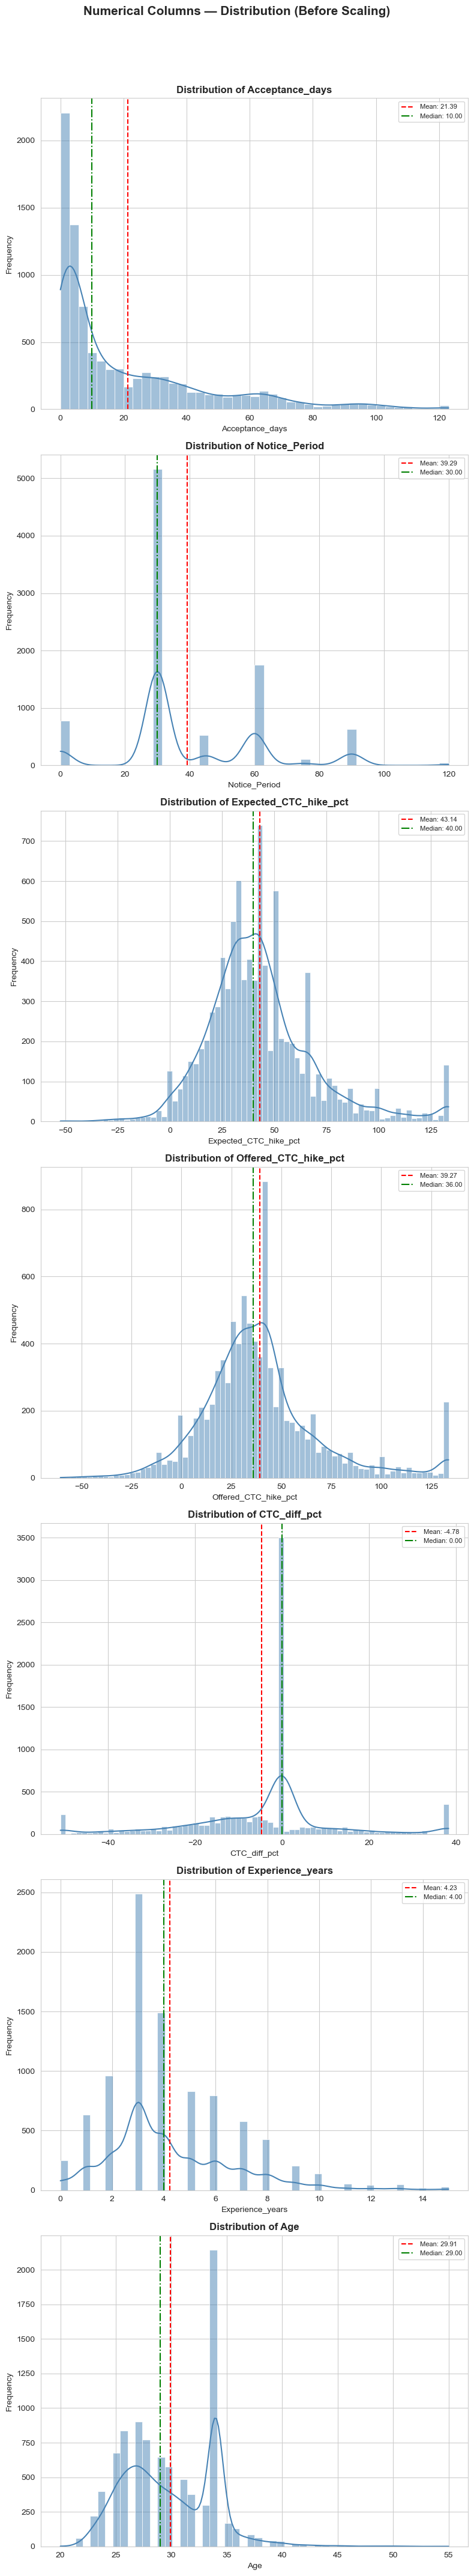

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols  = 1                                     
n_rows  = math.ceil(len(numerical_colsdf) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(8 * n_cols, 6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_colsdf):
    ax = axes[i]

    # Histogram + KDE
    sns.histplot(dfFE[col], kde=True, ax=ax,
                 color='steelblue', edgecolor='white', linewidth=0.5)

    # Mean & Median lines
    ax.axvline(dfFE[col].mean(),   color='red',    linestyle='--',
               linewidth=1.5, label=f'Mean: {dfFE[col].mean():.2f}')
    
    ax.axvline(dfFE[col].median(), color='green',  linestyle='-.',
               linewidth=1.5, label=f'Median: {dfFE[col].median():.2f}')

    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Columns — Distribution (Before Scaling)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### This Shapiro-Wilk-Normality test is not mandatory to do. Its just for learning

In [207]:
from scipy import stats

results = []

for col in numerical_colsdf:
    skewness  = dfFE[col].skew()
    kurtosis  = dfFE[col].kurt()
    
    # Shapiro-Wilk Normality Test (use sample if large dataset)
    sample    = dfFE[col].sample(min(500, len(dfFE)), random_state=42)
    stat, p   = stats.shapiro(sample)
    is_normal = p > 0.05   # True = Normal distribution

    # Decision Rule
    if abs(skewness) <= 0.5:
        recommendation = 'Standardization'
    else:
        recommendation = 'Min-Max Scaling'

    results.append({
        'Column'         : col,
        'Skewness'       : round(skewness, 3),
        'Kurtosis'       : round(kurtosis, 3),
        'Shapiro p-value': round(p, 4),
        'Is Normal?'     : 'Yes' if is_normal else 'No',
        'Recommended'    : recommendation
    })

scaling_df = pd.DataFrame(results)

print(scaling_df.to_string(index=False))


               Column  Skewness  Kurtosis  Shapiro p-value Is Normal?     Recommended
      Acceptance_days     1.523     1.812              0.0         No Min-Max Scaling
        Notice_Period     0.743     0.796              0.0         No Min-Max Scaling
Expected_CTC_hike_pct     0.972     2.062              0.0         No Min-Max Scaling
 Offered_CTC_hike_pct     0.968     1.955              0.0         No Min-Max Scaling
         CTC_diff_pct    -0.137     1.376              0.0         No Standardization
     Experience_years     1.115     1.786              0.0         No Min-Max Scaling
                  Age     0.398     0.186              0.0         No Standardization


In [208]:
numerical_colsdf

['Acceptance_days',
 'Notice_Period',
 'Expected_CTC_hike_pct',
 'Offered_CTC_hike_pct',
 'CTC_diff_pct',
 'Experience_years',
 'Age']

In [209]:
minmax_cols   = ['Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct',
                 'Offered_CTC_hike_pct', 'Experience_years']

standard_cols = ['CTC_diff_pct', 'Age']

In [210]:
for col in minmax_cols:
    print(f"|| {col} ||       : Max = {dfFE[col].max():.2f}     |     Min = {dfFE[col].min():.2f}")

|| Acceptance_days ||       : Max = 123.00     |     Min = 0.00
|| Notice_Period ||       : Max = 120.00     |     Min = 0.00
|| Expected_CTC_hike_pct ||       : Max = 133.59     |     Min = -52.47
|| Offered_CTC_hike_pct ||       : Max = 133.73     |     Min = -60.53
|| Experience_years ||       : Max = 15.00     |     Min = 0.00


In [211]:
for col in standard_cols:
    print(f"|| {col} ||        : Mean = {dfFE[col].mean():.4f}     |     STD = {dfFE[col].std():.4f}")

|| CTC_diff_pct ||        : Mean = -4.7807     |     STD = 17.1215
|| Age ||        : Mean = 29.9099     |     STD = 4.0887


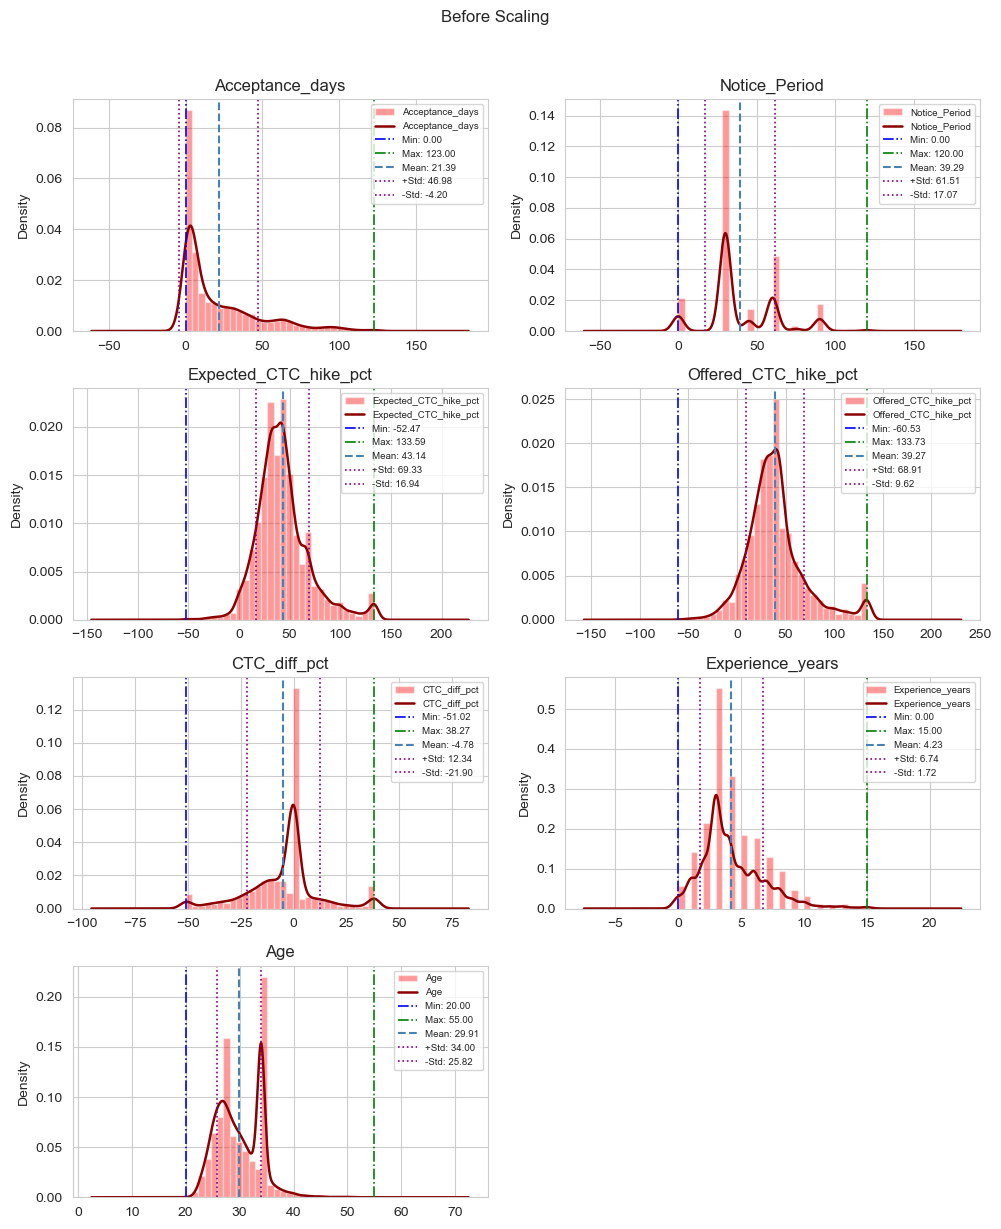

In [212]:
import math

n_cols = 2
n_rows = math.ceil(len(numerical_colsdf) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_colsdf):
    dfFE[col].plot.hist(ax=axes[i], title=col, color='red', alpha=0.4, density=True, bins=30)
    dfFE[col].plot.kde(ax=axes[i], color='darkred', linewidth=1.8)

    col_min  = dfFE[col].min()
    col_max  = dfFE[col].max()
    col_mean = dfFE[col].mean()
    col_std  = dfFE[col].std()

    axes[i].axvline(col_min,            color='blue',   linestyle='-.', linewidth=1.2, label=f'Min: {col_min:.2f}')
    axes[i].axvline(col_max,            color='green',  linestyle='-.', linewidth=1.2, label=f'Max: {col_max:.2f}')
    axes[i].axvline(col_mean,           color='steelblue', linestyle='--',  linewidth=1.5, label=f'Mean: {col_mean:.2f}')
    axes[i].axvline(col_mean + col_std, color='purple', linestyle=':',  linewidth=1.2, label=f'+Std: {col_mean + col_std:.2f}')
    axes[i].axvline(col_mean - col_std, color='purple', linestyle=':',  linewidth=1.2, label=f'-Std: {col_mean - col_std:.2f}')

    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Before Scaling', y=1.02)
plt.tight_layout()
plt.show()

In [213]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_cols   = ['Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct',
                 'Offered_CTC_hike_pct', 'Experience_years']

standard_cols = ['CTC_diff_pct', 'Age']

dfFE[minmax_cols]   = MinMaxScaler().fit_transform(dfFE[minmax_cols])

dfFE[standard_cols] = StandardScaler().fit_transform(dfFE[standard_cols])

print("Scaling Done")

Scaling Done


In [214]:
dfFE

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Location_Name_Gurgaon,Location_Name_Hyderabad,Location_Name_Kolkata,Location_Name_Mumbai,Location_Name_Noida,Location_Name_Pune,Location_Name_Unknown,Region_Name_North,Region_Name_South,Region_Name_West
0,1,0.113821,0.250,1.0,0.170268,0.379337,2.262231,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,0.146341,0.250,1.0,0.550736,1.000000,2.514267,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0.024390,0.375,1.0,0.512254,0.532122,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,0.211382,0.250,1.0,0.512254,0.532122,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1,0.008130,1.000,1.0,0.510910,0.530835,0.279236,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0,0.032520,0.000,2.0,1.000000,1.000000,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8991,1,0.016260,0.000,2.0,1.000000,1.000000,0.279236,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8992,0,0.000000,0.000,1.0,0.472375,0.493926,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8993,0,0.000000,0.250,2.0,0.695421,0.588799,-1.068265,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [215]:
for col in minmax_cols:
    print(f"|| {col} || : Max = {dfFE[col].max():.2f}     |     Min = {dfFE[col].min():.2f}")

|| Acceptance_days || : Max = 1.00     |     Min = 0.00
|| Notice_Period || : Max = 1.00     |     Min = 0.00
|| Expected_CTC_hike_pct || : Max = 1.00     |     Min = 0.00
|| Offered_CTC_hike_pct || : Max = 1.00     |     Min = 0.00
|| Experience_years || : Max = 1.00     |     Min = 0.00


In [216]:
for col in standard_cols:
    print(f"|| {col} || : Mean = {dfFE[col].mean():.4f}     |     STD = {dfFE[col].std():.4f}")

|| CTC_diff_pct || : Mean = -0.0000     |     STD = 1.0001
|| Age || : Mean = -0.0000     |     STD = 1.0001


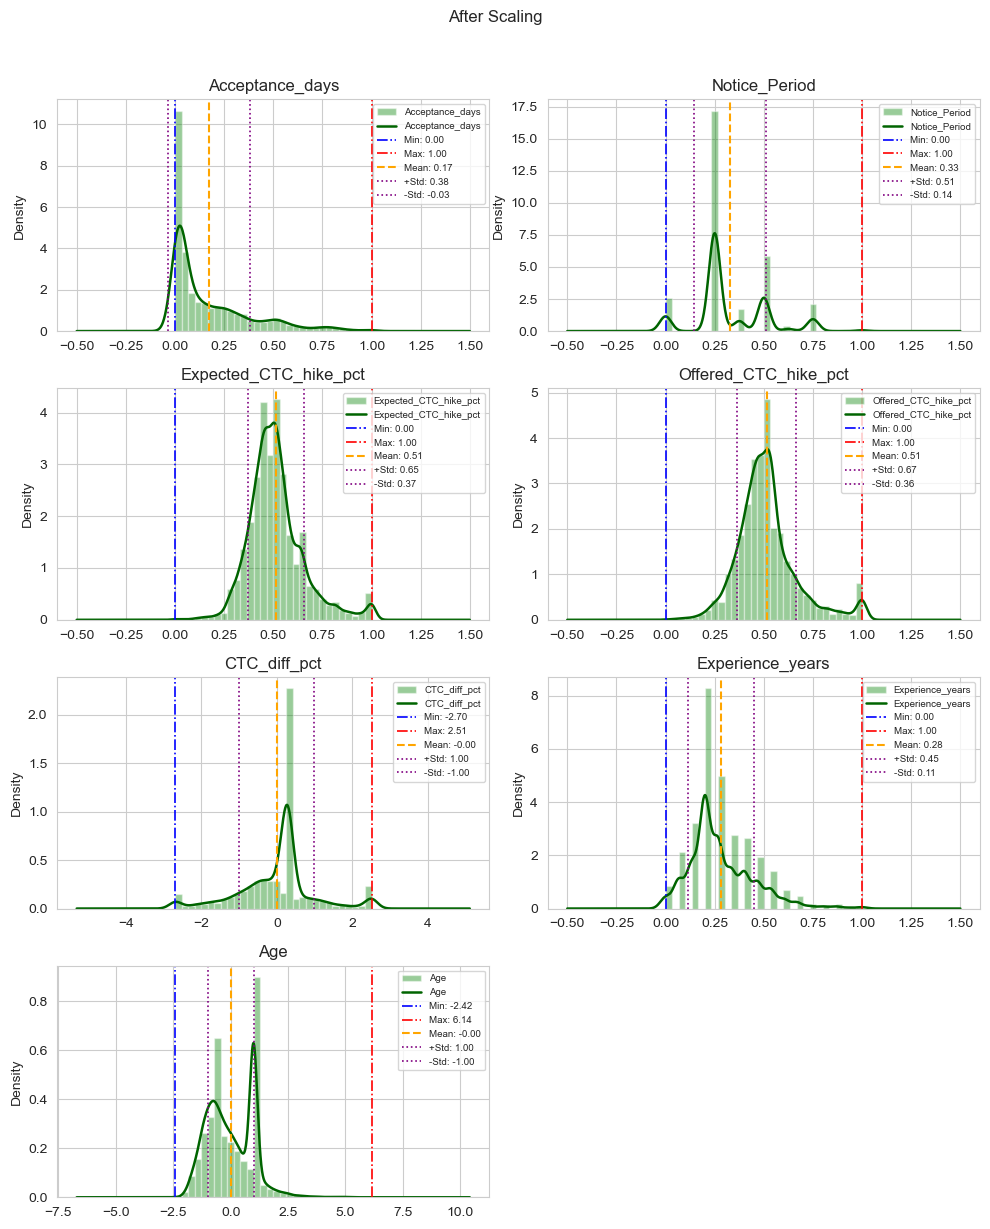

In [217]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_colsdf):
    dfFE[col].plot.hist(ax=axes[i], title=col, color='green', alpha=0.4, density=True, bins=30)
    dfFE[col].plot.kde(ax=axes[i], color='darkgreen', linewidth=1.8)

    col_min  = dfFE[col].min()
    col_max  = dfFE[col].max()
    col_mean = dfFE[col].mean()
    col_std  = dfFE[col].std()

    axes[i].axvline(col_min,            color='blue',   linestyle='-.', linewidth=1.2, label=f'Min: {col_min:.2f}')
    axes[i].axvline(col_max,            color='red',    linestyle='-.', linewidth=1.2, label=f'Max: {col_max:.2f}')
    axes[i].axvline(col_mean,           color='orange', linestyle='--',  linewidth=1.5, label=f'Mean: {col_mean:.2f}')
    axes[i].axvline(col_mean + col_std, color='purple', linestyle=':',  linewidth=1.2, label=f'+Std: {col_mean + col_std:.2f}')
    axes[i].axvline(col_mean - col_std, color='purple', linestyle=':',  linewidth=1.2, label=f'-Std: {col_mean - col_std:.2f}')

    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('After Scaling', y=1.02)
plt.tight_layout()
plt.show()

# Encode Target (Status)

# Do X & Y and then Train Test Split

# SMOTE on Train only

 <a id="encoding-target"></a>

<h2 style="color: green; font-weight: 800;">Encoding Target Feature (Status)</h2>

- ### `Joined` -> `0`
- ### `Not Joined` -> `1`

In [218]:
dfFE['Status'].value_counts()

Status
Joined        7313
Not Joined    1682
Name: count, dtype: int64

In [219]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dfFE['Status'] = le.fit_transform(dfFE['Status'])

print(dict(zip(le.classes_, le.transform(le.classes_))))
print(dfFE['Status'].value_counts())

{'Joined': np.int64(0), 'Not Joined': np.int64(1)}
Status
0    7313
1    1682
Name: count, dtype: int64


 <a id="x-y-split"></a>

<h2 style="color: green; font-weight: 800;">X & y split</h2>

In [220]:
X = dfFE.drop('Status', axis=1)
y = dfFE['Status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8995, 43)
y shape: (8995,)


In [221]:
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
8990    0
8991    0
8992    0
8993    0
8994    0
Name: Status, Length: 8995, dtype: int64


In [222]:
X

,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,...,Location_Name_Gurgaon,Location_Name_Hyderabad,Location_Name_Kolkata,Location_Name_Mumbai,Location_Name_Noida,Location_Name_Pune,Location_Name_Unknown,Region_Name_North,Region_Name_South,Region_Name_West
0,1,0.113821,0.250,1.0,0.170268,0.379337,2.262231,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,0.146341,0.250,1.0,0.550736,1.000000,2.514267,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0.024390,0.375,1.0,0.512254,0.532122,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,0.211382,0.250,1.0,0.512254,0.532122,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1,0.008130,1.000,1.0,0.510910,0.530835,0.279236,0,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,0,0.032520,0.000,2.0,1.000000,1.000000,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8991,1,0.016260,0.000,2.0,1.000000,1.000000,0.279236,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8992,0,0.000000,0.000,1.0,0.472375,0.493926,0.279236,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8993,0,0.000000,0.250,2.0,0.695421,0.588799,-1.068265,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [223]:
print(f"Name of Column : {y.name}")          
print(f"\nValue counts for y : {y.value_counts()}") 
print(f"\nData Type of y = {y.dtype}")         

Name of Column : Status

Value counts for y : Status
0    7313
1    1682
Name: count, dtype: int64

Data Type of y = int64


 <a id="train-test-split"></a>

<h2 style="color: green; font-weight: 800;">Train Test Split</h2>

- ### `80% Training`
- ### `20% Testing`

In [224]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

print(f"\ny_train distribution: {y_train.value_counts()}")
print(f"\ny_test  distribution: {y_test.value_counts()}")

X_train: (7196, 43)
X_test : (1799, 43)

y_train distribution: Status
0    5850
1    1346
Name: count, dtype: int64

y_test  distribution: Status
0    1463
1     336
Name: count, dtype: int64


 <a id="smote-train"></a>

<h2 style="color: green; font-weight: 800;">SMOTE on Train Dataset</h2>

- #### SMOTE -> Synthetic Minority Oversampling Technique.

### Why SMOTE only on Train?
1. Real World Simulation : Test set must reflect real imbalanced distribution, not artificial balance.


2. No Data Leakage : Applying SMOTE before split lets synthetic samples bleed into test set.


3. Honest Evaluation : Metrics on synthetic test data are fake -> train on fake, test on real.


4. Golden Rule : Any transformation (SMOTE, Scaling, Encoding) -> fit on train, never on test.

In [225]:
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state = 42)

X_train_smt, y_train_smt = smt.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"\nX_train shape : {X_train.shape}")

print(f"\nAfter  SMOTE: {pd.Series(y_train_smt).value_counts().to_dict()}")
print(f"\nX_train_sm shape: {X_train_smt.shape}")

Before SMOTE: {0: 5850, 1: 1346}

X_train shape : (7196, 43)

After  SMOTE: {0: 5850, 1: 5850}

X_train_sm shape: (11700, 43)


# Model Training using Pipeline
## (Not Needed)

In [226]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

# Defining models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(random_state=42),
    "Naive Bayes"         : GaussianNB(),
    "KNN"                 : KNeighborsClassifier(),
    "XGBoost"             : XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results
results = []

# Loop through models using Pipeline
for model_name, model in models.items():

    # Build Pipeline
    pipeline = Pipeline(steps=[('classifier', model)])

    # Train on SMOTE balanced train set
    pipeline.fit(X_train_smt, y_train_smt)

    # Predict on original untouched test set
    y_pred      = pipeline.predict(X_test)
    y_pred_prob = (pipeline.predict_proba(X_test)[:, 1]
                   if hasattr(model, "predict_proba") else None)

    # Metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_pred_prob) if y_pred_prob is not None else None
    cm        = confusion_matrix(y_test, y_pred)

    # Print Results
    print(f"\n{'='*55}")
    print(f"  Model     : {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}" if roc_auc is not None else f"  ROC-AUC   : N/A")
    print(f"\n  Confusion Matrix:\n{cm}")
    print(f"\n  Classification Report:\n{classification_report(y_test, y_pred)}")

    # Store the summary
    results.append({
        "Model"     : model_name,
        "Accuracy"  : round(acc, 4),
        "Precision" : round(precision, 4),
        "Recall"    : round(recall, 4),
        "F1 Score"  : round(f1, 4),
        "ROC-AUC"   : round(roc_auc, 4) if roc_auc is not None else None
    })

# Summary Table
print(f"\n{'='*55}")
print(f"  SUMMARY TABLE")
print(f"{'='*55}")

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
print(results_df.to_string(index=False))



  Model     : Logistic Regression
  Accuracy  : 0.6315
  Precision : 0.2829
  Recall    : 0.6339
  F1 Score  : 0.3912
  ROC-AUC   : 0.7000

  Confusion Matrix:
[[923 540]
 [123 213]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.63      0.74      1463
           1       0.28      0.63      0.39       336

    accuracy                           0.63      1799
   macro avg       0.58      0.63      0.56      1799
weighted avg       0.77      0.63      0.67      1799


  Model     : Decision Tree
  Accuracy  : 0.7293
  Precision : 0.3127
  Recall    : 0.3750
  F1 Score  : 0.3410
  ROC-AUC   : 0.5914

  Confusion Matrix:
[[1186  277]
 [ 210  126]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1463
           1       0.31      0.38      0.34       336

    accuracy                           0.73      1799
   macro avg       0.58      0.59    

 <a id="model-training"></a>

<h2 style="color: green; font-weight: 800;">Machine Learning Model Training</h2>


In [227]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

# Defining models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(random_state=42),
    "Naive Bayes"         : GaussianNB(),
    "KNN"                 : KNeighborsClassifier(),
    "XGBoost"             : XGBClassifier(random_state=42, eval_metric='logloss')
}

# Store results storing
results = []

# Loop through models
for model_name, model in models.items():

    # Train directly on SMOTE balanced train set
    model.fit(X_train_smt, y_train_smt)

    # Predict on original untouched test set
    y_pred      = model.predict(X_test)
    y_pred_prob = (model.predict_proba(X_test)[:, 1]
                   if hasattr(model, "predict_proba") else None)

    # Metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_pred_prob) if y_pred_prob is not None else None
    cm        = confusion_matrix(y_test, y_pred)

    # Print Results
    print(f"\n{'='*55}")
    print(f"  Model     : {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}" if roc_auc is not None else f"  ROC-AUC   : N/A")
    print(f"\n  Confusion Matrix:\n{cm}")
    print(f"\n  Classification Report:\n{classification_report(y_test, y_pred)}")

    # Store the summary
    results.append({
        "Model"     : model_name,
        "Accuracy"  : round(acc, 4),
        "Precision" : round(precision, 4),
        "Recall"    : round(recall, 4),
        "F1 Score"  : round(f1, 4),
        "ROC-AUC"   : round(roc_auc, 4) if roc_auc is not None else None
    })

# Summary Table
print(f"\n{'='*55}")
print(f"  SUMMARY TABLE")
print(f"{'='*55}")
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
print(results_df.to_string(index=False))


  Model     : Logistic Regression
  Accuracy  : 0.6315
  Precision : 0.2829
  Recall    : 0.6339
  F1 Score  : 0.3912
  ROC-AUC   : 0.7000

  Confusion Matrix:
[[923 540]
 [123 213]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.63      0.74      1463
           1       0.28      0.63      0.39       336

    accuracy                           0.63      1799
   macro avg       0.58      0.63      0.56      1799
weighted avg       0.77      0.63      0.67      1799


  Model     : Decision Tree
  Accuracy  : 0.7293
  Precision : 0.3127
  Recall    : 0.3750
  F1 Score  : 0.3410
  ROC-AUC   : 0.5914

  Confusion Matrix:
[[1186  277]
 [ 210  126]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1463
           1       0.31      0.38      0.34       336

    accuracy                           0.73      1799
   macro avg       0.58      0.59    

 <a id="models-plots"></a>

<h2 style="color: green; font-weight: 800;">Machine Learning Models Plots</h2>


### Accuracy and ROC-AUC Scores 

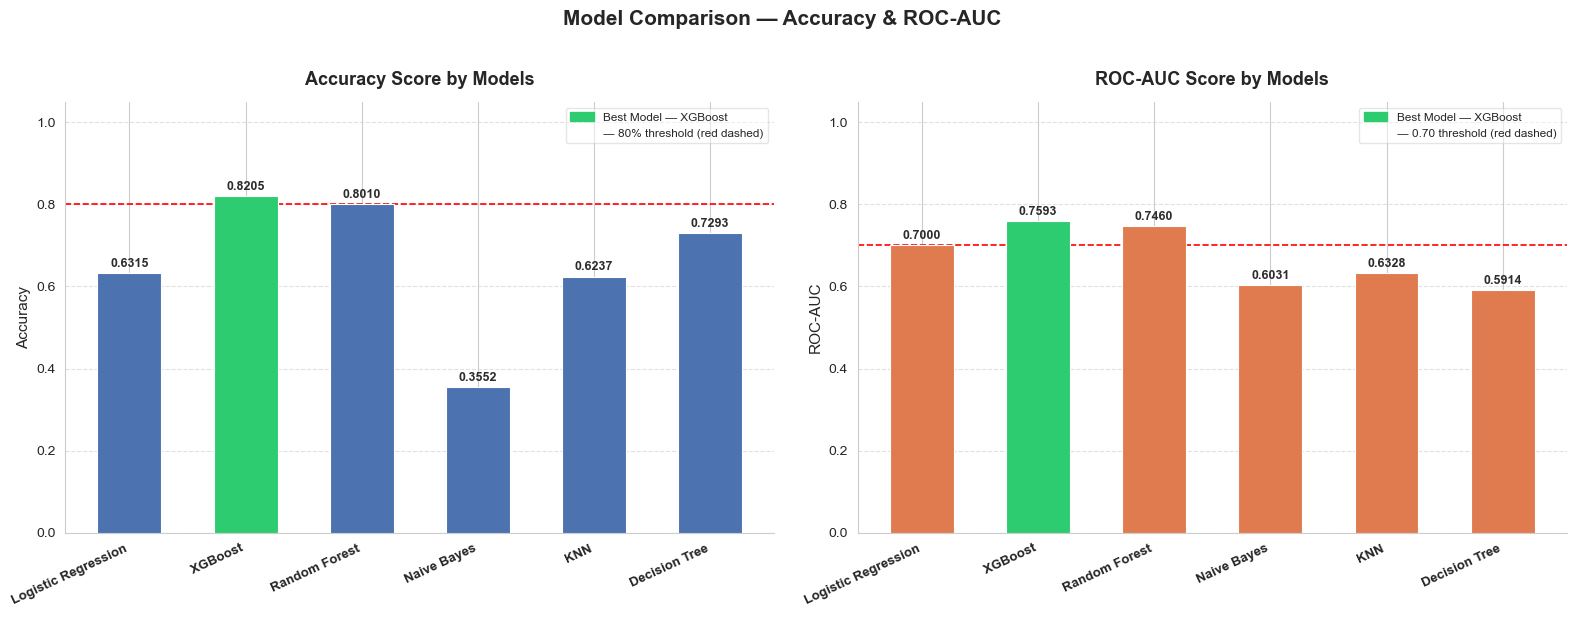

In [229]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
# Data 
models_list = results_df["Model"].tolist()
accuracy    = results_df["Accuracy"].tolist()
roc_auc     = results_df["ROC-AUC"].tolist()
x           = np.arange(len(models_list))
bar_width   = 0.55

# Color palette: highlight XGBoost 
base_color      = "#4C72B0"
highlight_color = "#2ecc71"
colors_acc  = [highlight_color if m == "XGBoost" else base_color for m in models_list]
colors_roc  = [highlight_color if m == "XGBoost" else "#E07B4F"  for m in models_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Comparison — Accuracy & ROC-AUC", fontsize=15, fontweight="bold", y=1.02)

# Helper: annotate bars 
def annotate_bars(ax, bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.008,
            f"{h:.4f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#2c2c2c"
        )

# Accuracy Plot
ax1   = axes[0]
bars1 = ax1.bar(x, accuracy, width=bar_width, color=colors_acc,
                edgecolor="white", linewidth=0.8, zorder=3)
annotate_bars(ax1, bars1)

ax1.set_title("Accuracy Score by Models", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=25, ha="right", fontsize=9.5, weight='bold')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=0.80, color="red", linestyle="--", linewidth=1.2, label="80% threshold")
ax1.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(fontsize=9)

best_patch1 = mpatches.Patch(color=highlight_color, label="Best Model — XGBoost")
ax1.legend(handles=[best_patch1,
           mpatches.Patch(color="none", label="― 80% threshold (red dashed)")],
           fontsize=8.5, framealpha=0.5)

# ROC-AUC Plot 
ax2   = axes[1]
bars2 = ax2.bar(x, roc_auc, width=bar_width, color=colors_roc,
                edgecolor="white", linewidth=0.8, zorder=3)
annotate_bars(ax2, bars2)

ax2.set_title("ROC-AUC Score by Models", fontsize=13, fontweight="bold", pad=12)
ax2.set_ylabel("ROC-AUC", fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=25, ha="right", fontsize=9.5, weight='bold')
ax2.set_ylim(0, 1.05)
ax2.axhline(y=0.70, color="red", linestyle="--", linewidth=1.2)
ax2.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax2.set_axisbelow(True)
ax2.spines[["top", "right"]].set_visible(False)

best_patch2 = mpatches.Patch(color=highlight_color, label="Best Model — XGBoost")
ax2.legend(handles=[best_patch2,
           mpatches.Patch(color="none", label="― 0.70 threshold (red dashed)")],
           fontsize=8.5, framealpha=0.5)

plt.tight_layout()
# plt.savefig("model_comparison_accuracy_rocauc.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion metrices of all Models

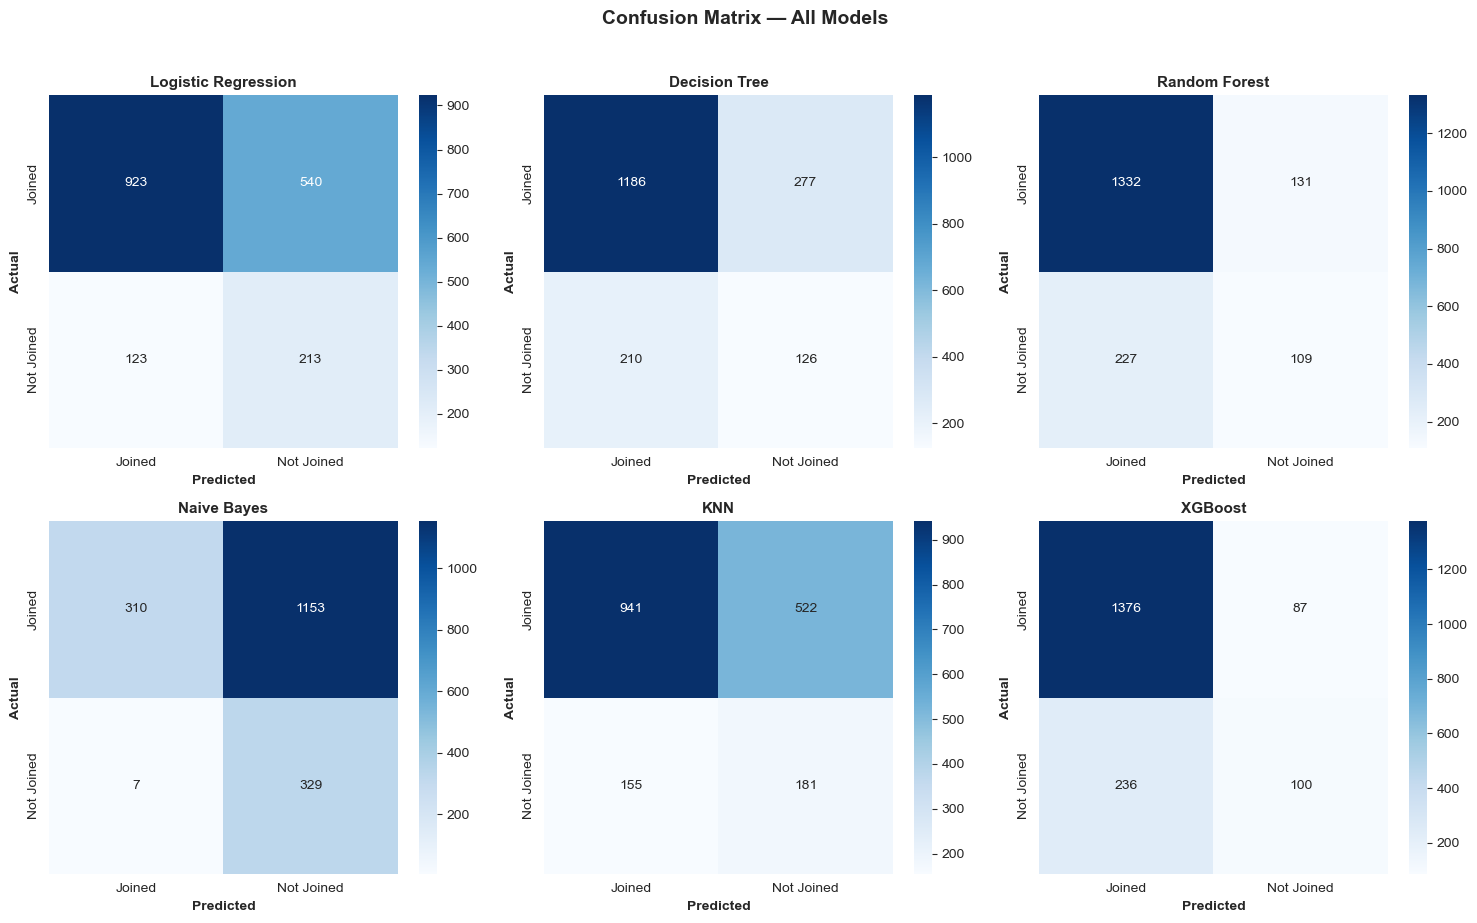

In [230]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Joined', 'Not Joined'],
                yticklabels=['Joined', 'Not Joined'])

    axes[idx].set_title(f"{model_name}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted", weight='bold')
    axes[idx].set_ylabel("Actual", weight='bold')

plt.suptitle("Confusion Matrix — All Models", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

### ROC Curve (All 6 Models Overlaid)

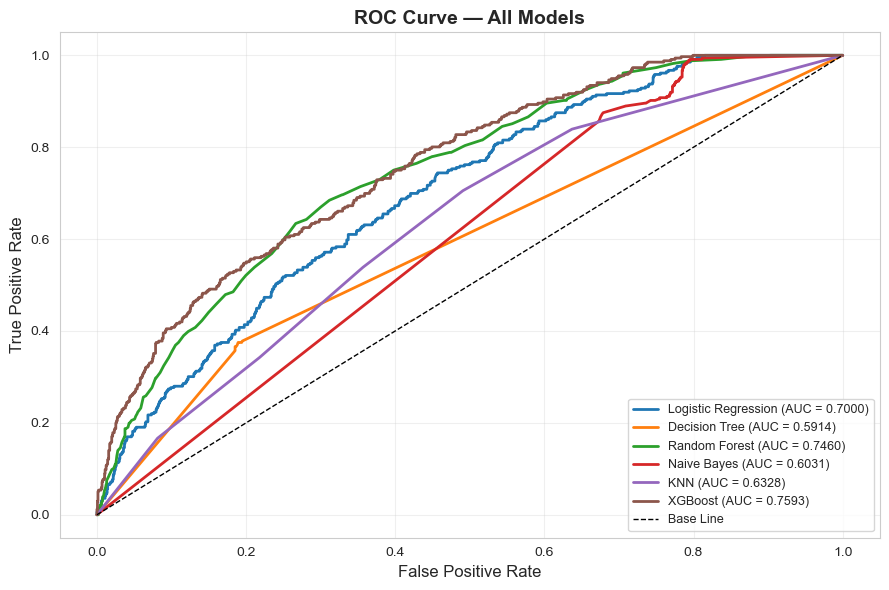

In [232]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(9, 6))

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_pred_prob      = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _      = roc_curve(y_test, y_pred_prob)
        roc_auc          = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})", linewidth=2)

# Diagonal baseline
plt.plot([0, 1], [0, 1],linestyle='--', color='black', linewidth=1, label='Base Line')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — All Models", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [236]:
# filename: complete_hr_xgboost_pipeline.py
# Code Generated by Sidekick is for learning and experimentation purposes only.

from pathlib import Path
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# ============================================================
# SETTINGS
# ============================================================

RANDOM_STATE = 42

SOURCE_FILE = Path(
    "(Upto_Feature_Engineering)HR_HIRING_ANALYTICS.csv"
)

CANDIDATE_FILE = Path(
    "candidate_input.csv"
)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)


# ============================================================
# COLUMN DEFINITIONS
# ============================================================

RAW_FEATURES = [
    "DOJ_Extended",
    "Acceptance_days",
    "Notice_Period",
    "Offered_Band",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "CTC_diff_pct",
    "Joining_Bonus",
    "Candidate_relocate_actual",
    "Gender",
    "Candidate_Source",
    "Experience_years",
    "Postal_Code",
    "Age",
    "LOB",
    "Location_Name",
    "Region_Name"
]

TARGET_COLUMN = "Status"

BINARY_COLS = [
    "DOJ_Extended",
    "Joining_Bonus",
    "Candidate_relocate_actual",
    "Gender"
]

OHE_COLS = [
    "Candidate_Source",
    "Postal_Code",
    "LOB",
    "Location_Name",
    "Region_Name"
]

MINMAX_COLS = [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "Experience_years"
]

STANDARD_COLS = [
    "CTC_diff_pct",
    "Age"
]

NUMERIC_COLS = MINMAX_COLS + STANDARD_COLS


# ============================================================
# 1. LOAD PRE-ENCODING DATA
# ============================================================

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"CSV file was not found: {SOURCE_FILE.resolve()}"
    )

data_exp = pd.read_csv(SOURCE_FILE)

data_exp.columns = (
    data_exp.columns
    .str.strip()
)

print("Loaded file:")
print(SOURCE_FILE.resolve())
print("Original shape:", data_exp.shape)


# ============================================================
# 2. STANDARDIZE POSSIBLE SOURCE COLUMN NAMES
# ============================================================

COLUMN_MAPPING = {
    "DOJ_EXTENDED": "DOJ_Extended",
    "DURATION_TO_ACCEPT_OFFER": "Acceptance_days",
    "NOTICE_PERIOD": "Notice_Period",
    "OFFERED_BAND": "Offered_Band",
    "PERCENT_HIKE_EXPECTED_IN_CTC": "Expected_CTC_hike_pct",
    "PERCENT_HIKE_OFFERED_IN_CTC": "Offered_CTC_hike_pct",
    "JOINING_BONUS": "Joining_Bonus",
    "CANDIDATE_RELOCATE_ACTUAL": "Candidate_relocate_actual",
    "GENDER": "Gender",
    "CANDIDATE_SOURCE": "Candidate_Source",
    "REX_IN_YRS": "Experience_years",
    "POSTAL_CODE": "Postal_Code",
    "AGE": "Age",
    "LOB_NAME": "LOB",
    "LOCATION_NAME": "Location_Name",
    "REGION_NAME": "Region_Name",
    "JOINING_STATUS": "Status"
}

data_exp = data_exp.rename(
    columns=COLUMN_MAPPING
)


# ============================================================
# 3. RECREATE FEATURE ENGINEERING
# ============================================================

data_exp["Expected_CTC_hike_pct"] = pd.to_numeric(
    data_exp["Expected_CTC_hike_pct"],
    errors="coerce"
)

data_exp["Offered_CTC_hike_pct"] = pd.to_numeric(
    data_exp["Offered_CTC_hike_pct"],
    errors="coerce"
)

data_exp["CTC_diff_pct"] = (
    data_exp["Expected_CTC_hike_pct"]
    - data_exp["Offered_CTC_hike_pct"]
)


# ============================================================
# 4. VALIDATE REQUIRED COLUMNS
# ============================================================

required_columns = RAW_FEATURES + [
    TARGET_COLUMN
]

missing_columns = [
    column
    for column in required_columns
    if column not in data_exp.columns
]

if missing_columns:
    raise ValueError(
        "The CSV is missing these columns: "
        f"{missing_columns}"
    )

print("Required columns validated successfully.")


# ============================================================
# 5. PREPARE FEATURES AND TARGET
# ============================================================

X_raw = data_exp[RAW_FEATURES].copy()

target_mapping = {
    "Joined": 0,
    "Not Joined": 1
}

y = (
    data_exp[TARGET_COLUMN]
    .astype(str)
    .str.strip()
    .map(target_mapping)
)

if y.isna().any():
    invalid_statuses = sorted(
        data_exp.loc[
            y.isna(),
            TARGET_COLUMN
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Unexpected values in Status: "
        f"{invalid_statuses}"
    )

y = y.astype(int)


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train = X_train.copy()
X_test = X_test.copy()

fill_values = {}


# ============================================================
# 7. NUMERIC MISSING-VALUE TREATMENT
# ============================================================

for column in NUMERIC_COLS:
    X_train[column] = pd.to_numeric(
        X_train[column],
        errors="coerce"
    )

    X_test[column] = pd.to_numeric(
        X_test[column],
        errors="coerce"
    )

    fill_value = float(
        X_train[column].median()
    )

    fill_values[column] = fill_value

    X_train[column] = X_train[column].fillna(
        fill_value
    )

    X_test[column] = X_test[column].fillna(
        fill_value
    )


# ============================================================
# 8. CATEGORICAL MISSING-VALUE TREATMENT
# ============================================================

categorical_columns = [
    "Offered_Band",
    *OHE_COLS
]

for column in categorical_columns:
    X_train[column] = X_train[column].astype(str)
    X_test[column] = X_test[column].astype(str)

    train_mode = X_train[column].replace(
        "nan",
        pd.NA
    ).dropna().mode()

    if len(train_mode) > 0:
        fill_value = str(train_mode.iloc[0])
    else:
        fill_value = "Unknown"

    fill_values[column] = fill_value

    X_train[column] = (
        X_train[column]
        .replace("nan", pd.NA)
        .fillna(fill_value)
        .astype(str)
    )

    X_test[column] = (
        X_test[column]
        .replace("nan", pd.NA)
        .fillna(fill_value)
        .astype(str)
    )


# ============================================================
# 9. GROUP RARE POSTAL CODES
# ============================================================

postal_counts = (
    X_train["Postal_Code"]
    .value_counts()
)

postal_keep = (
    postal_counts[
        postal_counts > 40
    ]
    .index
    .astype(str)
    .tolist()
)

X_train["Postal_Code"] = (
    X_train["Postal_Code"]
    .where(
        X_train["Postal_Code"].isin(postal_keep),
        "Other"
    )
)

X_test["Postal_Code"] = (
    X_test["Postal_Code"]
    .where(
        X_test["Postal_Code"].isin(postal_keep),
        "Other"
    )
)


# ============================================================
# 10. BINARY ENCODING
# ============================================================

binary_encoders = {}

for column in BINARY_COLS:
    encoder = LabelEncoder()

    encoder.fit(X_train[column])

    unknown_test_values = (
        set(X_test[column])
        - set(encoder.classes_)
    )

    if unknown_test_values:
        raise ValueError(
            f"Unseen values in {column}: "
            f"{unknown_test_values}"
        )

    X_train[column] = encoder.transform(
        X_train[column]
    )

    X_test[column] = encoder.transform(
        X_test[column]
    )

    binary_encoders[column] = encoder

    print(
        f"{column} mapping:",
        dict(
            zip(
                encoder.classes_,
                encoder.transform(
                    encoder.classes_
                )
            )
        )
    )


# ============================================================
# 11. ORDINAL ENCODING FOR OFFERED BAND
# ============================================================

preferred_band_order = [
    "E3",
    "E2",
    "E1",
    "E0"
]

observed_bands = list(
    pd.unique(
        X_train["Offered_Band"]
    )
)

additional_bands = [
    band
    for band in observed_bands
    if band not in preferred_band_order
]

band_categories = (
    preferred_band_order
    + sorted(additional_bands)
)

band_encoder = OrdinalEncoder(
    categories=[band_categories],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[["Offered_Band"]] = (
    band_encoder.fit_transform(
        X_train[["Offered_Band"]]
    )
)

X_test[["Offered_Band"]] = (
    band_encoder.transform(
        X_test[["Offered_Band"]]
    )
)


# ============================================================
# 12. ONE-HOT ENCODING
# ============================================================

try:
    ohe = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    ohe = OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse=False
    )

train_ohe_array = ohe.fit_transform(
    X_train[OHE_COLS]
)

test_ohe_array = ohe.transform(
    X_test[OHE_COLS]
)

ohe_feature_names = (
    ohe.get_feature_names_out(
        OHE_COLS
    )
    .tolist()
)

train_ohe_df = pd.DataFrame(
    train_ohe_array,
    columns=ohe_feature_names,
    index=X_train.index
)

test_ohe_df = pd.DataFrame(
    test_ohe_array,
    columns=ohe_feature_names,
    index=X_test.index
)

X_train = X_train.drop(
    columns=OHE_COLS
)

X_test = X_test.drop(
    columns=OHE_COLS
)

X_train = pd.concat(
    [
        X_train,
        train_ohe_df
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test,
        test_ohe_df
    ],
    axis=1
)


# ============================================================
# 13. SCALE NUMERIC FEATURES
# ============================================================

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

X_train[MINMAX_COLS] = (
    minmax_scaler.fit_transform(
        X_train[MINMAX_COLS]
    )
)

X_test[MINMAX_COLS] = (
    minmax_scaler.transform(
        X_test[MINMAX_COLS]
    )
)

X_train[STANDARD_COLS] = (
    standard_scaler.fit_transform(
        X_train[STANDARD_COLS]
    )
)

X_test[STANDARD_COLS] = (
    standard_scaler.transform(
        X_test[STANDARD_COLS]
    )
)

feature_columns = X_train.columns.tolist()

X_test = X_test[feature_columns]

print("Encoded training shape:", X_train.shape)
print("Encoded testing shape:", X_test.shape)
print("Number of model features:", len(feature_columns))


# ============================================================
# 14. APPLY SMOTE TO TRAINING DATA ONLY
# ============================================================

smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# ============================================================
# 15. TRAIN XGBOOST
# ============================================================

model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

model.fit(
    X_train_smote,
    y_train_smote
)


# ============================================================
# 16. EVALUATE MODEL
# ============================================================

y_pred = model.predict(X_test)

y_probability = (
    model.predict_proba(X_test)[:, 1]
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\nModel evaluation")
print("----------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification report")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Joined",
            "Not Joined"
        ]
    )
)


# ============================================================
# 17. SAVE MODEL AND PREPROCESSING BUNDLE
# ============================================================

preprocessing_bundle = {
    "raw_features": RAW_FEATURES,
    "target_column": TARGET_COLUMN,
    "target_mapping": target_mapping,
    "binary_columns": BINARY_COLS,
    "ohe_columns": OHE_COLS,
    "minmax_columns": MINMAX_COLS,
    "standard_columns": STANDARD_COLS,
    "binary_encoders": binary_encoders,
    "band_encoder": band_encoder,
    "ohe": ohe,
    "minmax_scaler": minmax_scaler,
    "standard_scaler": standard_scaler,
    "feature_columns": feature_columns,
    "postal_keep": postal_keep,
    "fill_values": fill_values
}

joblib.dump(
    model,
    ARTIFACT_DIR / "xgboost_model.joblib"
)

joblib.dump(
    preprocessing_bundle,
    ARTIFACT_DIR / "preprocessing_bundle.joblib"
)

print("\nArtifacts saved successfully.")


# ============================================================
# 18. CREATE CANDIDATE CSV IF IT DOES NOT EXIST
# ============================================================

if not CANDIDATE_FILE.exists():
    candidate_template = data_exp.sample(
        n=1,
        random_state=2026
    )[RAW_FEATURES].copy()

    candidate_template.to_csv(
        CANDIDATE_FILE,
        index=False
    )

    print(
        "\nCandidate template created:"
    )
    print(CANDIDATE_FILE.resolve())
    print(
        "Edit the CSV with candidate values, save it, "
        "and rerun this same cell."
    )

else:
    print(
        "\nUsing candidate file:",
        CANDIDATE_FILE.resolve()
    )


# ============================================================
# 19. LOAD CANDIDATE CSV
# ============================================================

candidate = pd.read_csv(
    CANDIDATE_FILE
)

candidate.columns = (
    candidate.columns
    .str.strip()
)

missing_candidate_columns = [
    column
    for column in RAW_FEATURES
    if column not in candidate.columns
]

if missing_candidate_columns:
    raise ValueError(
        "candidate_input.csv is missing: "
        f"{missing_candidate_columns}"
    )

candidate = candidate[RAW_FEATURES].copy()

candidate["Expected_CTC_hike_pct"] = pd.to_numeric(
    candidate["Expected_CTC_hike_pct"],
    errors="coerce"
)

candidate["Offered_CTC_hike_pct"] = pd.to_numeric(
    candidate["Offered_CTC_hike_pct"],
    errors="coerce"
)

candidate["CTC_diff_pct"] = (
    candidate["Expected_CTC_hike_pct"]
    - candidate["Offered_CTC_hike_pct"]
)


# ============================================================
# 20. PREPROCESS CANDIDATE INPUT
# ============================================================

for column in NUMERIC_COLS:
    candidate[column] = pd.to_numeric(
        candidate[column],
        errors="coerce"
    )

    candidate[column] = candidate[column].fillna(
        fill_values[column]
    )

for column in categorical_columns:
    candidate[column] = candidate[column].astype(str)

    candidate[column] = (
        candidate[column]
        .replace("nan", fill_values[column])
    )

candidate["Postal_Code"] = (
    candidate["Postal_Code"]
    .where(
        candidate["Postal_Code"].isin(
            postal_keep
        ),
        "Other"
    )
)


# Apply binary encoders.
for column, encoder in binary_encoders.items():
    unknown_values = (
        set(candidate[column])
        - set(encoder.classes_)
    )

    if unknown_values:
        raise ValueError(
            f"Invalid value in {column}: "
            f"{unknown_values}. Allowed values: "
            f"{list(encoder.classes_)}"
        )

    candidate[column] = encoder.transform(
        candidate[column]
    )


# Apply ordinal encoder.
candidate[["Offered_Band"]] = (
    band_encoder.transform(
        candidate[["Offered_Band"]]
    )
)


# Apply one-hot encoder.
candidate_ohe_array = ohe.transform(
    candidate[OHE_COLS]
)

candidate_ohe_df = pd.DataFrame(
    candidate_ohe_array,
    columns=ohe_feature_names,
    index=candidate.index
)

candidate = candidate.drop(
    columns=OHE_COLS
)

candidate = pd.concat(
    [
        candidate,
        candidate_ohe_df
    ],
    axis=1
)


# Apply scalers.
candidate[MINMAX_COLS] = (
    minmax_scaler.transform(
        candidate[MINMAX_COLS]
    )
)

candidate[STANDARD_COLS] = (
    standard_scaler.transform(
        candidate[STANDARD_COLS]
    )
)

candidate = candidate[feature_columns]


# ============================================================
# 21. PREDICT CANDIDATE STATUS
# ============================================================

prediction_code = int(
    model.predict(candidate)[0]
)

probabilities = model.predict_proba(
    candidate
)[0]

reverse_mapping = {
    value: key
    for key, value in target_mapping.items()
}

print("\nCandidate prediction")
print("--------------------")
print(
    "Predicted status:",
    reverse_mapping[prediction_code]
)

for class_code, probability in zip(
    model.classes_,
    probabilities
):
    print(
        f"{reverse_mapping[int(class_code)]}: "
        f"{probability:.2%}"
    )


Loaded file:
C:\Capstone_Project\Notebooks\(Upto_Feature_Engineering)HR_HIRING_ANALYTICS.csv
Original shape: (8995, 19)
Required columns validated successfully.
DOJ_Extended mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Joining_Bonus mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Candidate_relocate_actual mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Encoded training shape: (7196, 42)
Encoded testing shape: (1799, 42)
Number of model features: 42

Class distribution before SMOTE:
Status
0    5850
1    1346
Name: count, dtype: int64

Class distribution after SMOTE:
Status
0    5850
1    5850
Name: count, dtype: int64

Model evaluation
----------------
Accuracy: 0.8171
ROC-AUC: 0.7507

Classification report
              precision    recall  f1-score   support

      Joined       0.86      0.93      0.89      1463
  Not Joined       0.52      0.32      0.39       336

    accuracy                           0.82      179

In [238]:
# filename: interactive_candidate_prediction.py
# Code Generated by Sidekick is for learning and experimentation purposes only.

from pathlib import Path
import joblib
import pandas as pd


# ============================================================
# 1. LOAD MODEL AND PREPROCESSING ARTIFACTS
# ============================================================

ARTIFACT_DIR = Path("artifacts")

model = joblib.load(
    ARTIFACT_DIR / "xgboost_model.joblib"
)

preprocessing = joblib.load(
    ARTIFACT_DIR / "preprocessing_bundle.joblib"
)

raw_features = preprocessing["raw_features"]
binary_encoders = preprocessing["binary_encoders"]
band_encoder = preprocessing["band_encoder"]
ohe = preprocessing["ohe"]
ohe_columns = preprocessing["ohe_columns"]
minmax_columns = preprocessing["minmax_columns"]
standard_columns = preprocessing["standard_columns"]
minmax_scaler = preprocessing["minmax_scaler"]
standard_scaler = preprocessing["standard_scaler"]
feature_columns = preprocessing["feature_columns"]
postal_keep = set(
    str(value)
    for value in preprocessing["postal_keep"]
)
fill_values = preprocessing["fill_values"]
target_mapping = preprocessing.get(
    "target_mapping",
    {
        "Joined": 0,
        "Not Joined": 1
    }
)

reverse_target_mapping = {
    int(value): key
    for key, value in target_mapping.items()
}


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def choose_option(field_name, options):
    options = [
        str(option)
        for option in options
        if str(option).lower() != "nan"
    ]

    print(f"\nSelect {field_name}:")

    for number, option in enumerate(options, start=1):
        print(f"{number}. {option}")

    while True:
        selected = input(
            f"Enter the number for {field_name}: "
        ).strip()

        try:
            selected_number = int(selected)
        except ValueError:
            print("Please enter a valid number.")
            continue

        if 1 <= selected_number <= len(options):
            return options[selected_number - 1]

        print(
            f"Please choose a number from 1 to {len(options)}."
        )


def enter_number(field_name):
    while True:
        value = input(
            f"\nEnter {field_name}: "
        ).strip()

        try:
            return float(value)
        except ValueError:
            print("Please enter a numeric value.")


def get_ohe_options(column_name):
    column_index = ohe_columns.index(column_name)

    return ohe.categories_[column_index]


# ============================================================
# 3. COLLECT USER INPUT
# ============================================================

print("=" * 60)
print("HR HIRING CANDIDATE PREDICTION")
print("=" * 60)

candidate = {}

# Binary fields
for column in [
    "DOJ_Extended",
    "Joining_Bonus",
    "Candidate_relocate_actual",
    "Gender"
]:
    encoder = binary_encoders[column]

    candidate[column] = choose_option(
        column,
        encoder.classes_
    )

# Ordinal field
band_options = band_encoder.categories_[0]

candidate["Offered_Band"] = choose_option(
    "Offered_Band",
    band_options
)

# One-hot categorical fields
for column in ohe_columns:
    candidate[column] = choose_option(
        column,
        get_ohe_options(column)
    )

# Numeric fields
for column in [
    "Acceptance_days",
    "Notice_Period",
    "Expected_CTC_hike_pct",
    "Offered_CTC_hike_pct",
    "Experience_years",
    "Age"
]:
    candidate[column] = enter_number(column)

# Derived feature
candidate["CTC_diff_pct"] = (
    candidate["Expected_CTC_hike_pct"]
    - candidate["Offered_CTC_hike_pct"]
)

candidate["Postal_Code"] = choose_option(
    "Postal_Code",
    sorted(postal_keep) + ["Other"]
)

candidate_frame = pd.DataFrame(
    [candidate]
)[raw_features]


# ============================================================
# 4. PREPROCESS THE USER INPUT
# ============================================================

prepared = candidate_frame.copy()

# Numeric conversion and missing-value handling
for column in (
    minmax_columns
    + standard_columns
):
    prepared[column] = pd.to_numeric(
        prepared[column],
        errors="coerce"
    )

    prepared[column] = prepared[column].fillna(
        fill_values[column]
    )

# Categorical values
categorical_columns = [
    "Offered_Band",
    *ohe_columns
]

for column in categorical_columns:
    prepared[column] = (
        prepared[column]
        .astype(str)
        .replace(
            "nan",
            str(fill_values.get(column, "Unknown"))
        )
    )

# Apply postal-code grouping
prepared["Postal_Code"] = prepared[
    "Postal_Code"
].where(
    prepared["Postal_Code"].isin(postal_keep),
    "Other"
)

# Apply binary encoders
for column, encoder in binary_encoders.items():
    known_values = set(
        str(value)
        for value in encoder.classes_
    )

    entered_values = set(
        prepared[column].astype(str)
    )

    unknown_values = entered_values - known_values

    if unknown_values:
        raise ValueError(
            f"Invalid value for {column}: "
            f"{unknown_values}"
        )

    prepared[column] = encoder.transform(
        prepared[column].astype(str)
    )

# Apply Offered_Band ordinal encoding
prepared[["Offered_Band"]] = (
    band_encoder.transform(
        prepared[["Offered_Band"]]
    )
)

# Apply one-hot encoding
encoded_array = ohe.transform(
    prepared[ohe_columns]
)

encoded_columns = ohe.get_feature_names_out(
    ohe_columns
).tolist()

encoded_frame = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=prepared.index
)

prepared = prepared.drop(
    columns=ohe_columns
)

prepared = pd.concat(
    [prepared, encoded_frame],
    axis=1
)

# Apply saved scalers
prepared[minmax_columns] = (
    minmax_scaler.transform(
        prepared[minmax_columns]
    )
)

prepared[standard_columns] = (
    standard_scaler.transform(
        prepared[standard_columns]
    )
)

# Match exact training feature order
missing_model_features = [
    column
    for column in feature_columns
    if column not in prepared.columns
]

if missing_model_features:
    raise ValueError(
        "Prepared input is missing model features: "
        f"{missing_model_features}"
    )

prepared = prepared[feature_columns]


# ============================================================
# 5. GENERATE PREDICTION
# ============================================================

prediction_code = int(
    model.predict(prepared)[0]
)

probabilities = model.predict_proba(
    prepared
)[0]

predicted_status = reverse_target_mapping.get(
    prediction_code,
    str(prediction_code)
)

print("\n" + "=" * 60)
print("CANDIDATE DETAILS")
print("=" * 60)

for column, value in candidate.items():
    print(f"{column}: {value}")

print("\n" + "=" * 60)
print("PREDICTION RESULT")
print("=" * 60)

print(
    "Predicted status:",
    predicted_status
)

for class_code, probability in zip(
    model.classes_,
    probabilities
):
    class_label = reverse_target_mapping.get(
        int(class_code),
        str(class_code)
    )

    print(
        f"{class_label} probability: "
        f"{probability:.2%}"
    )


HR HIRING CANDIDATE PREDICTION

Select DOJ_Extended:
1. No
2. Yes


Enter the number for DOJ_Extended:  1



Select Joining_Bonus:
1. No
2. Yes


Enter the number for Joining_Bonus:  2



Select Candidate_relocate_actual:
1. No
2. Yes


...


Select Region_Name:
1. East
2. North
3. South
4. West


Enter the number for Region_Name:  4

Enter Acceptance_days:  30

Enter Notice_Period:  40

Enter Expected_CTC_hike_pct:  2

Enter Offered_CTC_hike_pct:  1.5

Enter Experience_years:  5

Enter Age:  30



Select Postal_Code:
1. 122107
2. 201301
3. 400001
4. 500004
5. 560034
6. 600020
7. 700027
8. Other


Enter the number for Postal_Code:  1



CANDIDATE DETAILS
DOJ_Extended: No
Joining_Bonus: Yes
Candidate_relocate_actual: Yes
Gender: Male
Offered_Band: E0
Candidate_Source: Direct
Postal_Code: 122107
LOB: MMS
Location_Name: Ahmedabad
Region_Name: West
Acceptance_days: 30.0
Notice_Period: 40.0
Expected_CTC_hike_pct: 2.0
Offered_CTC_hike_pct: 1.5
Experience_years: 5.0
Age: 30.0
CTC_diff_pct: 0.5

PREDICTION RESULT
Predicted status: Joined
Joined probability: 99.96%
Not Joined probability: 0.04%
